## 1. Paths and imports


# TabPFN FP follow-up (VLST): ratio sweep + dual evaluation matrices

**Split policy (retrospective design, forward loop):** **split_b is fixed** across all registered FP CSVs (`REGISTERED_FP_SETS`, overridable via `VLST_FP_REGISTRY`). Built once from the **union of each set’s 20% FP test holdout** (capped to split_b budget; common test-holdout ids prioritized (train-holdout FPs never on split_b)). Same **19 test positives**, same **814 plain TNs**, same **FP-candidate pool** row ids for every run. Per run: **active fp_test** = `(this CSV ids) ∩ fp_candidate_pool`; pool rows from other sets (or unused pool slots) are **plain TN on split_b**. §2 prints **common** FP count across registered sets. **split_a(r_max)** equals **split_b**; for smaller **r**, only the TN prefix shrinks. **Train(r)** adds TNs from `tn_train_ordered` (all train FPs from the active CSV). **Val** = held-out train-pool positives + `tn_val_ix`.

**Fixed TN budget:** Mined FPs must be unique VLST TNs (`y=0`); carved from the pool, not added. §2 prints `TN budget:` and `Split disjointness OK`.

**Ratio schedule:** `n_neg_target = n_pos_ratio × r` (default **`n_pos_ratio` = train positives**). `max_r = floor((n_fp_fit + n_tn_train_pool) / n_pos_ratio)`.

§3 TabPFN sweep · §5 curves · §6 MaxFP CSV · §7 MaxFP-46 (92 pos : 46 FP subset).


In [1]:
import os
import warnings

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = int(os.environ.get("VLST_TABPFN_FOLLOWUP_SEED", "42"))

FULL_DATA_PATH = os.environ.get(
    "VLST_FULL_DATA_PATH",
    "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv",
)


def pick_output_dir_modeling_fp() -> str:
    out = os.environ.get("VLST_FP_FOLLOWUP_OUT_DIR")
    if out:
        return os.path.expanduser(out.rstrip(os.sep))
    if os.path.isdir("/kaggle/working"):
        return "/kaggle/working/vlst_fp_followup_output"
    return os.path.normpath(os.path.join("..", "..", "data", "result", "modeling_fp"))


OUTPUT_DIR = pick_output_dir_modeling_fp()
os.makedirs(OUTPUT_DIR, exist_ok=True)


def pick_fp_mining_output_dir() -> str:
    out = os.environ.get("VLST_FP_OUTPUT_DIR") or os.environ.get("VLST_FP_MINING_OUT")
    if not out:
        kaggle_fp_out = "/kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output"
        if os.path.isdir(kaggle_fp_out):
            out = kaggle_fp_out
    if out:
        out = os.path.expanduser(out.rstrip(os.sep))
    elif os.path.isdir("/kaggle/working"):
        out = "/kaggle/working/vlst_fp_mining_output"
    else:
        repo_modeling_fp = os.path.normpath(
            os.path.join("..", "..", "data", "result", "modeling_fp")
        )
        if os.path.isfile(os.path.join(repo_modeling_fp, "false_positives_union_test.csv")):
            out = repo_modeling_fp
        else:
            out = os.path.normpath(
                os.path.join("..", "..", "data", "result", "modeling_advanced", "fp_mining")
            )
    tag = os.environ.get("VLST_FP_RUN_TAG", "").strip()
    if tag:
        out = os.path.join(out, tag)
    return out


FP_MINING_OUT = pick_fp_mining_output_dir()
UNION_CSV = os.path.join(FP_MINING_OUT, "false_positives_union_test.csv")
MAXFP_CSV = os.path.join(
    FP_MINING_OUT, "false_positives_tabpfn_maxfp_cal_threshold_test.csv"
)


MAXFP_46_N = int(os.environ.get("VLST_MAXFP_46_N", "46"))
MAXFP_46_CSV = os.path.join(FP_MINING_OUT, "false_positives_maxfp46_subset_test.csv")


def ensure_maxfp_46_csv(
    source_csv: str = MAXFP_CSV,
    out_csv: str = MAXFP_46_CSV,
    n_fp: int = MAXFP_46_N,
    seed: int = RANDOM_STATE,
) -> str:
    """Reproducible n_fp-row subset of MaxFP CSV (default 46 FPs, 2:1 vs 92 VLST positives)."""
    n_fp = int(n_fp)
    if os.path.isfile(out_csv):
        df_chk = pd.read_csv(out_csv, low_memory=False)
        if int(len(df_chk)) == n_fp:
            return str(out_csv)
    if not os.path.isfile(source_csv):
        raise FileNotFoundError(f"MaxFP source CSV missing: {source_csv}")
    df_src = pd.read_csv(source_csv, low_memory=False)
    if int(len(df_src)) <= n_fp:
        df_out = df_src.copy()
    else:
        _rng = np.random.RandomState(int(seed))
        _pick = _rng.choice(int(len(df_src)), size=n_fp, replace=False)
        df_out = df_src.iloc[_pick].reset_index(drop=True)
    os.makedirs(os.path.dirname(out_csv) or ".", exist_ok=True)
    df_out.to_csv(out_csv, index=False)
    print(
        f"MaxFP-46 subset CSV: {out_csv} | n={len(df_out)} "
        f"(sampled from source n={len(df_src)}, seed={seed})"
    )
    return str(out_csv)


MAXFP_46_CSV = ensure_maxfp_46_csv()


def _parse_fp_registry_env():
    """Optional VLST_FP_REGISTRY='label1=/path/a.csv;label2=/path/b.csv'."""
    raw = os.environ.get("VLST_FP_REGISTRY", "").strip()
    if not raw:
        return None
    out = []
    for part in raw.split(";"):
        part = part.strip()
        if not part:
            continue
        if "=" not in part:
            raise ValueError(
                f"VLST_FP_REGISTRY entries must be label=path (got {part!r})."
            )
        label, path = part.split("=", 1)
        out.append((label.strip(), os.path.expanduser(path.strip())))
    if not out:
        raise ValueError("VLST_FP_REGISTRY is set but empty.")
    return out


def default_registered_fp_sets():
    return [
        ("union", UNION_CSV),
        ("maxfp", MAXFP_CSV),
        ("maxfp46", MAXFP_46_CSV),
    ]


REGISTERED_FP_SETS = _parse_fp_registry_env() or default_registered_fp_sets()
FIXED_SPLIT_B_CANONICAL_FP_CSV = os.environ.get(
    "VLST_FIXED_SPLIT_B_FP_CSV", MAXFP_CSV
)

print("FULL_DATA_PATH:", FULL_DATA_PATH)
print("Follow-up artifacts dir (OUTPUT_DIR):", OUTPUT_DIR)
print("FP mining outputs (union CSV):", FP_MINING_OUT)
print("Union CSV:", UNION_CSV)
print("MaxFP CSV:", MAXFP_CSV)
print("MaxFP-46 subset CSV:", MAXFP_46_CSV)
print("Registered FP sets:", [(l, p) for l, p in REGISTERED_FP_SETS])


FULL_DATA_PATH: /kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv
Follow-up artifacts dir (OUTPUT_DIR): /kaggle/working/vlst_fp_followup_output
FP mining outputs (union CSV): /kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output
Union CSV: /kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output/false_positives_union_test.csv
MaxFP CSV: /kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output/false_positives_tabpfn_maxfp_cal_threshold_test.csv
Registered FP sets: [('union', '/kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output/false_positives_union_test.csv'), ('maxfp', '/kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output/false_positives_tabpfn_maxfp_cal_threshold_test.csv')]


In [2]:
!pip install -U tabpfn-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 24.0.0
    Uninstalling pyarrow-24.0.0:
      Successfully uninstalled pyarrow-24.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
yd

In [3]:
from tabpfn_client import set_access_token

_KAGGLE_SECRET_NAME = "TABPFN_TOKEN_H"

_token = os.environ.get("TABPFN_TOKEN", "").strip()
if not _token:
    _token = os.environ.get("TABPFN_TOKEN_H", "").strip()
if not _token:
    try:
        from kaggle_secrets import UserSecretsClient

        _token = str(UserSecretsClient().get_secret(_KAGGLE_SECRET_NAME)).strip()
    except Exception:
        pass

if _token:
    os.environ["TABPFN_TOKEN"] = _token  # downstream cells read TABPFN_TOKEN
    set_access_token(_token)
    print("TabPFN client: access token configured (value hidden).")
else:
    print(
        f"Set TABPFN_TOKEN / TABPFN_TOKEN_H (env) or Kaggle secret {_KAGGLE_SECRET_NAME!r} before §3. "
        "Get a key at https://ux.priorlabs.ai/account"
    )


TabPFN client: access token configured (value hidden).


## 2. Load data, align features, train/test pools, ratio schedule


In [ ]:
SPLIT_LOGIC_REV = "2026-06-09_holdout_pool_v4"
print("Notebook split logic:", SPLIT_LOGIC_REV)

if not os.path.isfile(FULL_DATA_PATH):
    raise FileNotFoundError(
        f"Missing full dataset at {FULL_DATA_PATH}. Set VLST_FULL_DATA_PATH before running."
    )
df_full = pd.read_csv(FULL_DATA_PATH, low_memory=False)
def _norm_col(s: str) -> str:
    return "".join(ch.lower() for ch in str(s).strip() if ch.isalnum())


col_map = {_norm_col(c): c for c in df_full.columns}

forced_target = os.environ.get("VLST_FULLDATA_TARGET_COL", "").strip()
if forced_target:
    fk = _norm_col(forced_target)
    if fk not in col_map:
        raise ValueError(
            f"VLST_FULLDATA_TARGET_COL={forced_target!r} not found. "
            f"Available columns include: {list(df_full.columns)[:12]} ..."
        )
    target_col = col_map[fk]
else:
    preferred = [
        "Stent thrombosis",
        "stent_thrombosis",
        "StentThrombosis",
        "target",
        "label",
        "y",
        "class",
        "Outcome",
        "VLST",
    ]
    target_col = None
    for c in preferred:
        k = _norm_col(c)
        if k in col_map:
            cand = col_map[k]
            vals = set(
                pd.to_numeric(df_full[cand], errors="coerce")
                .dropna()
                .astype(int)
                .unique()
                .tolist()
            )
            if vals.issubset({0, 1}) and len(vals) >= 1:
                target_col = cand
                break
    if target_col is None:
        raise ValueError(
            "Could not confidently infer target column. "
            "Set VLST_FULLDATA_TARGET_COL='Stent thrombosis' (or your label column name)."
        )

print("Using target column from full data:", target_col)

y_full = pd.to_numeric(df_full[target_col], errors="coerce").fillna(0).astype(int).to_numpy()
if not set(np.unique(y_full)).issubset({0, 1}):
    raise ValueError("Target column must be binary (0/1).")

X_full_df = df_full.drop(columns=[target_col]).copy()

_drop_ids = os.environ.get("VLST_DROP_ROW_ID_COLS", "1").strip().lower() not in (
    "0",
    "false",
    "no",
)
if _drop_ids:
    _id_cols = [c for c in ("NO.", "Name") if c in X_full_df.columns]
    if _id_cols:
        X_full_df = X_full_df.drop(columns=_id_cols)
        print("Dropped row-identifier columns from features:", _id_cols)


def _norm_name(s: str) -> str:
    return "".join(ch.lower() for ch in str(s) if ch.isalnum())


_drop_norm = {
    _norm_name("Time since stent implantation"),
    _norm_name("time_since_implantation"),
    _norm_name("time since implantation"),
}
_drop_cols = [c for c in X_full_df.columns if _norm_name(c) in _drop_norm]
if _drop_cols:
    X_full_df = X_full_df.drop(columns=_drop_cols)
    print("Dropped leakage-style feature(s):", _drop_cols)

for c in X_full_df.columns:
    X_full_df[c] = pd.to_numeric(X_full_df[c], errors="coerce")

meta_cols = {
    "test_row_id",
    "y_true",
    "p_winner",
    "p_tabpfn",
    "fp_winner",
    "fp_tabpfn_legacy_t",
    "fp_tabpfn_any_grid_t",
    "source",
    "threshold",
}
shared_features = [c for c in X_full_df.columns if c not in meta_cols]
if not shared_features:
    raise ValueError("No feature columns in full dataset after exclusions.")

X_full_use = X_full_df[shared_features].copy()
for c in shared_features:
    X_full_use[c] = pd.to_numeric(X_full_use[c], errors="coerce")

med = X_full_use.median(numeric_only=True)
X_full_use = X_full_use.fillna(med)

rng = np.random.RandomState(RANDOM_STATE)
pos_idx = np.flatnonzero(y_full == 1)
tn_pool_idx = np.flatnonzero(y_full == 0)
if pos_idx.size == 0:
    raise ValueError("No positives in full dataset.")

HOLDOUT_FRAC = float(
    os.environ.get(
        "VLST_FP_FOLLOWUP_HOLDOUT_FRAC",
        os.environ.get("VLST_PREPROCESS_TEST_SIZE", "0.2"),
    )
)
SPLIT_SEED = int(os.environ.get("VLST_FP_FOLLOWUP_SPLIT_SEED", str(RANDOM_STATE)))
POS_HOLDOUT_FRAC = float(os.environ.get("VLST_FP_FOLLOWUP_POS_HOLDOUT_FRAC", "0.2"))
FP_HOLDOUT_FRAC = float(os.environ.get("VLST_FP_FOLLOWUP_FP_HOLDOUT_FRAC", "0.2"))
UNION_ROW_ID_MODE = os.environ.get("VLST_UNION_ROW_ID_MODE", "auto").strip().lower()
for _name, _val in (
    ("HOLDOUT_FRAC", HOLDOUT_FRAC),
    ("POS_HOLDOUT_FRAC", POS_HOLDOUT_FRAC),
    ("FP_HOLDOUT_FRAC", FP_HOLDOUT_FRAC),
):
    if not (0.0 < _val < 0.5):
        raise ValueError(f"{_name} must be in (0, 0.5).")

_n_full = int(len(y_full))
_all_ix = np.arange(_n_full, dtype=int)
_, _split_b_size_ref = train_test_split(
    _all_ix,
    test_size=HOLDOUT_FRAC,
    random_state=SPLIT_SEED,
    shuffle=True,
    stratify=y_full,
)
split_b_target_n = int(_split_b_size_ref.size)
_, holdout_ix = train_test_split(
    _all_ix,
    test_size=HOLDOUT_FRAC,
    random_state=SPLIT_SEED,
    shuffle=True,
    stratify=y_full,
)
holdout_ix = np.asarray(holdout_ix, dtype=int)
_n_holdout = int(holdout_ix.size)

_FIXED_SPLIT_B_READY = False
_fp_candidate_pool_ix = None
_fp_candidate_pool_set = frozenset()
_fixed_split_b_full_ix = None
_fixed_split_b_meta = {}
_REGISTERED_FP_ID_SETS = {}
_REGISTERED_FP_META = {}
_FP_COMMON_IDS = frozenset()
_all_registered_fp_ids = frozenset()



def k_train_tn_for_neg_target(n_neg_target: int) -> int:
    need_after_fp = max(0, int(n_neg_target) - int(n_fp_fit))
    return int(min(len(tn_train_ordered), need_after_fp))


def k_test_a_tn_for_neg_target(n_neg_target: int) -> int:
    """split_a test TN prefix grows with train TN prefix; at max ratio equals split_b."""
    k_tr = k_train_tn_for_neg_target(n_neg_target)
    if len(tn_test_shared) == 0:
        return 0
    if len(tn_train_ordered) == 0:
        return 0
    if k_tr >= len(tn_train_ordered):
        return int(len(tn_test_shared))
    frac = float(k_tr) / float(len(tn_train_ordered))
    return int(min(len(tn_test_shared), max(0, round(frac * len(tn_test_shared)))))


def split_a_indices_for_ratio(n_neg_target: int) -> np.ndarray:
    k_a = k_test_a_tn_for_neg_target(n_neg_target)
    parts = [test_core_ix]
    if k_a > 0:
        parts.append(tn_test_shared[:k_a])
    return np.sort(np.concatenate(parts).astype(np.int64))


def split_a_core_only_indices() -> np.ndarray:
    return test_core_ix.copy()


def build_train_arrays(n_neg_target: int, rng_step: np.random.RandomState):
    """Nested train: fixed pos_train + all fp_fit + growing tn_train_ordered prefix."""
    _ = rng_step
    n_fp_take = int(n_fp_fit)
    tn_take = k_train_tn_for_neg_target(n_neg_target)
    X_fp_part = fp_mat_fit if n_fp_take > 0 else np.empty((0, fp_mat_fit.shape[1]), dtype=np.float32)
    if tn_take > 0:
        tn_idx_used = tn_train_ordered[:tn_take]
        X_tn_part = X_full_use.iloc[tn_idx_used].to_numpy(dtype=np.float32)
    else:
        tn_idx_used = np.array([], dtype=int)
        X_tn_part = np.empty((0, fp_mat_fit.shape[1]), dtype=np.float32)
    full_ix_list = (
        [int(i) for i in pos_train_ix.tolist()]
        + [int(union_full_ix_fit[j]) for j in range(n_fp_take)]
        + [int(i) for i in tn_idx_used.tolist()]
    )
    X_all = np.vstack([X_pos_fit, X_fp_part, X_tn_part]).astype(np.float32)
    y_all = np.concatenate(
        [y_pos_fit_vec, np.zeros(n_fp_take, dtype=int), np.zeros(tn_take, dtype=int)]
    )
    full_ix = np.asarray(full_ix_list, dtype=np.int64)
    return X_all, y_all, full_ix, n_fp_take, tn_idx_used


def Xy_for_full_indices(indices: np.ndarray):
    indices = np.asarray(indices, dtype=int)
    Xb = X_full_use.iloc[indices].to_numpy(dtype=np.float32)
    yb = y_full[indices].astype(int)
    return Xb, yb


def matrix_b_indices(train_fit_full_idx: set):
    _ = train_fit_full_idx
    return split_b_full_ix.copy()





def _resolve_fp_csv_to_full_ix(df_fp, holdout_ix_arr, n_full, n_holdout, row_id_mode):
    """Map FP CSV test_row_id → full-table indices (no TN filter)."""
    if "test_row_id" not in df_fp.columns:
        raise ValueError("FP CSV must contain test_row_id.")
    _pos = pd.to_numeric(df_fp["test_row_id"], errors="coerce").to_numpy(dtype=np.int64)
    if not np.all(np.isfinite(_pos.astype(float))):
        raise ValueError("FP CSV test_row_id must be numeric.")
    _pos = _pos.astype(np.int64)

    def _resolve(mode: str):
        mode = mode.strip().lower()
        if mode == "auto":
            if int(_pos.max()) < n_holdout and int(_pos.min()) >= 0:
                mode = "holdout_position"
            elif int(_pos.max()) < n_full and int(_pos.min()) >= 0:
                mode = "full_table_row"
            else:
                raise ValueError(
                    "auto union id: test_row_id must be holdout positions "
                    f"[0, {n_holdout}) or full-table ids [0, {n_full})."
                )
        if mode == "holdout_position":
            if int(_pos.max()) >= n_holdout or int(_pos.min()) < 0:
                raise ValueError("holdout_position: test_row_id out of holdout range.")
            return holdout_ix_arr[_pos].astype(np.int64), mode
        if mode == "full_table_row":
            if int(_pos.max()) >= n_full or int(_pos.min()) < 0:
                raise ValueError("full_table_row: test_row_id out of full-table range.")
            return _pos.copy(), mode
        raise ValueError(f"Unknown VLST_UNION_ROW_ID_MODE={mode!r}.")

    return _resolve(row_id_mode)


def _filter_fp_ids_to_tn_pool(full_ix_arr, tn_pool_set):
    """Keep unique TN-pool ids only (mined FP ⊆ VLST negatives)."""
    _keep = np.array([int(i) in tn_pool_set for i in full_ix_arr.tolist()], dtype=bool)
    full_ix_arr = full_ix_arr[_keep]
    _seen, _uniq = set(), []
    for _j, _rid in enumerate(full_ix_arr.tolist()):
        _rid = int(_rid)
        if _rid in _seen:
            continue
        _seen.add(_rid)
        _uniq.append(_j)
    full_ix_arr = full_ix_arr[np.asarray(_uniq, dtype=int)]
    return full_ix_arr, _seen




def _fp_csv_holdout_split(
    fp_csv_path: str,
    holdout_ix_arr,
    n_full: int,
    n_holdout: int,
    tn_pool_set,
    split_seed: int,
    fp_holdout_frac: float,
    row_id_mode: str,
):
    """Map one FP CSV → unique TN ids + 20% test-holdout ids (same seed as §2)."""
    if not os.path.isfile(fp_csv_path):
        raise FileNotFoundError(f"Registered FP CSV missing: {fp_csv_path}")
    df_fp = pd.read_csv(fp_csv_path, low_memory=False)
    raw_n = int(len(df_fp))
    full_ix, id_mode = _resolve_fp_csv_to_full_ix(
        df_fp, holdout_ix_arr, n_full, n_holdout, row_id_mode
    )
    full_ix, id_set = _filter_fp_ids_to_tn_pool(full_ix, tn_pool_set)
    if not id_set:
        raise RuntimeError(
            f"FP CSV has no unique TN-pool ids after filter: {fp_csv_path}"
        )
    n_fp = int(len(full_ix))
    _fp_rel = np.arange(n_fp, dtype=int)
    if n_fp >= 2:
        _fp_tr_rel, _fp_te_rel = train_test_split(
            _fp_rel,
            test_size=fp_holdout_frac,
            random_state=split_seed,
            shuffle=True,
        )
    else:
        _fp_tr_rel, _fp_te_rel = _fp_rel, np.array([], dtype=int)
    test_holdout = np.sort(full_ix[_fp_te_rel].astype(np.int64))
    train_ids = frozenset(int(i) for i in full_ix[_fp_tr_rel].tolist())
    return {
        "path": str(fp_csv_path),
        "raw_n": raw_n,
        "unique_n": int(len(id_set)),
        "all_ids": frozenset(id_set),
        "test_holdout_ix": test_holdout,
        "train_ids": train_ids,
        "id_mode": id_mode,
    }


def _test_holdout_ids_for_fp_csv(
    fp_csv_path: str,
    holdout_ix_arr,
    n_full: int,
    n_holdout: int,
    tn_pool_set,
    split_seed: int,
    fp_holdout_frac: float,
    row_id_mode: str,
):
    """This CSV's 20% FP test holdout (matches registry build when path is registered)."""
    if _REGISTERED_FP_META:
        for meta in _REGISTERED_FP_META.values():
            if os.path.normpath(meta["path"]) == os.path.normpath(fp_csv_path):
                return frozenset(
                    int(i) for i in meta["test_holdout_ix"].tolist()
                )
    meta = _fp_csv_holdout_split(
        fp_csv_path,
        holdout_ix_arr,
        n_full,
        n_holdout,
        tn_pool_set,
        split_seed,
        fp_holdout_frac,
        row_id_mode,
    )
    return frozenset(int(i) for i in meta["test_holdout_ix"].tolist())


def _ensure_fixed_split_b(
    registered_fp_sets,
    y_full_arr,
    tn_pool_idx_arr,
    pos_test_ix_arr,
    pos_cohort_ix_arr,
    split_b_target_n: int,
    holdout_ix_arr,
    n_holdout: int,
    n_full: int,
    split_seed: int,
    fp_holdout_frac: float,
    row_id_mode: str,
):
    """Build split_b once from all registered FP CSVs; reused for every run."""
    global _FIXED_SPLIT_B_READY, _fp_candidate_pool_ix, _fp_candidate_pool_set
    global _fixed_split_b_full_ix, _fixed_split_b_meta
    global _REGISTERED_FP_ID_SETS, _REGISTERED_FP_META, _FP_COMMON_IDS, _all_registered_fp_ids
    global tn_test_shared, test_core_ix, split_b_full_ix, split_b_set
    global _neg_fill, _neg_need

    if _FIXED_SPLIT_B_READY:
        if not np.array_equal(split_b_full_ix, _fixed_split_b_full_ix):
            raise RuntimeError("fixed split_b cache mismatch — restart kernel.")
        return

    if not registered_fp_sets:
        raise ValueError("REGISTERED_FP_SETS is empty — add at least one FP CSV.")

    _tn_pool_set = set(int(i) for i in tn_pool_idx_arr.tolist())
    _REGISTERED_FP_META = {}
    _REGISTERED_FP_ID_SETS = {}
    _test_holdout_union = set()
    _train_ids_union = set()
    _all_registered_fp_ids = frozenset()

    print("Building fixed split_b from registered FP sets:")
    for label, fp_path in registered_fp_sets:
        meta = _fp_csv_holdout_split(
            fp_path,
            holdout_ix_arr,
            n_full,
            n_holdout,
            _tn_pool_set,
            split_seed,
            fp_holdout_frac,
            row_id_mode,
        )
        _REGISTERED_FP_META[label] = meta
        _REGISTERED_FP_ID_SETS[label] = meta["all_ids"]
        _all_registered_fp_ids = _all_registered_fp_ids | meta["all_ids"]
        _test_holdout_union.update(int(i) for i in meta["test_holdout_ix"].tolist())
        _train_ids_union.update(meta["train_ids"])
        print(
            f"  [{label}] {fp_path} | csv={meta['raw_n']} unique={meta['unique_n']} "
            f"test_holdout={meta['test_holdout_ix'].size} id_mode={meta['id_mode']}"
        )

    if _REGISTERED_FP_ID_SETS:
        _reg_id_vals = list(_REGISTERED_FP_ID_SETS.values())
        _FP_COMMON_IDS = (
            _reg_id_vals[0]
            if len(_reg_id_vals) == 1
            else frozenset(_reg_id_vals[0].intersection(*_reg_id_vals[1:]))
        )
    else:
        _FP_COMMON_IDS = frozenset()

    # Pool slots = test holdouts only (never train-holdout mined FPs on split_b).
    _test_holdout_sets = [
        frozenset(int(i) for i in _REGISTERED_FP_META[_lbl]["test_holdout_ix"].tolist())
        for _lbl in _REGISTERED_FP_META
    ]
    if _test_holdout_sets:
        _common_test_holdout = _test_holdout_sets[0]
        for _ths in _test_holdout_sets[1:]:
            _common_test_holdout = _common_test_holdout & _ths
    else:
        _common_test_holdout = frozenset()

    # Exclude ids that are train-holdout in any registry CSV (avoids train/split_b leak).
    _pool_eligible = set(int(i) for i in _test_holdout_union) - set(
        int(i) for i in _train_ids_union
    )
    _n_pool_excluded_train = int(len(_test_holdout_union) - len(_pool_eligible))
    _common_test_holdout = frozenset(
        int(i) for i in _common_test_holdout if int(i) in _pool_eligible
    )

    _common_list = sorted(int(i) for i in _common_test_holdout)
    _exclusive_list = sorted(_pool_eligible - set(_common_list))
    n_pos_test = int(pos_test_ix_arr.size)
    _max_fp_slots = int(split_b_target_n - n_pos_test)
    if _max_fp_slots < 0:
        raise ValueError("Positive test count exceeds split_b target.")

    if len(_common_list) > _max_fp_slots:
        _rng = np.random.RandomState(split_seed + 17)
        fp_cand = np.sort(
            np.asarray(
                _rng.permutation(_common_list)[:_max_fp_slots], dtype=np.int64
            )
        )
    else:
        _slots_left = _max_fp_slots - len(_common_list)
        _rng = np.random.RandomState(split_seed + 17)
        if len(_exclusive_list) > _slots_left:
            _exclusive_pick = sorted(
                int(i)
                for i in _rng.permutation(_exclusive_list)[:_slots_left].tolist()
            )
        else:
            _exclusive_pick = _exclusive_list
        fp_cand = np.sort(
            np.asarray(_common_list + _exclusive_pick, dtype=np.int64)
        )

    _fp_candidate_pool_ix = fp_cand
    _fp_candidate_pool_set = frozenset(int(i) for i in fp_cand.tolist())

    split_b_core = set(int(i) for i in pos_test_ix_arr.tolist()) | _fp_candidate_pool_set
    _train_reserve = (
        set(int(i) for i in pos_cohort_ix_arr.tolist()) | _train_ids_union
    )
    _neg_need = int(split_b_target_n - len(split_b_core))
    if _neg_need < 0:
        raise ValueError(
            f"Fixed split_b core ({len(split_b_core)}) > target ({split_b_target_n})."
        )
    _neg_cand = [
        int(i)
        for i in tn_pool_idx_arr.tolist()
        if int(i) not in split_b_core
        and int(i) not in _train_reserve
        and int(i) not in _all_registered_fp_ids
    ]
    if len(_neg_cand) < _neg_need:
        raise ValueError(
            f"Fixed split_b: need {_neg_need} plain TNs, have {len(_neg_cand)} candidates."
        )
    _rng_neg = np.random.RandomState(split_seed + 31)
    _neg_perm = _rng_neg.permutation(len(_neg_cand))
    _neg_fill = [_neg_cand[int(i)] for i in _neg_perm[:_neg_need]]
    tn_test_shared = np.asarray(_neg_fill, dtype=int)
    test_core_ix = np.sort(
        np.unique(
            np.concatenate(
                [
                    pos_test_ix_arr.astype(np.int64),
                    _fp_candidate_pool_ix.astype(np.int64),
                ]
            )
        )
    )
    split_b_full_ix = np.sort(
        np.concatenate([test_core_ix, tn_test_shared]).astype(np.int64)
    )
    split_b_set = frozenset(int(i) for i in split_b_full_ix.tolist())
    if len(split_b_full_ix) != split_b_target_n:
        raise RuntimeError(
            f"Fixed split_b size {len(split_b_full_ix)} != target {split_b_target_n}."
        )

    _fixed_split_b_full_ix = split_b_full_ix.copy()
    _fixed_split_b_meta = {
        "registered_fp_sets": [(str(l), str(p)) for l, p in registered_fp_sets],
        "fp_common_n": int(len(_FP_COMMON_IDS)),
        "test_holdout_union_n": int(len(_test_holdout_union)),
        "common_test_holdout_n": int(len(_common_test_holdout)),
        "pool_excluded_train_holdout_n": int(_n_pool_excluded_train),
        "fp_candidate_pool_n": int(len(_fp_candidate_pool_ix)),
        "split_b_n": int(len(split_b_full_ix)),
        "split_b_pos_n": n_pos_test,
        "split_b_tn_shared_n": int(len(tn_test_shared)),
        "all_registered_fp_n": int(len(_all_registered_fp_ids)),
    }
    _FIXED_SPLIT_B_READY = True
    print(f"  common FP ids across {len(_REGISTERED_FP_ID_SETS)} set(s): {len(_FP_COMMON_IDS)}")
    print(
        f"  test-holdout union: {len(_test_holdout_union)} | "
        f"common test holdout: {len(_common_test_holdout)} | "
        f"excluded (train-holdout in some set): {_n_pool_excluded_train} | "
        f"pool eligible: {len(_pool_eligible)}"
    )
    for label, id_set in _REGISTERED_FP_ID_SETS.items():
        _only = id_set - _FP_COMMON_IDS
        _in_pool = id_set & _fp_candidate_pool_set
        print(
            f"  [{label}] only_in_set={len(_only)} in_fp_pool={len(_in_pool)} "
            f"(pool-only-as-TN-for-other-runs={len(_fp_candidate_pool_set - id_set)})"
        )
    print(
        f"  split_b n={len(split_b_full_ix)} | pos={n_pos_test} | "
        f"fp_candidate_pool={len(_fp_candidate_pool_ix)} | plain_tn={len(tn_test_shared)}"
    )



def _assert_disjoint_splits(run_label: str = ""):
    """Hard checks: test (split_b) shares no row ids with train core or val."""
    _val_ids = set(int(i) for i in val_full_ix.tolist())
    _train_core = set(int(i) for i in pos_train_ix.tolist()) | set(
        int(i) for i in union_full_ix_fit.tolist()
    )
    _pos_test = set(int(i) for i in pos_test_ix.tolist())
    _fp_test = set(int(i) for i in fp_test_ix.tolist())
    _fp_train = set(int(i) for i in union_full_ix_fit.tolist())
    _tag = f" ({run_label})" if run_label else ""

    checks = [
        ("split_b ∩ train_core", split_b_set & _train_core),
        ("split_b ∩ val", split_b_set & _val_ids),
        ("val ∩ train_core", _val_ids & _train_core),
        ("val ∩ mined_fp (any)", _val_ids & union_full_row_ids),
        ("pos_test ∩ pos_train", _pos_test & set(int(i) for i in pos_train_ix.tolist())),
        ("pos_test ∩ pos_val", _pos_test & set(int(i) for i in pos_val_ix.tolist())),
        ("fp_test ∩ fp_train", _fp_test & _fp_train),
        ("fp_train ∩ split_b", _fp_train & split_b_set),
        ("fp_test ∩ train_core", _fp_test & _train_core),
        ("fp_test ⊆ fp_candidate_pool", _fp_test - _fp_candidate_pool_set),
        ("fp_candidate_pool ⊆ split_b", _fp_candidate_pool_set - split_b_set),
    ]
    for name, overlap in checks:
        if name.startswith("fp_test ⊆") or name.startswith("fp_candidate"):
            if overlap:
                raise RuntimeError(
                    f"Split disjointness failed{_tag}: {name} has {len(overlap)} id(s); "
                    f"examples: {sorted(overlap)[:8]}"
                )
            continue
        if overlap:
            raise RuntimeError(
                f"Split disjointness failed{_tag}: {name} has {len(overlap)} id(s); "
                f"examples: {sorted(overlap)[:8]}"
            )
    print(
        f"Split disjointness OK{_tag}: split_b n={len(split_b_set)} | "
        f"val n={len(_val_ids)} | train_core pos={len(pos_train_ix)} fp={len(_fp_train)} | "
        f"test core pos={len(_pos_test)} fp={len(_fp_test)}"
    )


def init_fp_followup_from_union_csv(union_csv_path: str, run_label: str = "union"):
    """Rebuild union-dependent splits from another FP CSV (VLST base data must exist)."""
    global df_union, UNION_CSV, union_full_ix_arr, union_full_row_ids, X_union_use, _union_id_mode
    global pos_cohort_ix, pos_test_ix, pos_train_ix, pos_val_ix, val_full_ix, fp_mat_train, fp_mat_fit
    global union_full_ix_train, union_full_ix_fit, n_fp_train, n_fp_fit, n_fp_test, fp_test_ix, fp_test_set
    global split_b_full_ix, split_b_set, tn_test_shared, test_core_ix, tn_val_ix, tn_train_ordered
    global _FIXED_SPLIT_B_READY, _fp_candidate_pool_ix, _fp_candidate_pool_set
    global _fixed_split_b_full_ix, _fixed_split_b_meta
    global X_val_fixed, y_val_fixed, RATIOS, n_neg_full
    global split_summary, n_pos, n_pos_ratio, n_pos_cohort, n_pos_train, n_pos_val, n_pos_b, n_fp, max_neg_total, max_r
    global X_pos_fit, y_pos_fit_vec

    UNION_CSV = str(union_csv_path)
    if not os.path.isfile(UNION_CSV):
        raise FileNotFoundError(f"Missing union CSV: {UNION_CSV}")
    print(f"\n=== init_fp_followup_from_union_csv ({run_label}) ===")
    print("Union CSV:", UNION_CSV)
    df_union = pd.read_csv(UNION_CSV, low_memory=False)
    if "test_row_id" not in df_union.columns:
        raise ValueError("Union CSV must contain test_row_id.")


    def _norm_col(s: str) -> str:
        return "".join(ch.lower() for ch in str(s).strip() if ch.isalnum())


    col_map = {_norm_col(c): c for c in df_full.columns}

    forced_target = os.environ.get("VLST_FULLDATA_TARGET_COL", "").strip()
    if forced_target:
        fk = _norm_col(forced_target)
        if fk not in col_map:
            raise ValueError(
                f"VLST_FULLDATA_TARGET_COL={forced_target!r} not found. "
                f"Available columns include: {list(df_full.columns)[:12]} ..."
            )
        target_col = col_map[fk]
    else:
        preferred = [
            "Stent thrombosis",
            "stent_thrombosis",
            "StentThrombosis",
            "target",
            "label",
            "y",
            "class",
            "Outcome",
            "VLST",
        ]
        target_col = None
        for c in preferred:
            k = _norm_col(c)
            if k in col_map:
                cand = col_map[k]
                vals = set(
                    pd.to_numeric(df_full[cand], errors="coerce")
                    .dropna()
                    .astype(int)
                    .unique()
                    .tolist()
                )
                if vals.issubset({0, 1}) and len(vals) >= 1:
                    target_col = cand
                    break
        if target_col is None:
            raise ValueError(
                "Could not confidently infer target column. "
                "Set VLST_FULLDATA_TARGET_COL='Stent thrombosis' (or your label column name)."
            )

    print("Using target column from full data:", target_col)

    y_full = pd.to_numeric(df_full[target_col], errors="coerce").fillna(0).astype(int).to_numpy()
    if not set(np.unique(y_full)).issubset({0, 1}):
        raise ValueError("Target column must be binary (0/1).")

    X_full_df = df_full.drop(columns=[target_col]).copy()

    _drop_ids = os.environ.get("VLST_DROP_ROW_ID_COLS", "1").strip().lower() not in (
        "0",
        "false",
        "no",
    )
    if _drop_ids:
        _id_cols = [c for c in ("NO.", "Name") if c in X_full_df.columns]
        if _id_cols:
            X_full_df = X_full_df.drop(columns=_id_cols)
            print("Dropped row-identifier columns from features:", _id_cols)


    def _norm_name(s: str) -> str:
        return "".join(ch.lower() for ch in str(s) if ch.isalnum())


    _drop_norm = {
        _norm_name("Time since stent implantation"),
        _norm_name("time_since_implantation"),
        _norm_name("time since implantation"),
    }
    _drop_cols = [c for c in X_full_df.columns if _norm_name(c) in _drop_norm]
    if _drop_cols:
        X_full_df = X_full_df.drop(columns=_drop_cols)
        print("Dropped leakage-style feature(s):", _drop_cols)

    for c in X_full_df.columns:
        X_full_df[c] = pd.to_numeric(X_full_df[c], errors="coerce")

    meta_cols = {
        "test_row_id",
        "y_true",
        "p_winner",
        "p_tabpfn",
        "fp_winner",
        "fp_tabpfn_legacy_t",
        "fp_tabpfn_any_grid_t",
        "source",
        "threshold",
    }
    shared_features = [c for c in X_full_df.columns if c not in meta_cols]
    if not shared_features:
        raise ValueError("No feature columns in full dataset after exclusions.")

    _union_feat = [c for c in df_union.columns if c not in meta_cols]
    union_only_cols = [c for c in _union_feat if c not in X_full_df.columns]
    if union_only_cols:
        print(
            "Note: union CSV has",
            len(union_only_cols),
            "feature column(s) not in full data (omitted from training schema); examples:",
            union_only_cols[:12],
        )

    X_full_use = X_full_df[shared_features].copy()
    X_union_use = df_union.reindex(columns=shared_features)
    for c in shared_features:
        X_union_use[c] = pd.to_numeric(X_union_use[c], errors="coerce")

    med = X_full_use.median(numeric_only=True)
    X_full_use = X_full_use.fillna(med)
    X_union_use = X_union_use.fillna(med)

    assert (
        X_full_use.shape[1] == len(shared_features) == X_union_use.shape[1]
    ), (X_full_use.shape[1], len(shared_features), X_union_use.shape[1])

    rng = np.random.RandomState(RANDOM_STATE)
    pos_idx = np.flatnonzero(y_full == 1)
    tn_pool_idx = np.flatnonzero(y_full == 0)
    if pos_idx.size == 0:
        raise ValueError("No positives in full dataset.")

    # Notebook-owned splits on full VLST (no data/processed train|test).
    HOLDOUT_FRAC = float(
        os.environ.get(
            "VLST_FP_FOLLOWUP_HOLDOUT_FRAC",
            os.environ.get("VLST_PREPROCESS_TEST_SIZE", "0.2"),
        )
    )
    SPLIT_SEED = int(os.environ.get("VLST_FP_FOLLOWUP_SPLIT_SEED", str(RANDOM_STATE)))
    POS_HOLDOUT_FRAC = float(os.environ.get("VLST_FP_FOLLOWUP_POS_HOLDOUT_FRAC", "0.2"))
    FP_HOLDOUT_FRAC = float(os.environ.get("VLST_FP_FOLLOWUP_FP_HOLDOUT_FRAC", "0.2"))
    UNION_ROW_ID_MODE = os.environ.get("VLST_UNION_ROW_ID_MODE", "auto").strip().lower()
    for _name, _val in (
        ("HOLDOUT_FRAC", HOLDOUT_FRAC),
        ("POS_HOLDOUT_FRAC", POS_HOLDOUT_FRAC),
        ("FP_HOLDOUT_FRAC", FP_HOLDOUT_FRAC),
    ):
        if not (0.0 < _val < 0.5):
            raise ValueError(f"{_name} must be in (0, 0.5).")

    _n_full = int(len(y_full))
    _all_ix = np.arange(_n_full, dtype=int)
    # Target |split_b| = HOLDOUT_FRAC × N (stratified count only; composition built below).
    _, _split_b_size_ref = train_test_split(
        _all_ix,
        test_size=HOLDOUT_FRAC,
        random_state=SPLIT_SEED,
        shuffle=True,
        stratify=y_full,
    )
    split_b_target_n = int(_split_b_size_ref.size)
    # Reference holdout row ids — only for mapping union test_row_id (holdout_position mode).
    _, holdout_ix = train_test_split(
        _all_ix,
        test_size=HOLDOUT_FRAC,
        random_state=SPLIT_SEED,
        shuffle=True,
        stratify=y_full,
    )
    holdout_ix = np.asarray(holdout_ix, dtype=int)
    _n_holdout = int(holdout_ix.size)

    # Map this run's FP CSV → full-table row ids (TN pool only).
    union_full_ix_arr, _union_id_mode = _resolve_fp_csv_to_full_ix(
        df_union, holdout_ix, _n_full, _n_holdout, UNION_ROW_ID_MODE
    )
    _n_union_csv_raw = int(len(df_union))
    _tn_pool_set = set(int(i) for i in tn_pool_idx.tolist())
    _pos_in_union = sorted(
        {int(i) for i in union_full_ix_arr.tolist() if int(i) not in _tn_pool_set}
    )
    if _pos_in_union:
        print(
            f"WARN: dropping {len(_pos_in_union)} FP CSV row(s) not in TN pool "
            f"(positive or invalid id); examples: {_pos_in_union[:8]}"
        )
    _keep_mask = np.array(
        [int(i) in _tn_pool_set for i in union_full_ix_arr.tolist()], dtype=bool
    )
    union_full_ix_arr = union_full_ix_arr[_keep_mask]
    df_union = df_union.iloc[np.flatnonzero(_keep_mask)].reset_index(drop=True)
    X_union_use = X_union_use.iloc[np.flatnonzero(_keep_mask)].reset_index(drop=True)
    _pre_dedupe_n = int(len(union_full_ix_arr))
    _dedupe_ix = []
    _seen2 = set()
    for _j, _rid in enumerate(union_full_ix_arr.tolist()):
        _rid = int(_rid)
        if _rid in _seen2:
            continue
        _seen2.add(_rid)
        _dedupe_ix.append(_j)
    _n_union_dupes = int(_pre_dedupe_n - len(_dedupe_ix))
    if _n_union_dupes:
        print(f"WARN: dropped {_n_union_dupes} duplicate FP CSV row(s) (same TN id)")
    union_full_ix_arr = union_full_ix_arr[np.asarray(_dedupe_ix, dtype=int)]
    df_union = df_union.iloc[_dedupe_ix].reset_index(drop=True)
    X_union_use = X_union_use.iloc[_dedupe_ix].reset_index(drop=True)
    union_full_row_ids = set(int(i) for i in union_full_ix_arr.tolist())
    if not union_full_row_ids.issubset(_tn_pool_set):
        raise RuntimeError("internal: union FP ids must lie inside TN pool")

    print(
        f"Run FP CSV ({run_label}) id mode: {_union_id_mode} | csv={_n_union_csv_raw} → "
        f"unique TN FPs={len(union_full_row_ids)} (TN pool n={len(_tn_pool_set)})"
    )

    _vi = np.arange(len(df_union), dtype=int)
    X_union_use.iloc[_vi, :] = X_full_use.iloc[union_full_ix_arr.astype(int)].to_numpy(
        dtype=np.float32, copy=False
    )

    # 80/20 positives → fixed train core vs split_b (same for every FP CSV).
    _pos_rel = np.arange(len(pos_idx), dtype=int)
    _pos_tr_rel, _pos_te_rel = train_test_split(
        _pos_rel,
        test_size=POS_HOLDOUT_FRAC,
        random_state=SPLIT_SEED,
        shuffle=True,
        stratify=y_full[pos_idx],
    )
    pos_cohort_ix = pos_idx[_pos_tr_rel]
    pos_test_ix = pos_idx[_pos_te_rel]
    n_pos_test = int(pos_test_ix.size)
    n_pos_train = int(pos_cohort_ix.size)

    # --- Fixed split_b (all registered FP CSVs): same row ids for every run ---
    _ensure_fixed_split_b(
        REGISTERED_FP_SETS,
        y_full,
        tn_pool_idx,
        pos_test_ix,
        pos_cohort_ix,
        split_b_target_n,
        holdout_ix,
        _n_holdout,
        _n_full,
        SPLIT_SEED,
        FP_HOLDOUT_FRAC,
        UNION_ROW_ID_MODE,
    )

    # Active mined-FP test = this CSV's 20% holdout ∩ fixed fp candidate pool.
    _run_test_holdout_ids = _test_holdout_ids_for_fp_csv(
        UNION_CSV,
        holdout_ix,
        _n_full,
        _n_holdout,
        _tn_pool_set,
        SPLIT_SEED,
        FP_HOLDOUT_FRAC,
        UNION_ROW_ID_MODE,
    )
    fp_test_ix = np.sort(
        np.asarray(
            sorted(_run_test_holdout_ids & _fp_candidate_pool_set),
            dtype=np.int64,
        )
    )
    fp_test_set = set(int(i) for i in fp_test_ix.tolist())
    _pool_only = sorted(_fp_candidate_pool_set - fp_test_set)
    _pool_as_tn_other_sets = sorted(_fp_candidate_pool_set - union_full_row_ids)
    print(
        f"  FP registry common (all registered sets): {len(_FP_COMMON_IDS)} | "
        f"this run unique ids: {len(union_full_row_ids)} | "
        f"only_in_this_run: {len(union_full_row_ids - _FP_COMMON_IDS)}"
    )
    if _REGISTERED_FP_ID_SETS:
        for _reg_label, _reg_ids in _REGISTERED_FP_ID_SETS.items():
            _reg_path = _REGISTERED_FP_META[_reg_label]["path"]
            if os.path.normpath(_reg_path) == os.path.normpath(UNION_CSV):
                continue
            _other_on_pool = sorted((_reg_ids & _fp_candidate_pool_set) - union_full_row_ids)
            if _other_on_pool:
                print(
                    f"  [{_reg_label}] {len(_other_on_pool)} pool row(s) are FP in that set "
                    f"but plain TN for this run ({run_label})"
                )
    if _pool_only:
        print(
            f"  fp_candidate_pool has {len(_fp_candidate_pool_set)} fixed rows; "
            f"this csv test_holdout={len(_run_test_holdout_ids)} | "
            f"active fp_test ({run_label})={len(fp_test_set)} | "
            f"{len(_pool_as_tn_other_sets)} pool rows not in this CSV → plain TN on split_b"
        )

    _fp_train_mask = np.array([int(u) not in fp_test_set for u in union_full_ix_arr], dtype=bool)
    _fp_train_rel = np.flatnonzero(_fp_train_mask)
    fp_mat_train = X_union_use.iloc[_fp_train_rel].to_numpy(dtype=np.float32)
    union_full_ix_train = union_full_ix_arr[_fp_train_rel]
    n_fp_train = int(fp_mat_train.shape[0])
    n_fp_test = int(fp_test_ix.size)

    print(
        f"split_b reused (fixed): n={len(split_b_full_ix)} | pos={n_pos_test} | "
        f"fp_candidate_pool={len(_fp_candidate_pool_set)} | plain_tn={len(tn_test_shared)} | "
        f"active fp_test ({run_label})={n_fp_test} | train fp={n_fp_train}"
    )

    # --- Val / train TN pools (depend on this csv's mined-FP ids) ---
    _pos_cohort = np.asarray(pos_cohort_ix, dtype=int)
    VAL_POS_FRAC = float(os.environ.get("VLST_FP_FOLLOWUP_VAL_POS_FRAC", "0.15"))
    if not (0.0 < VAL_POS_FRAC < 0.5):
        raise ValueError("VLST_FP_FOLLOWUP_VAL_POS_FRAC must be in (0, 0.5).")
    _pos_rel = np.arange(len(_pos_cohort), dtype=int)
    if len(_pos_cohort) >= 2:
        _pos_tr_rel, _pos_va_rel = train_test_split(
            _pos_rel,
            test_size=VAL_POS_FRAC,
            random_state=SPLIT_SEED + 61,
            shuffle=True,
            stratify=y_full[_pos_cohort],
        )
    else:
        _pos_tr_rel, _pos_va_rel = _pos_rel, np.array([], dtype=int)
    pos_train_ix = _pos_cohort[_pos_tr_rel]
    pos_val_ix = _pos_cohort[_pos_va_rel]
    union_full_ix_fit = np.asarray(union_full_ix_train, dtype=int)
    fp_mat_fit = fp_mat_train
    n_pos_train = int(pos_train_ix.size)
    n_pos_val = int(pos_val_ix.size)
    n_fp_fit = int(union_full_ix_fit.size)

    print(
        f"shared test core (fixed): pos={n_pos_test} fp_candidate_pool={len(_fp_candidate_pool_set)} | "
        f"train fit: pos={n_pos_train} fp={n_fp_fit} | val: pos={n_pos_val}"
    )
    print(
        f"split_b fixed n={len(split_b_full_ix)} (tn_shared={len(tn_test_shared)}); "
        f"split_a(r) = core + growing tn_test_shared prefix"
    )

    _train_core_ids = set(int(i) for i in pos_train_ix.tolist()) | set(
        int(i) for i in union_full_ix_fit.tolist()
    )
    if _train_core_ids & split_b_set:
        raise RuntimeError(
            f"train core overlaps split_b: {len(_train_core_ids & split_b_set)} ids (should be 0)."
        )

    n_pos_b = int((y_full[split_b_full_ix] == 1).sum())
    n_pos_cohort = int(pos_cohort_ix.size)

    VAL_TN_FRAC = float(os.environ.get("VLST_FP_FOLLOWUP_VAL_TN_FRAC", "0.12"))
    tn_elig_list = [
        int(i)
        for i in tn_pool_idx.tolist()
        if int(i) not in split_b_set and int(i) not in union_full_row_ids
    ]
    if len(tn_elig_list) < 64:
        raise RuntimeError(f"TN pool too small ({len(tn_elig_list)}); check splits.")
    _rng_tn = np.random.RandomState(SPLIT_SEED + 51)
    tn_elig = np.asarray(tn_elig_list, dtype=int)[_rng_tn.permutation(len(tn_elig_list))]
    n_val = int(max(32, min(len(tn_elig) - 32, round(VAL_TN_FRAC * len(tn_elig)))))
    tn_val_ix = tn_elig[:n_val]
    tn_train_ordered = tn_elig[n_val:]

    n_fp = n_fp_fit
    n_pos = int(pos_idx.size)

    X_pos_fit = X_full_use.iloc[pos_train_ix].to_numpy(dtype=np.float32)
    y_pos_fit_vec = np.ones(n_pos_train, dtype=int)
    val_full_ix = np.sort(
        np.concatenate([pos_val_ix.astype(np.int64), tn_val_ix.astype(np.int64)])
    )
    X_val_fixed = X_full_use.iloc[val_full_ix].to_numpy(dtype=np.float32)
    y_val_fixed = y_full[val_full_ix].astype(int)
    _val_ids = set(int(i) for i in val_full_ix.tolist())
    if _val_ids & split_b_set:
        raise RuntimeError(f"val overlaps split_b: {len(_val_ids & split_b_set)} ids")
    if _val_ids & _train_core_ids:
        raise RuntimeError(f"val overlaps train core: {len(_val_ids & _train_core_ids)} ids")
    print(
        f"val fixed: n={len(val_full_ix)} (pos={n_pos_val}, tn={len(tn_val_ix)})"
    )

    _tn_partition_fp = set(int(i) for i in union_full_row_ids)
    _tn_partition_plain = (
        set(int(i) for i in tn_test_shared.tolist())
        | set(int(i) for i in tn_val_ix.tolist())
        | set(int(i) for i in tn_train_ordered.tolist())
    )
    if _tn_partition_fp & _tn_partition_plain:
        raise RuntimeError(
            "TN partition overlap: mined FP ids also used as plain TN fill/val/train"
        )
    _tn_partition_all = _tn_partition_fp | _tn_partition_plain
    if not _tn_partition_all.issubset(_tn_pool_set):
        raise RuntimeError("TN partition contains non-TN row ids")
    _n_tn_unassigned = int(len(_tn_pool_set) - len(_tn_partition_all))
    print(
        f"TN budget: pool={len(_tn_pool_set)} | mined_fp={len(_tn_partition_fp)} "
        f"| plain_tn={len(_tn_partition_plain)} (split_b_tn={len(tn_test_shared)}, "
        f"val_tn={len(tn_val_ix)}, train_tn={len(tn_train_ordered)}) "
        f"| unassigned={_n_tn_unassigned}"
    )

    max_neg_total = n_fp_fit + int(tn_train_ordered.size)
    RATIO_POS_DENOM = os.environ.get("VLST_FP_FOLLOWUP_RATIO_POS_DENOM", "train").strip().lower()
    if RATIO_POS_DENOM == "full":
        n_pos_ratio = int(n_pos)
    elif RATIO_POS_DENOM == "train":
        n_pos_ratio = int(n_pos_train)
    else:
        raise ValueError(
            "VLST_FP_FOLLOWUP_RATIO_POS_DENOM must be 'train' or 'full', "
            f"got {RATIO_POS_DENOM!r}"
        )
    max_r = int(max_neg_total // n_pos_ratio) if n_pos_ratio else 0
    ratio_candidates = [1] + list(range(5, max(max_r, 5) + 1, 5))
    if max_r >= 1 and max_r not in ratio_candidates:
        ratio_candidates.append(max_r)
    ratio_candidates = sorted(set(int(x) for x in ratio_candidates))
    RATIOS = []
    for r in ratio_candidates:
        need = n_pos_ratio * int(r)
        if need <= max_neg_total:
            RATIOS.append(int(r))

    if not RATIOS:
        raise RuntimeError("No valid ratio steps (check TN pool and n_fp).")

    n_neg_full = n_fp_fit + int(tn_train_ordered.size)
    _r_max = int(RATIOS[-1]) if RATIOS else 0
    _k_tr_max = k_train_tn_for_neg_target(n_pos_ratio * _r_max)
    _k_a_max = k_test_a_tn_for_neg_target(n_pos_ratio * _r_max)
    print(
        "Retrospective anchor (final ratio r=max): "
        f"split_b = split_a(r_max) | test pos={n_pos_test} neg={len(tn_test_shared) + n_fp_test} "
        f"(tn_shared={len(tn_test_shared)}, fp_test={n_fp_test}) | "
        f"train pos={n_pos_train} neg_cap={max_neg_total} (fp={n_fp_fit}, tn_pool={len(tn_train_ordered)}) | "
        f"ratio denom={n_pos_ratio} -> max_r={max_r} | at r_max: k_train_tn={_k_tr_max} k_test_a_tn={_k_a_max}"
    )
    if _k_a_max != len(tn_test_shared) or _k_tr_max != len(tn_train_ordered):
        print(
            "  WARN: at max_r, expected full train/test TN prefixes; "
            f"got k_train={_k_tr_max}/{len(tn_train_ordered)} k_a={_k_a_max}/{len(tn_test_shared)}"
        )

    split_summary = {
        "n_pos": n_pos,
        "n_pos_cohort": n_pos_cohort,
        "n_pos_split_b": n_pos_b,
        "split_b_n_fixed": int(split_b_full_ix.size),
        "split_b_pos_holdout": int(pos_test_ix.size),
        "split_b_fp_holdout": int(n_fp_test),
        "split_b_neg_fill": int(len(_neg_fill)),
        "split_b_n_pos_test": n_pos_test,
        "split_b_n_fp_test": n_fp_test,
        "n_fp_test_holdout_this_csv": int(len(_run_test_holdout_ids)),
        "HOLDOUT_FRAC": HOLDOUT_FRAC,
        "SPLIT_SEED": SPLIT_SEED,
        "POS_HOLDOUT_FRAC": POS_HOLDOUT_FRAC,
        "FP_HOLDOUT_FRAC": FP_HOLDOUT_FRAC,
        "union_id_mode": _union_id_mode,
        "n_fp_union_csv_rows": int(_n_union_csv_raw),
        "n_fp_union_unique_tn": int(len(union_full_row_ids)),
        "n_fp_train_fixed": int(n_fp_train),
        "n_tn_pool_fixed": int(len(_tn_pool_set)),
        "n_union_dropped_non_tn": int(len(_pos_in_union)),
        "n_union_dropped_dupe": int(_n_union_dupes),
        "n_tn_plain_partition": int(len(_tn_partition_plain)),
        "n_tn_unassigned": int(_n_tn_unassigned),
        "n_fp_fit_fixed": int(n_fp_fit),
        "n_pos_train": int(n_pos_train),
        "n_pos_val": int(n_pos_val),
        "shared_test_core": 1,
        "fixed_split_b": int(_FIXED_SPLIT_B_READY),
        "fp_candidate_pool_n": int(len(_fp_candidate_pool_ix)),
        "active_fp_test_n": int(n_fp_test),
        "fp_registry_common_n": int(_fixed_split_b_meta.get("fp_common_n", len(_FP_COMMON_IDS))),
        "split_b_tn_shared": int(len(tn_test_shared)),
        "tn_val_n": int(len(tn_val_ix)),

        "n_tn_train_pool": int(tn_train_ordered.size),
        "max_neg_total": max_neg_total,
        "n_pos_ratio_denom": int(n_pos_ratio),
        "ratio_pos_denom": RATIO_POS_DENOM,
        "max_r_neg_ratio": int(max_r),
        "ratios": RATIOS,
        "n_neg_full_pool": int(n_neg_full),
    }
    _assert_disjoint_splits(run_label)
    print("Split / ratio summary:", split_summary)
    print("Features (shared_features):", len(shared_features))

    return split_summary

split_summary = init_fp_followup_from_union_csv(UNION_CSV, run_label="union")


Notebook split logic: 2026-06-09_holdout_pool_v4
Using target column from full data: Stent thrombosis
Dropped row-identifier columns from features: ['NO.', 'Name']
Dropped leakage-style feature(s): ['Time since stent implantation']

=== init_fp_followup_from_union_csv (union) ===
Union CSV: /kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output/false_positives_union_test.csv
Using target column from full data: Stent thrombosis
Dropped row-identifier columns from features: ['NO.', 'Name']
Dropped leakage-style feature(s): ['Time since stent implantation']
Note: union CSV has 93 feature column(s) not in full data (omitted from training schema); examples: ['Stent type-SES_Endeavor', 'Stent type-SES_Ex', 'Stent type-SES_Ex/Pa', 'Stent type-SES_Excecl', 'Stent type-SES_Excel', 'Stent type-SES_Excel/Firebird', 'Stent type-SES_Excel/Partner', 'Stent type-SES_Excel:RCA', 'Stent type-SES_Firebid', 'Stent type-SES_Firebird', 'Stent type-SES_LAD:Excel', 'Stent type-SES_LAD:Firebir

## 3. Ratio sweep — TabPFN, thresholds, dual confusion matrices + CSV

**F-beta on val:** F0.5 / F1 / F2 are kept as reference lines. **F2 weights recall twice as much as precision**, so its optimal threshold is usually **lower** → more predicted positives → **fewer FN, more FP** on split_b. That is expected, not a bug.

**FP-aware operating points (also tuned on val, evaluated on split_a / split_b):**

| Policy | Rule on val |
|--------|-------------|
| F0.75 / F1.25 | Maximize F-beta (beta 0.75 or 1.25) — between precision-heavy and recall-heavy |
| cost | Maximize `-(C_FP·FP + C_FN·FN)` (env `VLST_FP_FOLLOWUP_COST_FP` / `_COST_FN`, default 2 / 5) |
| R≥R_min minFP | Among thresholds with recall ≥ `VLST_FP_FOLLOWUP_RECALL_MIN` (0.5), minimize FP |
| FPR≤α | Among thresholds with FPR ≤ `VLST_FP_FOLLOWUP_FPR_MAX` (0.05), maximize recall |

**Recommended default for FP control:** F0.75 or **FPR-capped** threshold; keep F0.5/F1/F2 and split_b oracle (holdout-tuned) as references.

**CSV (per ratio row):** split_b @ val-tuned policies log `b_tval_*_{fpr,fp_per_1k_neg,error_fp_share,fp,fn}` plus confusion cells. Oracle split_b uses holdout-tuned F0.5/F1/F2 only (`b_thold_b_*`).


In [5]:
from tabpfn_client import TabPFNClassifier, set_access_token

_token = os.environ.get("TABPFN_TOKEN", "").strip()
if not _token:
    raise RuntimeError(
        "TABPFN_TOKEN missing. Run the token cell above (Kaggle Secret or env var). "
        "API key: https://ux.priorlabs.ai/account"
    )
set_access_token(_token)

TABPFN_N_ESTIMATORS = int(os.environ.get("TABPFN_N_ESTIMATORS", "8"))


def make_tabpfn_classifier(random_state: int) -> TabPFNClassifier:
    """tabpfn-client API (cloud); no local `device` argument."""
    return TabPFNClassifier(
        random_state=random_state,
        n_estimators=TABPFN_N_ESTIMATORS,
        ignore_pretraining_limits=True,
        balance_probabilities=True,
    )

t_grid = np.arange(0.01, 1.0, 0.01)


def best_threshold(y_true, p, grid, metric_fn):
    best_t, best_v = 0.5, -1.0
    for t in grid:
        y_hat = (p >= t).astype(int)
        v = float(metric_fn(y_true, y_hat))
        if v > best_v:
            best_v, best_t = v, float(t)
    return best_t, best_v


def f05m(y, yhat):
    return fbeta_score(y, yhat, beta=0.5, zero_division=0)


def f1m(y, yhat):
    return f1_score(y, yhat, zero_division=0)


def f2m(y, yhat):
    return fbeta_score(y, yhat, beta=2.0, zero_division=0)


def _cm_counts(y_true, y_hat):
    cm = confusion_matrix(np.asarray(y_true, dtype=int), np.asarray(y_hat, dtype=int), labels=[0, 1])
    tn, fp, fn, tp = int(cm[0, 0]), int(cm[0, 1]), int(cm[1, 0]), int(cm[1, 1])
    return tn, fp, fn, tp


def _fpr(fp: int, tn: int) -> float:
    denom = fp + tn
    return float(fp / denom) if denom > 0 else 0.0


def fp_concentration_bundle(y_true, y_hat) -> dict:
    """FP-focused diagnostics for imbalance / split_b reporting."""
    tn, fp, fn, tp = _cm_counts(y_true, y_hat)
    n_neg = tn + fp
    err = fp + fn
    return {
        "fpr": _fpr(fp, tn),
        "fp_per_1k_neg": float(1000.0 * fp / n_neg) if n_neg > 0 else float("nan"),
        "error_fp_share": float(fp / err) if err > 0 else float("nan"),
        "fp": int(fp),
        "fn": int(fn),
    }


def _fbeta_metric(beta: float):
    def _m(y, yhat):
        return fbeta_score(y, yhat, beta=beta, zero_division=0)

    return _m


def _cost_metric(c_fp: float, c_fn: float):
    def _m(y, yhat):
        _, fp, fn, _ = _cm_counts(y, yhat)
        return float(-(c_fp * fp + c_fn * fn))

    return _m


def best_threshold_min_metric(y_true, p, grid, metric_fn, higher_is_better=True):
    best_t, best_v = 0.5, -1e18 if higher_is_better else 1e18
    for t in grid:
        y_hat = (p >= t).astype(int)
        v = float(metric_fn(y_true, y_hat))
        if higher_is_better:
            if v > best_v:
                best_v, best_t = v, float(t)
        else:
            if v < best_v:
                best_v, best_t = v, float(t)
    return best_t, best_v


def best_threshold_min_fp_at_recall(y_true, p, grid, recall_min: float = 0.5):
    y_true = np.asarray(y_true, dtype=int)
    n_pos = int(y_true.sum())
    if n_pos == 0:
        return 0.5, float("nan")
    best_t, best_fp = 0.99, 10**9
    found = False
    for t in grid:
        y_hat = (p >= t).astype(int)
        _, fp, fn, tp = _cm_counts(y_true, y_hat)
        rec = float(tp / n_pos)
        if rec >= recall_min and fp < best_fp:
            best_fp, best_t = fp, float(t)
            found = True
    if not found:
        best_t, _ = best_threshold(y_true, p, grid, f2m)
        _, fp, _, _ = _cm_counts(y_true, (p >= best_t).astype(int))
        best_fp = fp
    return best_t, float(best_fp)


def best_threshold_max_recall_at_fpr(y_true, p, grid, fpr_max: float = 0.05):
    y_true = np.asarray(y_true, dtype=int)
    n_pos = int(y_true.sum())
    if n_pos == 0:
        return 0.5, float("nan")
    best_t, best_rec = 0.99, -1.0
    found = False
    for t in grid:
        y_hat = (p >= t).astype(int)
        tn, fp, fn, tp = _cm_counts(y_true, y_hat)
        if _fpr(fp, tn) <= fpr_max + 1e-12:
            rec = float(tp / n_pos)
            if rec > best_rec:
                best_rec, best_t = rec, float(t)
                found = True
    if not found:
        best_t, best_rec = best_threshold(y_true, p, grid, f05m)
    return best_t, float(best_rec)


def tune_thresholds_extended(y_true, p, grid):
    """Extra threshold policies for FP/FN balance (tuned on val)."""
    c_fp = float(os.environ.get("VLST_FP_FOLLOWUP_COST_FP", "2"))
    c_fn = float(os.environ.get("VLST_FP_FOLLOWUP_COST_FN", "5"))
    recall_min = float(os.environ.get("VLST_FP_FOLLOWUP_RECALL_MIN", "0.5"))
    fpr_max = float(os.environ.get("VLST_FP_FOLLOWUP_FPR_MAX", "0.05"))

    t_f075, v_f075 = best_threshold(y_true, p, grid, _fbeta_metric(0.75))
    t_f125, v_f125 = best_threshold(y_true, p, grid, _fbeta_metric(1.25))
    t_cost, v_cost = best_threshold(y_true, p, grid, _cost_metric(c_fp, c_fn))
    t_rmin, v_rmin_fp = best_threshold_min_fp_at_recall(y_true, p, grid, recall_min)
    t_fprc, v_fprc_rec = best_threshold_max_recall_at_fpr(y_true, p, grid, fpr_max)

    return {
        "t_f075": float(t_f075),
        "v_f075": float(v_f075),
        "t_f125": float(t_f125),
        "v_f125": float(v_f125),
        "t_cost": float(t_cost),
        "v_cost": float(-v_cost),
        "t_recall_min_fp": float(t_rmin),
        "v_recall_min_fp": float(v_rmin_fp),
        "t_fpr_cap": float(t_fprc),
        "v_fpr_cap_recall": float(v_fprc_rec),
        "cost_fp": c_fp,
        "cost_fn": c_fn,
        "recall_min": recall_min,
        "fpr_max": fpr_max,
    }


def tune_thresholds(y_true, p, grid):
    """Best cutoff on `grid` for F0.5, F1, and F2."""
    t_f05, v_f05 = best_threshold(y_true, p, grid, f05m)
    t_f1, v_f1 = best_threshold(y_true, p, grid, f1m)
    t_f2, v_f2 = best_threshold(y_true, p, grid, f2m)
    return {
        "t_f05": float(t_f05),
        "v_f05": float(v_f05),
        "t_f1": float(t_f1),
        "v_f1": float(v_f1),
        "t_f2": float(t_f2),
        "v_f2": float(v_f2),
    }


def tune_val_thresholds(y_va, p_va):
  out = tune_thresholds(y_va, p_va, t_grid)
  out.update(tune_thresholds_extended(y_va, p_va, t_grid))
  return out


def tune_hold_thresholds(y_ho, p_ho):
    return tune_thresholds(y_ho, p_ho, t_grid)


def f_scores_at_t(y, p, t):
    yh = (p >= float(t)).astype(int)
    return float(f05m(y, yh)), float(f1m(y, yh)), float(f2m(y, yh))


def metric_bundle(y_true, y_hat, p):
    out = {
        "precision": float(precision_score(y_true, y_hat, zero_division=0)),
        "recall": float(recall_score(y_true, y_hat, zero_division=0)),
        "f1": float(f1_score(y_true, y_hat, zero_division=0)),
        "f05": float(fbeta_score(y_true, y_hat, beta=0.5, zero_division=0)),
        "f2": float(fbeta_score(y_true, y_hat, beta=2.0, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_hat)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, p))
    except ValueError:
        out["roc_auc"] = float("nan")
    try:
        out["pr_auc"] = float(average_precision_score(y_true, p))
    except ValueError:
        out["pr_auc"] = float("nan")
    return out


def print_confusion_compact(cm):
    cm = np.asarray(cm, dtype=int)
    if cm.shape == (2, 2):
        print(
            f"      TN={cm[0, 0]:>6}  FP={cm[0, 1]:>6}  |  "
            f"FN={cm[1, 0]:>6}  TP={cm[1, 1]:>6}"
        )
    else:
        print("     ", cm.tolist())


def append_eval_row(d, prefix, y_true, p, t_use, label):
    y_hat = (p >= float(t_use)).astype(int)
    mb = metric_bundle(y_true, y_hat, p)
    for k, v in mb.items():
        d[f"{prefix}_{label}_{k}"] = float(v)
    cm = confusion_matrix(y_true, y_hat, labels=[0, 1])
    d[f"{prefix}_{label}_cm00"] = int(cm[0, 0])
    d[f"{prefix}_{label}_cm01"] = int(cm[0, 1])
    d[f"{prefix}_{label}_cm10"] = int(cm[1, 0])
    d[f"{prefix}_{label}_cm11"] = int(cm[1, 1])
    conc = fp_concentration_bundle(y_true, y_hat)
    for k, v in conc.items():
        d[f"{prefix}_{label}_{k}"] = float(v) if k not in ("fp", "fn") else int(v)


def append_fp_fn_cols(d, prefix, y_true, p, t_use, label):
    """Store FP (cm01) and FN (cm10) only — for error-count curves."""
    y_hat = (p >= float(t_use)).astype(int)
    cm = confusion_matrix(y_true, y_hat, labels=[0, 1])
    d[f"{prefix}_{label}_fp"] = int(cm[0, 1])
    d[f"{prefix}_{label}_fn"] = int(cm[1, 0])


def print_split_eval(split_label, y, p, cutoffs):
    """One eval split: compact metrics + confusion matrix per cutoff."""
    mb_auc = metric_bundle(y, (p >= 0.5).astype(int), p)
    print(
        f"\n  {split_label}  |  n={len(y)}  pos={int(y.sum())}  "
        f"|  ROC-AUC {mb_auc['roc_auc']:.3f}  PR-AUC {mb_auc['pr_auc']:.3f}"
    )
    for tag, t in cutoffs:
        yh = (p >= float(t)).astype(int)
        mb = metric_bundle(y, yh, p)
        print(
            f"    {tag:<14}  t={float(t):.3f}  "
            f"P={mb['precision']:.3f}  R={mb['recall']:.3f}  "
            f"F0.5={mb['f05']:.3f}  F1={mb['f1']:.3f}  F2={mb['f2']:.3f}  acc={mb['accuracy']:.3f}"
        )
        print_confusion_compact(confusion_matrix(y, yh, labels=[0, 1]))


def append_split_csv_rows(row, prefix, y, p, val_t, hold_t):
    append_eval_row(row, prefix, y, p, 0.5, "t05")
    append_eval_row(row, prefix, y, p, val_t["t_f05"], "tval")
    append_eval_row(row, prefix, y, p, val_t["t_f1"], "tval_f1")
    append_eval_row(row, prefix, y, p, val_t["t_f2"], "tval_f2")
    append_eval_row(row, prefix, y, p, val_t["t_f075"], "tval_f075")
    append_eval_row(row, prefix, y, p, val_t["t_f125"], "tval_f125")
    append_eval_row(row, prefix, y, p, val_t["t_cost"], "tval_cost")
    append_eval_row(row, prefix, y, p, val_t["t_recall_min_fp"], "tval_rminfp")
    append_eval_row(row, prefix, y, p, val_t["t_fpr_cap"], "tval_fprcap")
    append_eval_row(row, prefix, y, p, hold_t["t_f05"], "thold")
    append_eval_row(row, prefix, y, p, hold_t["t_f1"], "thold_f1")
    append_eval_row(row, prefix, y, p, hold_t["t_f2"], "thold_f2")


def print_ratio_eval(step_label, y_a, p_a, y_b, p_b, val_t, hold_t):
    cutoffs = [
        ("fixed 0.5", 0.5),
        ("val | F0.5", val_t["t_f05"]),
        ("val | F1", val_t["t_f1"]),
        ("val | F2", val_t["t_f2"]),
        ("hold|F0.5*", hold_t["t_f05"]),
        ("hold|F1*", hold_t["t_f1"]),
        ("hold|F2*", hold_t["t_f2"]),
    ]
    print(f"\n{'=' * 72}")
    print(
        f"{step_label}  |  val t:  F0.5={val_t['t_f05']:.3f}  F1={val_t['t_f1']:.3f}  F2={val_t['t_f2']:.3f}"
        f"  F0.75={val_t['t_f075']:.3f}  cost={val_t['t_cost']:.3f}"
        f"  R>={val_t['recall_min']:.2f}->minFP t={val_t['t_recall_min_fp']:.3f}"
        f"  FPR<={val_t['fpr_max']:.2f} t={val_t['t_fpr_cap']:.3f}"
    )
    print(
        f"  holdout* t:  F0.5={hold_t['t_f05']:.3f}  F1={hold_t['t_f1']:.3f}  F2={hold_t['t_f2']:.3f}"
    )
    print_split_eval(
        "split_a  growing (shared test core + TN prefix coupled to train)",
        y_a,
        p_a,
        cutoffs,
    )
    print_split_eval(
        "split_b  fixed (shared test core + full tn_test_shared)",
        y_b,
        p_b,
        cutoffs,
    )


def threshold_curve_meta(
    val_t, hold_a_t, hold_b_t, y_va, p_va, y_a, p_a, y_b, p_b,
    n_neg_target, n_fp_take, tn_used, X_tr, X_va,
):
    vf05, vf1, vf2 = f_scores_at_t(y_va, p_va, 0.5)
    hf05, hf1, hf2 = f_scores_at_t(y_a, p_a, 0.5)
    bf05, bf1, bf2 = f_scores_at_t(y_b, p_b, 0.5)
    mb_va = metric_bundle(y_va, (p_va >= 0.5).astype(int), p_va)
    val_n_pos = int(np.asarray(y_va, dtype=int).sum())
    mb_ho = metric_bundle(y_a, (p_a >= 0.5).astype(int), p_a)
    mb_b = metric_bundle(y_b, (p_b >= 0.5).astype(int), p_b)
    return {
        "n_neg_target": int(n_neg_target),
        "n_fp_in_constructed": int(n_fp_take),
        "n_tn_in_constructed": int(len(tn_used)),
        "n_fit_train": int(X_tr.shape[0]),
        "n_fit_val": int(X_va.shape[0]),
        "t_val_best_f05": val_t["t_f05"],
        "val_roc_auc": mb_va["roc_auc"],
        "val_pr_auc": mb_va["pr_auc"],
        "hold_a_roc_auc": mb_ho["roc_auc"],
        "hold_a_pr_auc": mb_ho["pr_auc"],
        "split_b_roc_auc": mb_b["roc_auc"],
        "split_b_pr_auc": mb_b["pr_auc"],
        "val_n_pos": val_n_pos,
        "val_f05_at_t_val": val_t["v_f05"],
        "t_val_best_f1": val_t["t_f1"],
        "val_f1_at_t_val_f1": val_t["v_f1"],
        "t_val_best_f2": val_t["t_f2"],
        "val_f2_at_t_val_f2": val_t["v_f2"],
        "t_val_best_f075": val_t["t_f075"],
        "val_f075_at_t_val": val_t["v_f075"],
        "t_val_best_f125": val_t["t_f125"],
        "val_f125_at_t_val": val_t["v_f125"],
        "t_val_best_cost": val_t["t_cost"],
        "val_cost_at_t_val": val_t["v_cost"],
        "t_val_recall_min_fp": val_t["t_recall_min_fp"],
        "val_recall_min_fp_at_t": val_t["v_recall_min_fp"],
        "t_val_fpr_cap": val_t["t_fpr_cap"],
        "val_fpr_cap_recall_at_t": val_t["v_fpr_cap_recall"],
        "val_f05_at_t05": vf05,
        "val_f1_at_t05": vf1,
        "val_f2_at_t05": vf2,
        "t_hold_oracle_best_f05": hold_a_t["t_f05"],
        "hold_f05_at_t_hold": hold_a_t["v_f05"],
        "t_hold_oracle_best_f1": hold_a_t["t_f1"],
        "hold_f1_at_t_hold_f1": hold_a_t["v_f1"],
        "t_hold_oracle_best_f2": hold_a_t["t_f2"],
        "hold_f2_at_t_hold_f2": hold_a_t["v_f2"],
        "hold_f05_at_t05": hf05,
        "hold_f1_at_t05": hf1,
        "hold_f2_at_t05": hf2,
        "t_hold_b_oracle_best_f05": hold_b_t["t_f05"],
        "b_hold_f05_at_oracle": hold_b_t["v_f05"],
        "t_hold_b_oracle_best_f1": hold_b_t["t_f1"],
        "b_hold_f1_at_oracle": hold_b_t["v_f1"],
        "t_hold_b_oracle_best_f2": hold_b_t["t_f2"],
        "b_hold_f2_at_oracle": hold_b_t["v_f2"],
        "b_hold_f05_at_t05": bf05,
        "b_hold_f1_at_t05": bf1,
        "b_hold_f2_at_t05": bf2,
        "split_a_n": int(len(y_a)),
        "split_a_pos": int(y_a.sum()),
        "split_b_n": int(len(y_b)),
        "split_b_pos": int(y_b.sum()),
        "split_b_is_fixed_set": 1.0,
    }


def run_one_sweep_step(step_label, step_kind, ratio_requested, n_neg_target, rs_seed, split_seed):
    rs = np.random.RandomState(rs_seed)
    X_tr, y_tr, full_ix, n_fp_take, tn_used = build_train_arrays(n_neg_target, rs)
    train_fit_ix = set(int(x) for x in full_ix.tolist())
    X_va, y_va = X_val_fixed, y_val_fixed
    k_tr = int(len(tn_used))
    k_a = int(k_test_a_tn_for_neg_target(n_neg_target))

    _ov_train_b = train_fit_ix & split_b_set
    _ov_train_v = train_fit_ix & set(int(i) for i in val_full_ix.tolist())
    if _ov_train_b or _ov_train_v:
        raise RuntimeError(
            f"{step_label}: train overlaps test/val: b={len(_ov_train_b)} val={len(_ov_train_v)}"
        )
    a_ix = split_a_indices_for_ratio(n_neg_target)
    if not set(int(i) for i in a_ix.tolist()).issubset(split_b_set):
        raise RuntimeError(f"{step_label}: split_a(r) not subset of split_b")

    clf = make_tabpfn_classifier(split_seed)
    clf.fit(X_tr, y_tr)
    p_va = clf.predict_proba(X_va)[:, 1]
    val_t = tune_val_thresholds(y_va, p_va)

    X_a, y_a = Xy_for_full_indices(a_ix)
    p_a = clf.predict_proba(X_a)[:, 1]
    hold_a_t = tune_hold_thresholds(y_a, p_a)

    b_ix = matrix_b_indices(train_fit_ix)
    X_b, y_b = Xy_for_full_indices(b_ix)
    p_b = clf.predict_proba(X_b)[:, 1]
    hold_b_t = tune_hold_thresholds(y_b, p_b)

    print_ratio_eval(step_label, y_a, p_a, y_b, p_b, val_t, hold_a_t)

    row = {
        "step_kind": step_kind,
        "ratio_requested": int(ratio_requested),
        "k_train_tn": k_tr,
        "k_test_a_tn": k_a,
        "shared_test_core": 1.0,
        **threshold_curve_meta(
            val_t,
            hold_a_t,
            hold_b_t,
            y_va,
            p_va,
            y_a,
            p_a,
            y_b,
            p_b,
            n_neg_target,
            n_fp_take,
            tn_used,
            X_tr,
            X_va,
        ),
    }
    append_fp_fn_cols(row, "val", y_va, p_va, 0.5, "t05")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f05"], "tval")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f1"], "tval_f1")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f2"], "tval_f2")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f075"], "tval_f075")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f125"], "tval_f125")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_cost"], "tval_cost")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_recall_min_fp"], "tval_rminfp")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_fpr_cap"], "tval_fprcap")
    for prefix, yv, pv in (("a", y_a, p_a), ("b", y_b, p_b)):
        append_split_csv_rows(row, prefix, yv, pv, val_t, hold_a_t)
    append_eval_row(row, "b", y_b, p_b, hold_b_t["t_f05"], "thold_b")
    append_eval_row(row, "b", y_b, p_b, hold_b_t["t_f1"], "thold_b_f1")
    append_eval_row(row, "b", y_b, p_b, hold_b_t["t_f2"], "thold_b_f2")
    return row




def run_fp_followup_ratio_sweep(
    csv_name: str = "fp_followup_ratio_sweep.csv",
    sweep_rows_out: list | None = None,
):
    """Run TabPFN ratio sweep using current split globals; return DataFrame."""
    print(
        "Thresholds: 0.5 | val→F0.5/F1/F2 + F0.75/F1.25/cost/R-minFP/FPR-cap | hold→F0.5/F1/F2* (oracle)"
    )
    sweep_rows = [] if sweep_rows_out is None else sweep_rows_out
    step_i = 0

    for r in RATIOS:
        n_neg_target = n_pos_ratio * int(r)
        sweep_rows.append(
            run_one_sweep_step(
                f"ratio={r}",
                "ratio",
                r,
                n_neg_target,
                RANDOM_STATE + step_i * 9973,
                RANDOM_STATE + step_i,
            )
        )
        step_i += 1

    rs = np.random.RandomState(RANDOM_STATE + step_i * 9973)
    X_all_f, y_all_f, full_ix_f, n_fp_f, tn_used_f = build_train_arrays(n_neg_full, rs)
    last_same = False
    if sweep_rows:
        last = sweep_rows[-1]
        last_same = (
            int(last["n_fp_in_constructed"]) == int(n_fp_f)
            and int(last["n_tn_in_constructed"]) == int(len(tn_used_f))
        )
    if not last_same:
        sweep_rows.append(
            run_one_sweep_step(
                "full_pool",
                "full_pool",
                -1,
                n_neg_full,
                RANDOM_STATE + step_i * 9973,
                RANDOM_STATE + step_i,
            )
        )
    else:
        print("Full-pool step skipped (identical to last ratio iteration).")

    sweep_df = pd.DataFrame(sweep_rows)
    _sweep_path = os.path.join(OUTPUT_DIR, csv_name)
    sweep_df.to_csv(_sweep_path, index=False)
    print("\nTabPFN backend: tabpfn-client (cloud API)")
    print("Saved:", _sweep_path, "rows:", len(sweep_df))
    return sweep_df


sweep_df = run_fp_followup_ratio_sweep("fp_followup_ratio_sweep.csv")


Thresholds: 0.5 | val→F0.5/F1/F2 + F0.75/F1.25/cost/R-minFP/FPR-cap | hold→F0.5/F1/F2* (oracle)
00:02 Fitting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:02 Predicting... Done!

ratio=1  |  val t:  F0.5=0.790  F1=0.790  F2=0.600  F0.75=0.790  cost=0.500  R>=0.50->minFP t=0.390  FPR<=0.05 t=0.720
  holdout* t:  F0.5=0.630  F1=0.550  F2=0.460

  split_a  growing (shared test core + TN prefix coupled to train)  |  n=221  pos=19  |  ROC-AUC 0.924  PR-AUC 0.521
    fixed 0.5       t=0.500  P=0.419  R=0.684  F0.5=0.455  F1=0.520  F2=0.607  acc=0.891
      TN=   184  FP=    18  |  FN=     6  TP=    13
    val | F0.5      t=0.790  P=0.667  R=0.211  F0.5=0.465  F1=0.320  F2=0.244  acc=0.923
      TN=   200  FP=     2  |  FN=    15  TP=     4
    val | F1        t=0.790  P=0.667  R=0.211  F0.5=0.465  F1=0.320  F2=0.244  acc=0.923
      TN=   200  FP=     2  |  FN=    15  TP=     4
    val | F2        t=0.600  P=0.526  R=0.526  F0.5=0.526  F1=0.526  F2=0.526  acc=0.919
      T

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!

full_pool  |  val t:  F0.5=0.980  F1=0.840  F2=0.730  F0.75=0.910  cost=0.500  R>=0.50->minFP t=0.840  FPR<=0.05 t=0.680
  holdout* t:  F0.5=0.980  F1=0.930  F2=0.830

  split_a  growing (shared test core + TN prefix coupled to train)  |  n=1037  pos=19  |  ROC-AUC 0.982  PR-AUC 0.689
    fixed 0.5       t=0.500  P=0.135  R=0.947  F0.5=0.163  F1=0.237  F2=0.431  acc=0.888
      TN=   903  FP=   115  |  FN=     1  TP=    18
    val | F0.5      t=0.980  P=1.000  R=0.421  F0.5=0.784  F1=0.593  F2=0.476  acc=0.989
      TN=  1018  FP=     0  |  FN=    11  TP=     8
    val | F1        t=0.840  P=0.349  R=0.789  F0.5=0.393  F1=0.484  F2=0.630  acc=0.969
      TN=   990  FP=    28  |  FN=     4  TP=    15
    val | F2        t=0.730  P=0.236  R=0.895  F0.5=0.277  F1=0.374  F2=0.574  acc=0.945
      TN=   963  FP=    55  |  FN=     2  TP=    17
    hold|F0.5*      t=0.980  P=1.000  R=0.421  F0.5=0.784  F1=0.593  F2=0.476  acc=0.989
      TN=  1018  FP=     0  |  FN=

## 6. MaxFP calibrated-threshold union CSV (same protocol)

Repeats the ratio sweep with **`false_positives_tabpfn_maxfp_cal_threshold_test.csv`**. Uses the same **shared test core** and **nested train/val** protocol as §2–§3 (re-`init_fp_followup_from_union_csv` then `run_fp_followup_ratio_sweep`). Artifacts under `maxfp_cal_threshold/`.


In [6]:
MAXFP_UNION_CSV = os.environ.get(
    "VLST_MAXFP_UNION_CSV",
    "/kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output/"
    "false_positives_tabpfn_maxfp_cal_threshold_test.csv",
)
OUTPUT_DIR_MAXFP = os.path.join(OUTPUT_DIR, "maxfp_cal_threshold")
os.makedirs(OUTPUT_DIR_MAXFP, exist_ok=True)

_OUTPUT_DIR_UNION = OUTPUT_DIR
OUTPUT_DIR = OUTPUT_DIR_MAXFP

split_summary_maxfp = init_fp_followup_from_union_csv(
    MAXFP_UNION_CSV, run_label="maxfp_cal_threshold"
)
print("MaxFP split summary:", split_summary_maxfp)

sweep_df_maxfp = run_fp_followup_ratio_sweep(
    "fp_followup_ratio_sweep_maxfp_cal_threshold.csv"
)

OUTPUT_DIR = _OUTPUT_DIR_UNION
print("Restored OUTPUT_DIR:", OUTPUT_DIR)



=== init_fp_followup_from_union_csv (maxfp_cal_threshold) ===
Union CSV: /kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output/false_positives_tabpfn_maxfp_cal_threshold_test.csv
Using target column from full data: Stent thrombosis
Dropped row-identifier columns from features: ['NO.', 'Name']
Dropped leakage-style feature(s): ['Time since stent implantation']
Note: union CSV has 93 feature column(s) not in full data (omitted from training schema); examples: ['Stent type-SES_Endeavor', 'Stent type-SES_Ex', 'Stent type-SES_Ex/Pa', 'Stent type-SES_Excecl', 'Stent type-SES_Excel', 'Stent type-SES_Excel/Firebird', 'Stent type-SES_Excel/Partner', 'Stent type-SES_Excel:RCA', 'Stent type-SES_Firebid', 'Stent type-SES_Firebird', 'Stent type-SES_LAD:Excel', 'Stent type-SES_LAD:Firebird']
Run FP CSV (maxfp_cal_threshold) id mode: holdout_position | csv=1019 → unique TN FPs=1019 (TN pool n=5093)
  FP registry common (all registered sets): 44 | this run unique ids: 1019 | only_in_

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
00:00 Predicting... -

...

00:01 Predicting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!

ratio=10  |  val t:  F0.5=0.970  F1=0.780  F2=0.660  F0.75=0.780  cost=0.500  R>=0.50->minFP t=0.790  FPR<=0.05 t=0.760
  holdout* t:  F0.5=0.920  F1=0.650  F2=0.650

  split_a  growing (shared test core + TN prefix coupled to train)  |  n=216  pos=19  |  ROC-AUC 0.978  PR-AUC 0.803
    fixed 0.5       t=0.500  P=0.514  R=0.947  F0.5=0.566  F1=0.667  F2=0.811  acc=0.917
      TN=   180  FP=    17  |  FN=     1  TP=    18
    val | F0.5      t=0.970  P=0.833  R=0.263  F0.5=0.581  F1=0.400  F2=0.305  acc=0.931
      TN=   196  FP=     1  |  FN=    14  TP=     5
    val | F1        t=0.780  P=0.652  R=0.789  F0.5=0.676  F1=0.714  F2=0.758  acc=0.944
      TN=   189  FP=     8  |  FN=     4  TP=    15
    val | F2        t=0.660  P=0.643  R=0.947  F0.5=0.687  F1=0.766  F2=0.865  acc=0.949
      TN=   187  FP=    10  |  FN=     1  TP=    18
    hold|F0.5*      t=0.920  P=0.857  R=0.632  F0.5=0.800  F1=0.727  F2=0.667  acc=0.958
      TN=   195  FP=     2  |  FN=  

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!

full_pool  |  val t:  F0.5=0.960  F1=0.900  F2=0.730  F0.75=0.900  cost=0.500  R>=0.50->minFP t=0.800  FPR<=0.05 t=0.720
  holdout* t:  F0.5=0.970  F1=0.920  F2=0.920

  split_a  growing (shared test core + TN prefix coupled to train)  |  n=1037  pos=19  |  ROC-AUC 0.979  PR-AUC 0.681
    fixed 0.5       t=0.500  P=0.145  R=0.947  F0.5=0.175  F1=0.252  F2=0.450  acc=0.897
      TN=   912  FP=   106  |  FN=     1  TP=    18
    val | F0.5      t=0.960  P=0.750  R=0.474  F0.5=0.672  F1=0.581  F2=0.511  acc=0.987
      TN=  1015  FP=     3  |  FN=    10  TP=     9
    val | F1        t=0.900  P=0.481  R=0.684  F0.5=0.512  F1=0.565  F2=0.631  acc=0.981
      TN=  1004  FP=    14  |  FN=     6  TP=    13
    val | F2        t=0.730  P=0.236  R=0.895  F0.5=0.277  F1=0.374  F2=0.574  acc=0.945
      TN=   963  FP=    55  |  FN=     2  TP=    17
    hold|F0.5*      t=0.970  P=1.000  R=0.421  F0.5=0.784  F1=0.593  F2=0.476  acc=0.989
      TN=  1018  FP=     0  |  FN=

## 7. MaxFP-46 subset (92 positives : 46 FPs)

Third FP set: **46 mined FPs** sampled from the MaxFP CSV (`MAXFP_46_N`, seed `RANDOM_STATE`). Ratio sweep uses **`VLST_FP_FOLLOWUP_RATIO_POS_DENOM=full`** → **92 VLST positives** as the neg:pos ratio denominator (2:1 pos:FP at the CSV level). Same fixed **split_b**, sweep, and §5 plots as union / MaxFP. Artifacts under `maxfp46_pos92/`.

Re-run **§2** after changing `REGISTERED_FP_SETS` so fixed split_b includes this CSV in the registry.


In [ ]:
MAXFP_46_RUN_CSV = os.environ.get("VLST_MAXFP_46_CSV", MAXFP_46_CSV)
OUTPUT_DIR_MAXFP46 = os.path.join(OUTPUT_DIR, "maxfp46_pos92")
os.makedirs(OUTPUT_DIR_MAXFP46, exist_ok=True)

_OUTPUT_DIR_SAVED = OUTPUT_DIR
_RATIO_DENOM_SAVED = os.environ.get("VLST_FP_FOLLOWUP_RATIO_POS_DENOM", "train")
os.environ["VLST_FP_FOLLOWUP_RATIO_POS_DENOM"] = "full"  # 92 VLST positives
OUTPUT_DIR = OUTPUT_DIR_MAXFP46

split_summary_maxfp46 = init_fp_followup_from_union_csv(
    MAXFP_46_RUN_CSV, run_label="maxfp46_pos92"
)
print("MaxFP-46 split summary:", split_summary_maxfp46)

sweep_df_maxfp46 = run_fp_followup_ratio_sweep(
    "fp_followup_ratio_sweep_maxfp46_pos92.csv"
)

OUTPUT_DIR = _OUTPUT_DIR_SAVED
os.environ["VLST_FP_FOLLOWUP_RATIO_POS_DENOM"] = _RATIO_DENOM_SAVED
print("Restored OUTPUT_DIR:", OUTPUT_DIR)


### 7.1 Curves — MaxFP-46 (92 pos denom)


In [ ]:
run_eval_plots_for_sweep(
    sweep_df_maxfp46,
    OUTPUT_DIR_MAXFP46,
    plot_prefix="maxfp46_",
    title_prefix="MaxFP-46 (92:46) | ",
)


## 4. Output


In [7]:
_p = os.path.join(OUTPUT_DIR, "fp_followup_ratio_sweep.csv")
print("Primary sweep table:", _p)
if len(sweep_df):
    try:
        from IPython.display import HTML, display

        _html = sweep_df.to_html(
            classes="followup_tbl", escape=False, float_format=lambda x: f"{x:.6g}"
        )
        display(
            HTML(
                "<style>.followup_tbl{font-size:11px;} "
                ".followup_tbl th,.followup_tbl td{white-space:nowrap;padding:4px 8px;}</style>"
                '<div style="max-height:480px;overflow:auto;border:1px solid #ccc;padding:8px;">'
                + _html
                + "</div>"
            )
        )
    except Exception:
        print(sweep_df.to_string())



Primary sweep table: /kaggle/working/vlst_fp_followup_output/fp_followup_ratio_sweep.csv


,step_kind,ratio_requested,k_train_tn,k_test_a_tn,shared_test_core,n_neg_target,n_fp_in_constructed,n_tn_in_constructed,n_fit_train,n_fit_val,t_val_best_f05,val_roc_auc,val_pr_auc,hold_a_roc_auc,hold_a_pr_auc,split_b_roc_auc,split_b_pr_auc,val_n_pos,val_f05_at_t_val,t_val_best_f1,val_f1_at_t_val_f1,t_val_best_f2,val_f2_at_t_val_f2,t_val_best_f075,val_f075_at_t_val,t_val_best_f125,val_f125_at_t_val,t_val_best_cost,val_cost_at_t_val,t_val_recall_min_fp,val_recall_min_fp_at_t,t_val_fpr_cap,val_fpr_cap_recall_at_t,val_f05_at_t05,val_f1_at_t05,val_f2_at_t05,t_hold_oracle_best_f05,hold_f05_at_t_hold,t_hold_oracle_best_f1,hold_f1_at_t_hold_f1,t_hold_oracle_best_f2,hold_f2_at_t_hold_f2,hold_f05_at_t05,hold_f1_at_t05,hold_f2_at_t05,t_hold_b_oracle_best_f05,b_hold_f05_at_oracle,t_hold_b_oracle_best_f1,b_hold_f1_at_oracle,t_hold_b_oracle_best_f2,b_hold_f2_at_oracle,b_hold_f05_at_t05,b_hold_f1_at_t05,b_hold_f2_at_t05,split_a_n,split_a_pos,split_b_n,split_b_pos,split_b_is_fixed_set,val_t05_fp,val_t05_fn,val_tval_fp,val_tval_fn,val_tval_f1_fp,val_tval_f1_fn,val_tval_f2_fp,val_tval_f2_fn,val_tval_f075_fp,val_tval_f075_fn,val_tval_f125_fp,val_tval_f125_fn,val_tval_cost_fp,val_tval_cost_fn,val_tval_rminfp_fp,val_tval_rminfp_fn,val_tval_fprcap_fp,val_tval_fprcap_fn,a_t05_precision,a_t05_recall,a_t05_f1,a_t05_f05,a_t05_f2,a_t05_accuracy,a_t05_roc_auc,a_t05_pr_auc,a_t05_cm00,a_t05_cm01,a_t05_cm10,a_t05_cm11,a_t05_fpr,a_t05_fp_per_1k_neg,a_t05_error_fp_share,a_t05_fp,a_t05_fn,a_tval_precision,a_tval_recall,a_tval_f1,a_tval_f05,a_tval_f2,a_tval_accuracy,a_tval_roc_auc,a_tval_pr_auc,a_tval_cm00,a_tval_cm01,a_tval_cm10,a_tval_cm11,a_tval_fpr,a_tval_fp_per_1k_neg,a_tval_error_fp_share,a_tval_fp,a_tval_fn,a_tval_f1_precision,a_tval_f1_recall,a_tval_f1_f1,a_tval_f1_f05,a_tval_f1_f2,a_tval_f1_accuracy,a_tval_f1_roc_auc,a_tval_f1_pr_auc,a_tval_f1_cm00,a_tval_f1_cm01,a_tval_f1_cm10,a_tval_f1_cm11,a_tval_f1_fpr,a_tval_f1_fp_per_1k_neg,a_tval_f1_error_fp_share,a_tval_f1_fp,a_tval_f1_fn,a_tval_f2_precision,a_tval_f2_recall,a_tval_f2_f1,a_tval_f2_f05,a_tval_f2_f2,a_tval_f2_accuracy,a_tval_f2_roc_auc,a_tval_f2_pr_auc,a_tval_f2_cm00,a_tval_f2_cm01,a_tval_f2_cm10,a_tval_f2_cm11,a_tval_f2_fpr,a_tval_f2_fp_per_1k_neg,a_tval_f2_error_fp_share,a_tval_f2_fp,a_tval_f2_fn,a_tval_f075_precision,a_tval_f075_recall,a_tval_f075_f1,a_tval_f075_f05,a_tval_f075_f2,a_tval_f075_accuracy,a_tval_f075_roc_auc,a_tval_f075_pr_auc,a_tval_f075_cm00,a_tval_f075_cm01,a_tval_f075_cm10,a_tval_f075_cm11,a_tval_f075_fpr,a_tval_f075_fp_per_1k_neg,a_tval_f075_error_fp_share,a_tval_f075_fp,a_tval_f075_fn,a_tval_f125_precision,a_tval_f125_recall,a_tval_f125_f1,a_tval_f125_f05,a_tval_f125_f2,a_tval_f125_accuracy,a_tval_f125_roc_auc,a_tval_f125_pr_auc,a_tval_f125_cm00,a_tval_f125_cm01,a_tval_f125_cm10,a_tval_f125_cm11,a_tval_f125_fpr,a_tval_f125_fp_per_1k_neg,a_tval_f125_error_fp_share,a_tval_f125_fp,a_tval_f125_fn,a_tval_cost_precision,a_tval_cost_recall,a_tval_cost_f1,a_tval_cost_f05,a_tval_cost_f2,a_tval_cost_accuracy,a_tval_cost_roc_auc,a_tval_cost_pr_auc,a_tval_cost_cm00,a_tval_cost_cm01,a_tval_cost_cm10,a_tval_cost_cm11,a_tval_cost_fpr,a_tval_cost_fp_per_1k_neg,a_tval_cost_error_fp_share,a_tval_cost_fp,a_tval_cost_fn,a_tval_rminfp_precision,a_tval_rminfp_recall,a_tval_rminfp_f1,a_tval_rminfp_f05,a_tval_rminfp_f2,a_tval_rminfp_accuracy,a_tval_rminfp_roc_auc,a_tval_rminfp_pr_auc,a_tval_rminfp_cm00,a_tval_rminfp_cm01,a_tval_rminfp_cm10,a_tval_rminfp_cm11,a_tval_rminfp_fpr,a_tval_rminfp_fp_per_1k_neg,a_tval_rminfp_error_fp_share,a_tval_rminfp_fp,a_tval_rminfp_fn,a_tval_fprcap_precision,a_tval_fprcap_recall,a_tval_fprcap_f1,a_tval_fprcap_f05,a_tval_fprcap_f2,a_tval_fprcap_accuracy,a_tval_fprcap_roc_auc,a_tval_fprcap_pr_auc,a_tval_fprcap_cm00,a_tval_fprcap_cm01,a_tval_fprcap_cm10,a_tval_fprcap_cm11,a_tval_fprcap_fpr,a_tval_fprcap_fp_per_1k_neg,a_tval_fprcap_error_fp_share,a_tval_fprcap_fp,a_tval_fprcap_fn,a_thold_precision,a_thold_recall,a_thold_f1,a_thold_f05,a_thold_f2,a_thold_accuracy,a_thold_r

## 5. Curves across ratio steps

One **report block per eval set** (5 PNGs each):
- **Validation**
- **Split_a** (val-tuned t)
- **Split_b** (val-tuned t)
- **Split_b** (oracle t)

Per set: `report_{slug}_fscores.png`, `_fp_fn.png`, `_fp.png`, `_fn.png`, `_auc.png`.
Split_b oracle FP plot uses a **tight y-axis** (no t=0.5 on that FP-only panel).

**Split_b FP/FN tradeoff (extended policies, val-tuned t on split_b):**
- `report_split_b_valt_tradeoff_fp_fn.png` — FP and FN vs train ratio `r` for F0.5, F1, F2, F0.75, F1.25, cost, recall≥R_min min-FP, FPR-cap
- `report_split_b_valt_tradeoff_fpr.png` — FPR vs `r` (same policies)
- `report_split_b_valt_tradeoff_frontier.png` — FP (x) vs FN (y); one curve per policy as `r` increases

F2 curves typically show **rising FP / FPR with r** while FN falls; F0.75 and FPR-capped policies trade some recall for fewer false alarms. Use PR-AUC panels for ranking across ratios; use tradeoff plots for **operating point** choice on the fixed split_b test pool.


--- Per-set reports (5 plots each: F-scores, FP&FN, FP, FN, AUC) ---

=== Report: Validation ===
Saved: /kaggle/working/vlst_fp_followup_output/report_validation_fscores.png


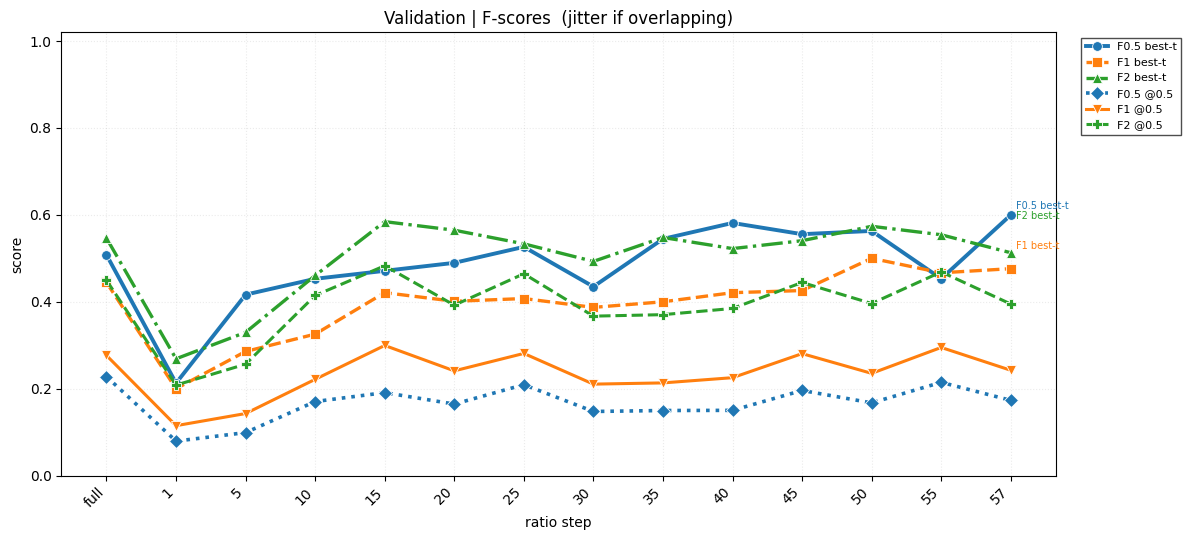

Saved: /kaggle/working/vlst_fp_followup_output/report_validation_fp_fn.png


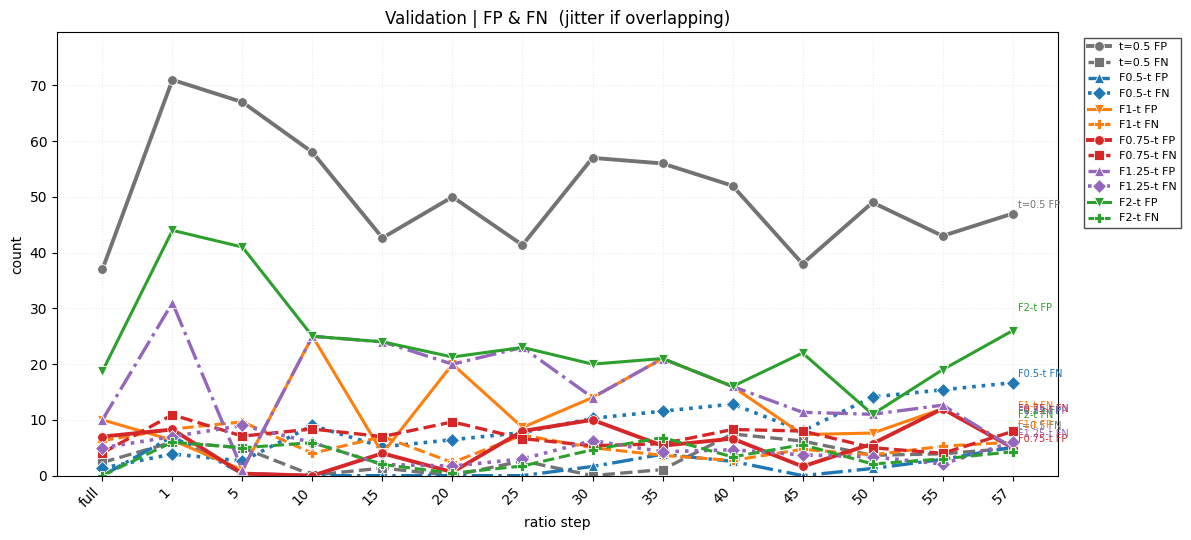

Saved: /kaggle/working/vlst_fp_followup_output/report_validation_fp.png


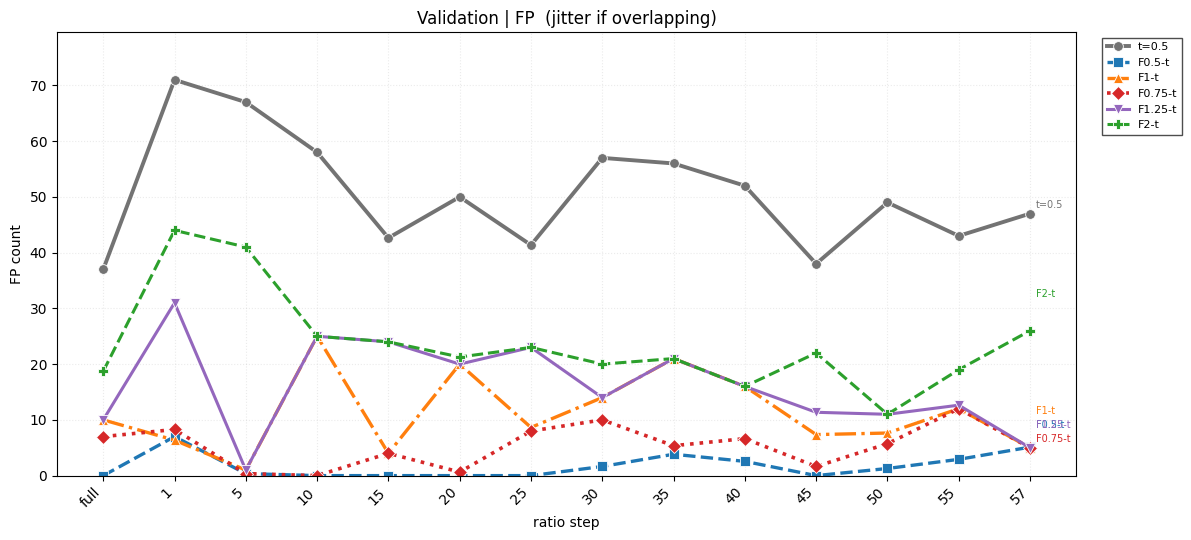

Saved: /kaggle/working/vlst_fp_followup_output/report_validation_fn.png


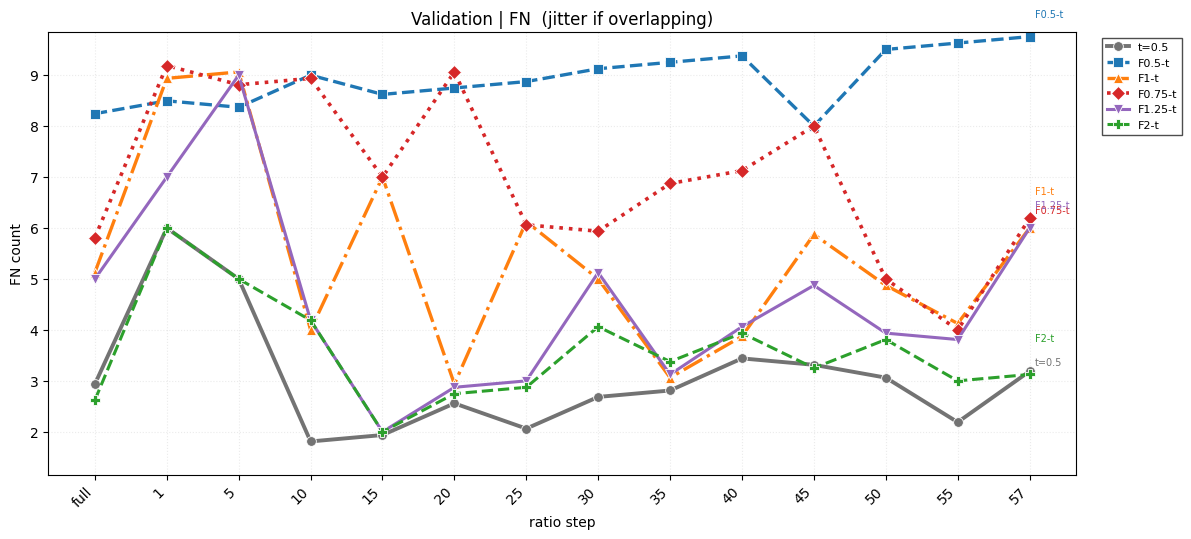

Saved: /kaggle/working/vlst_fp_followup_output/report_validation_auc.png


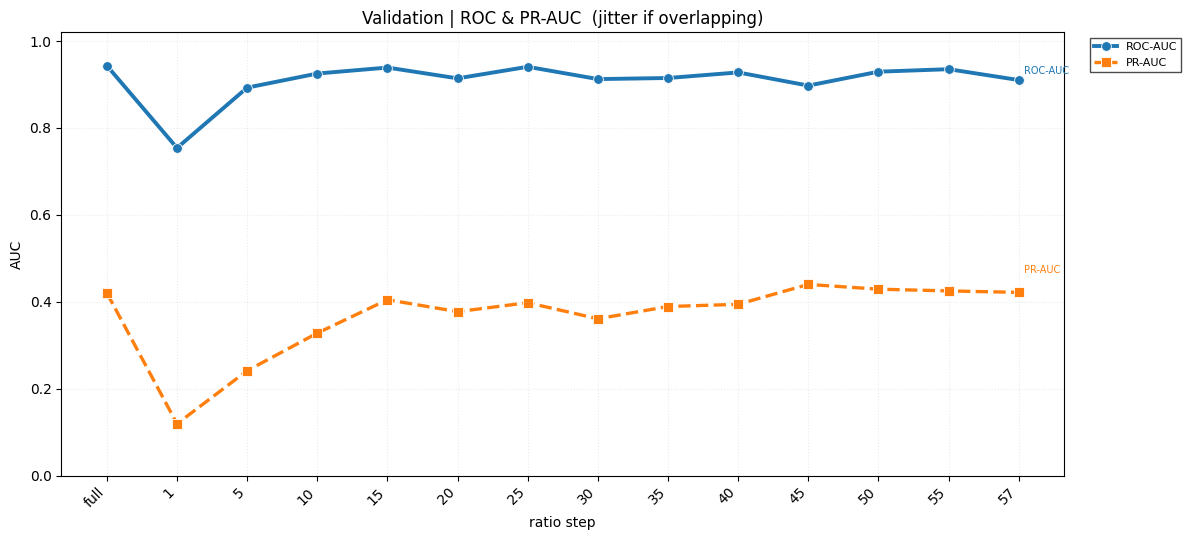


=== Report: Split_a (val-tuned t) ===
Saved: /kaggle/working/vlst_fp_followup_output/report_split_a_valt_fscores.png


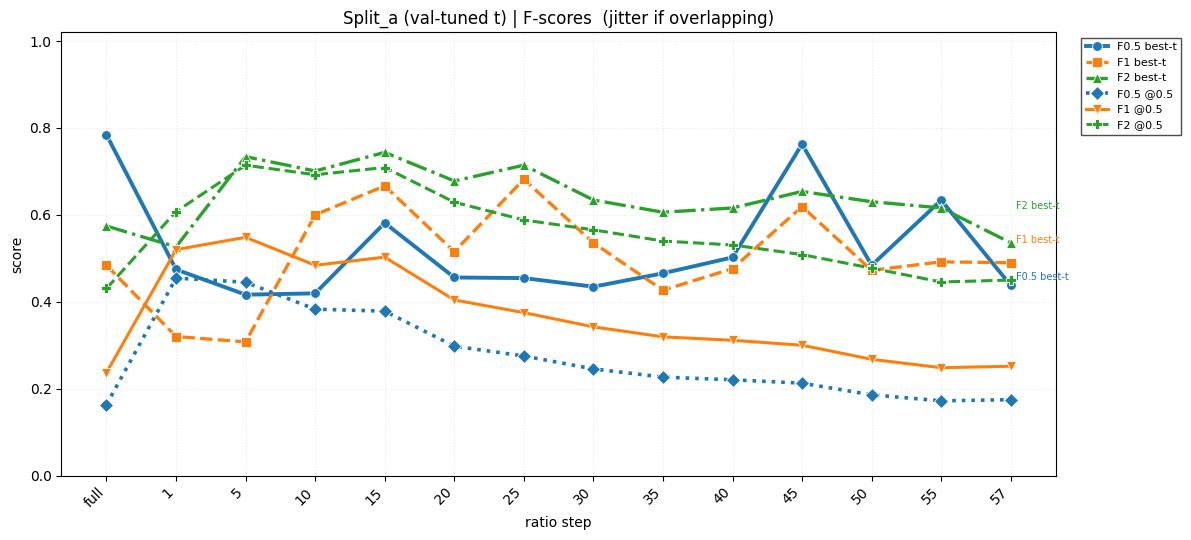

Saved: /kaggle/working/vlst_fp_followup_output/report_split_a_valt_fp_fn.png


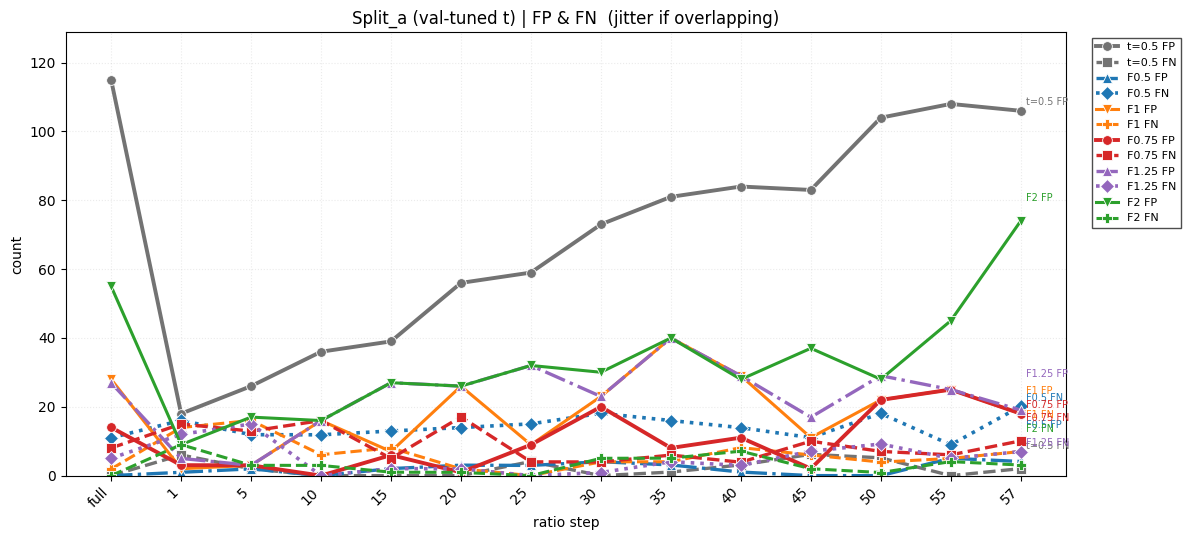

Saved: /kaggle/working/vlst_fp_followup_output/report_split_a_valt_fp.png


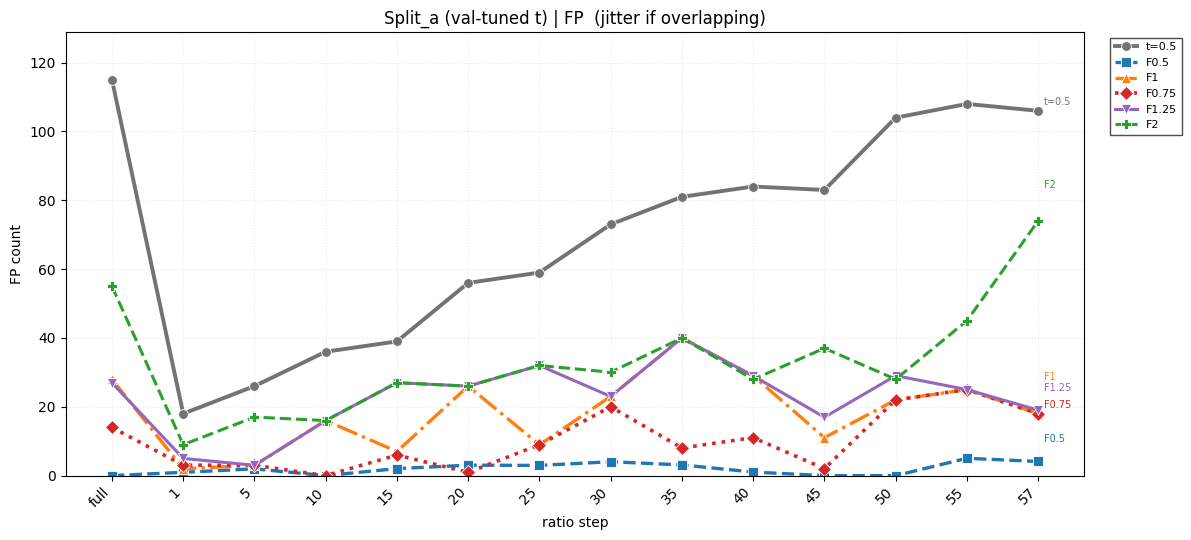

Saved: /kaggle/working/vlst_fp_followup_output/report_split_a_valt_fn.png


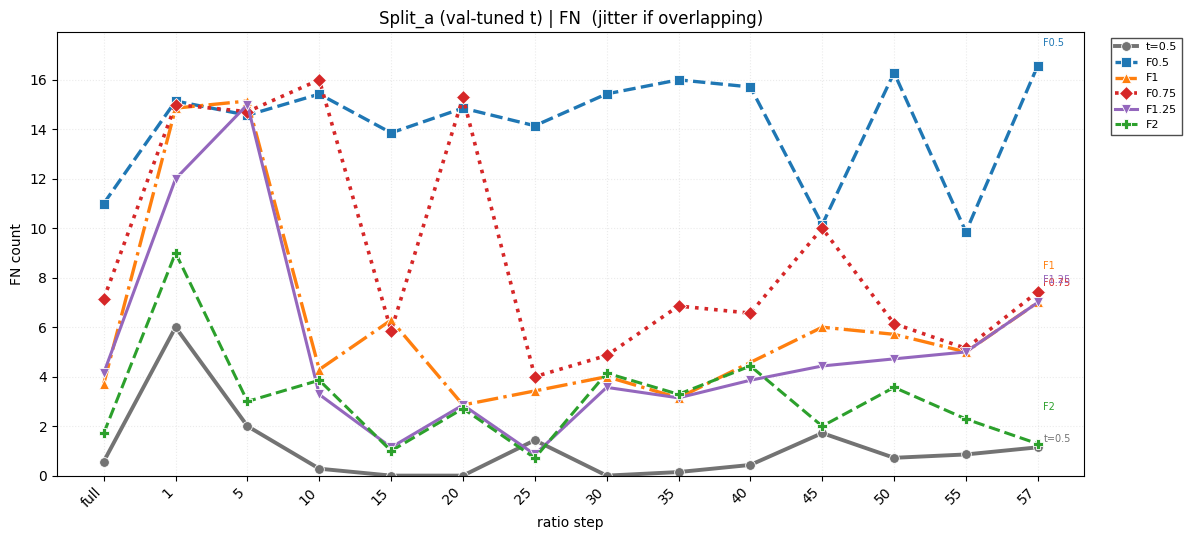

Saved: /kaggle/working/vlst_fp_followup_output/report_split_a_valt_auc.png


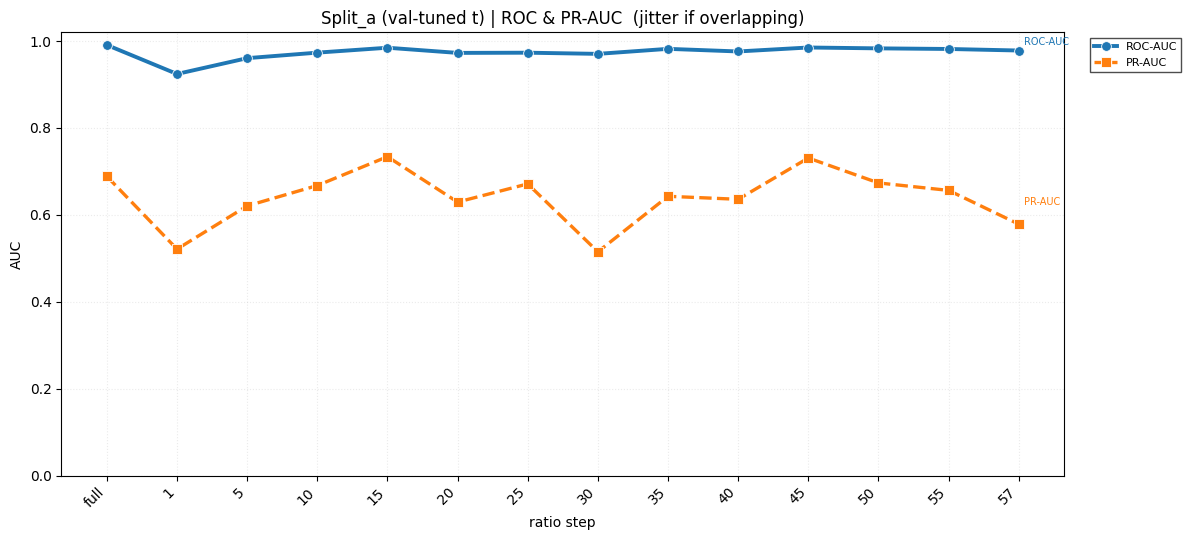


=== Report: Split_b (val-tuned t) ===
Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_valt_fscores.png


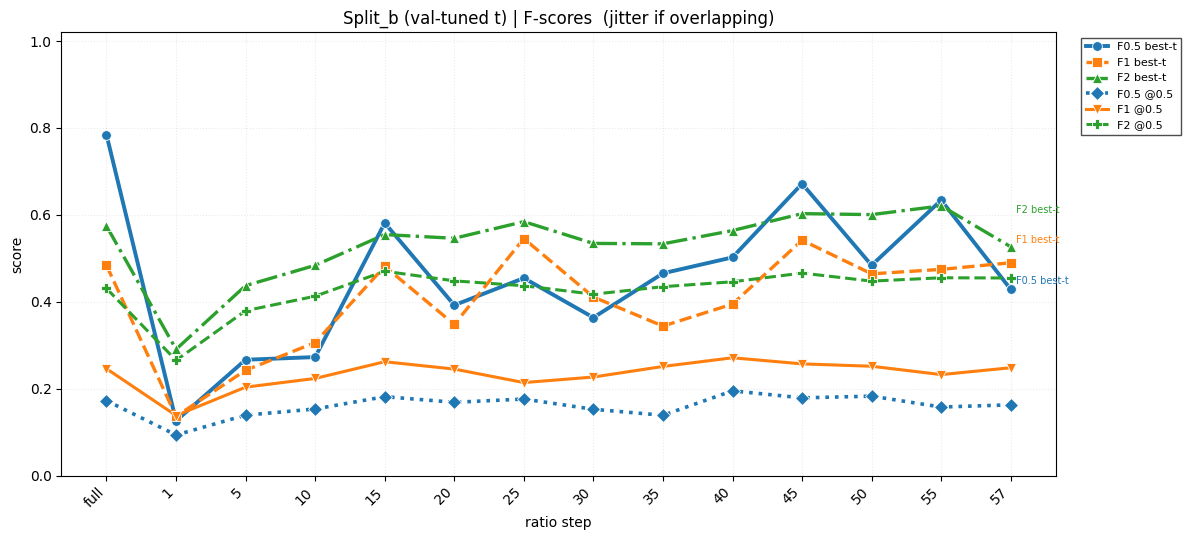

Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_valt_fp_fn.png


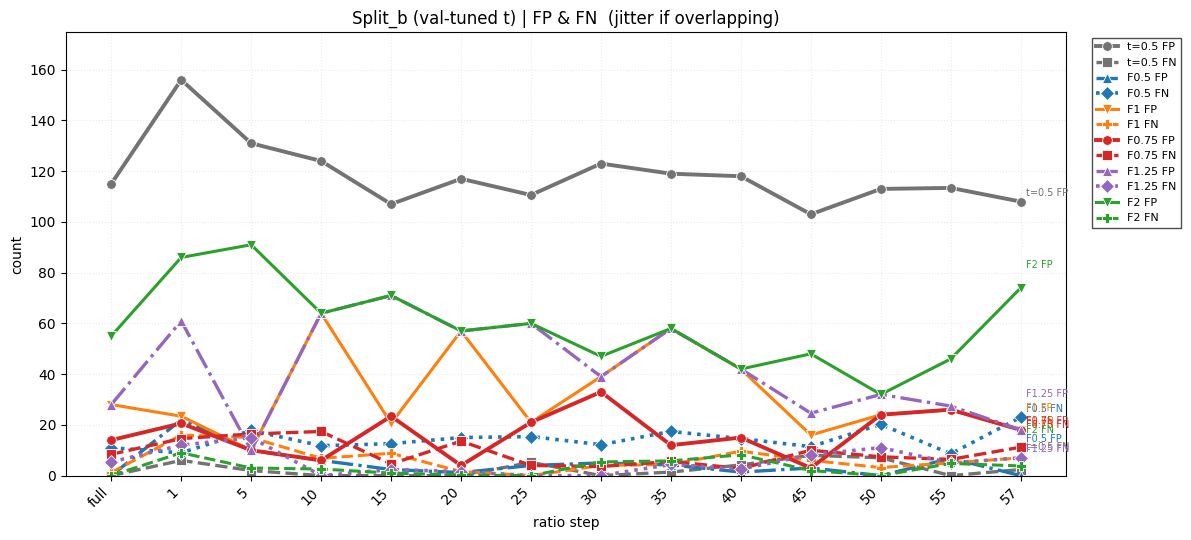

Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_valt_fp.png


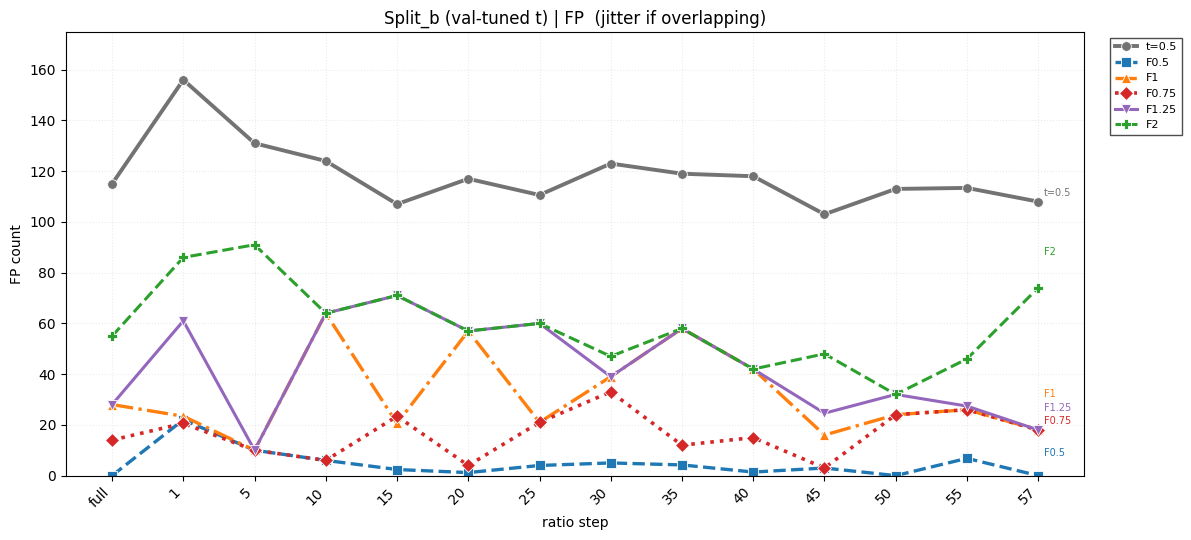

Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_valt_fn.png


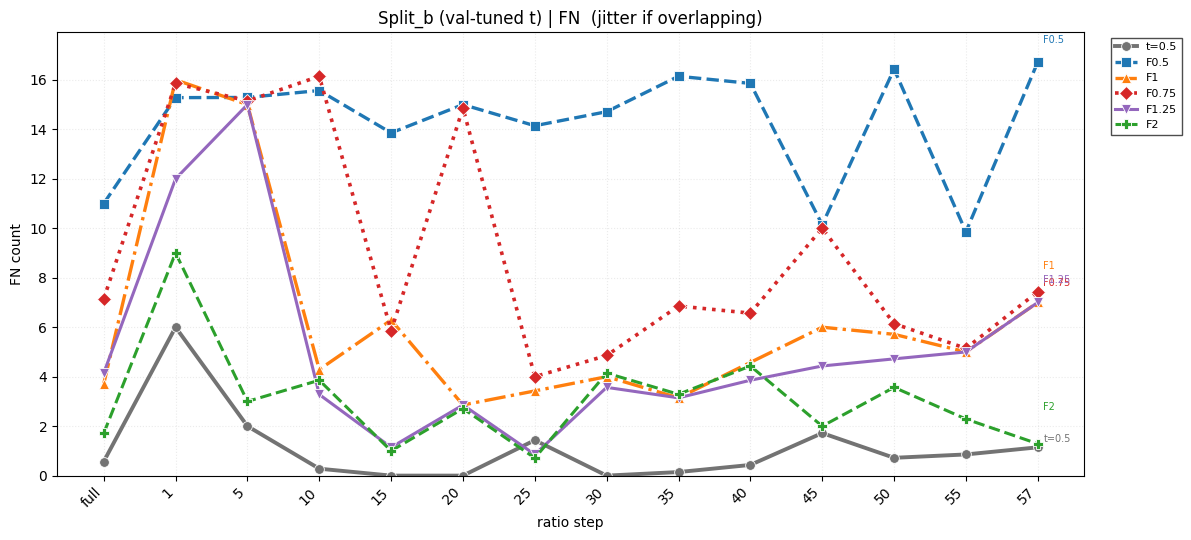

Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_valt_auc.png


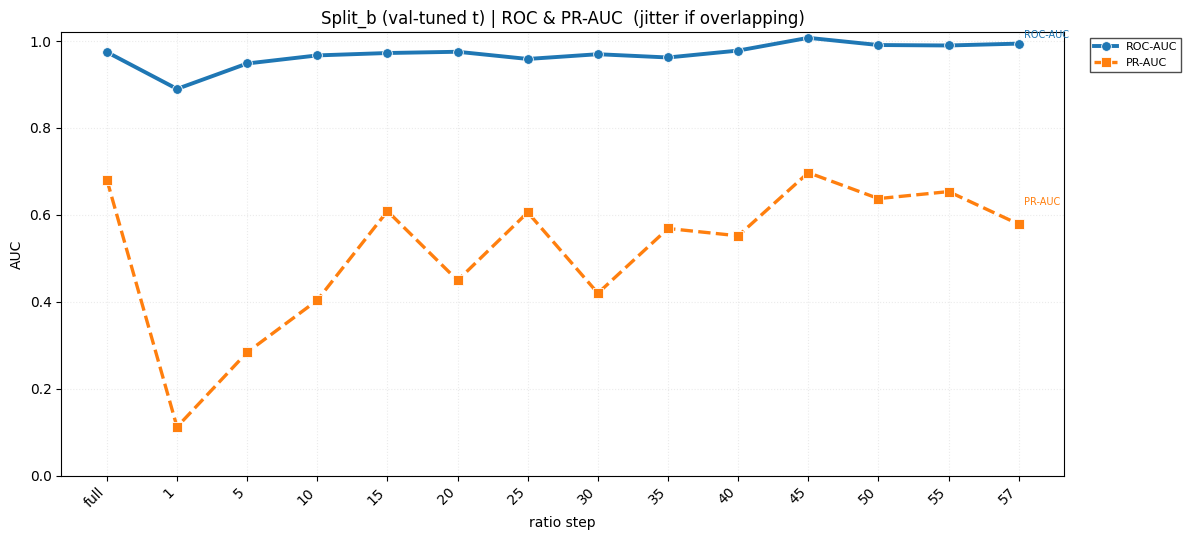


=== Report: Split_b (oracle t) ===
Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_oracle_fscores.png


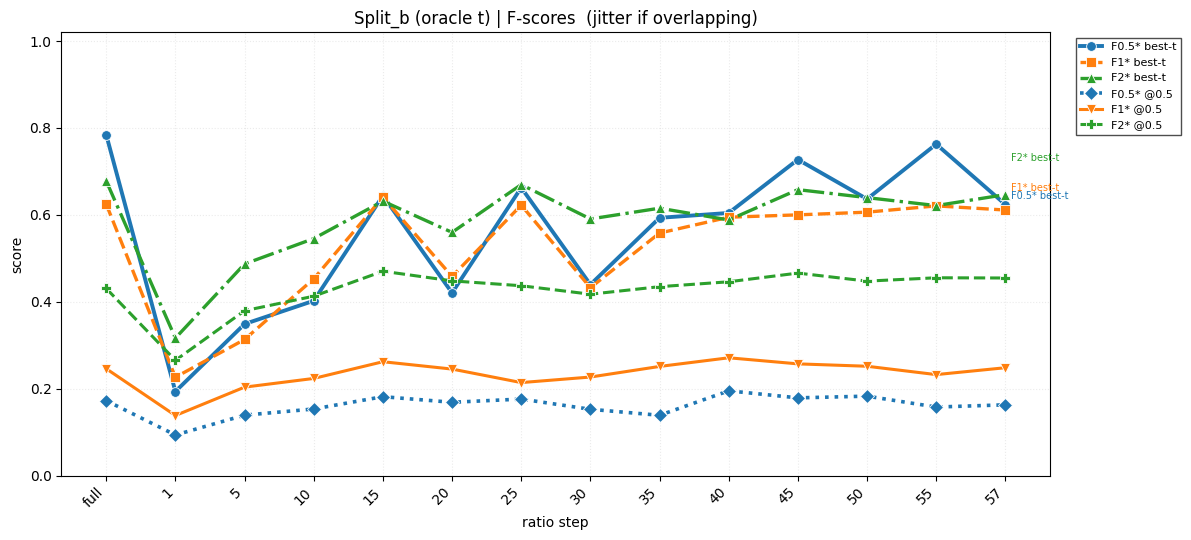

Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_oracle_fp_fn.png


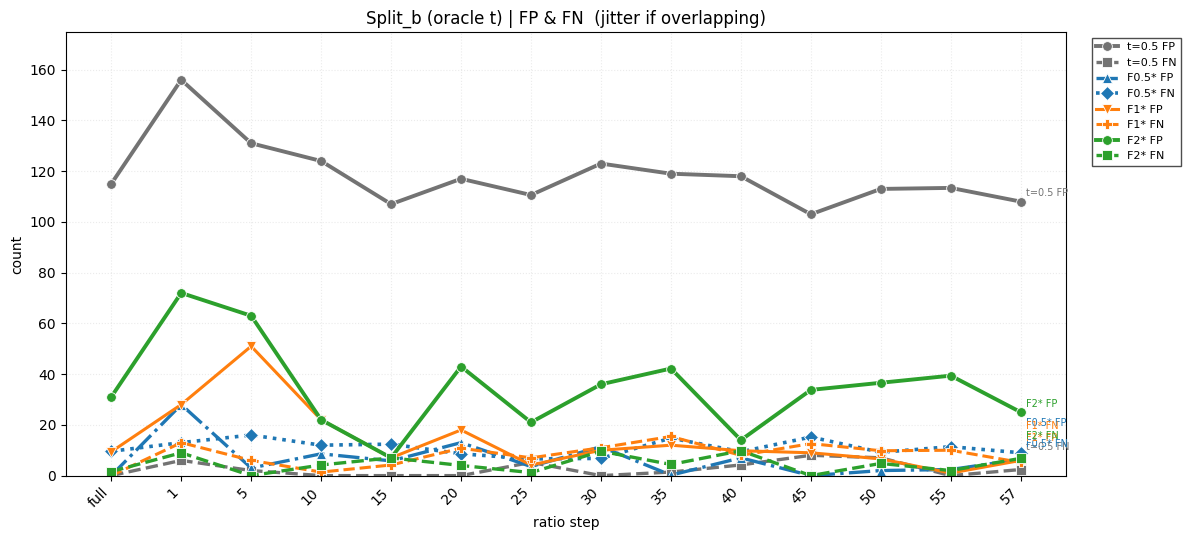

Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_oracle_fp.png


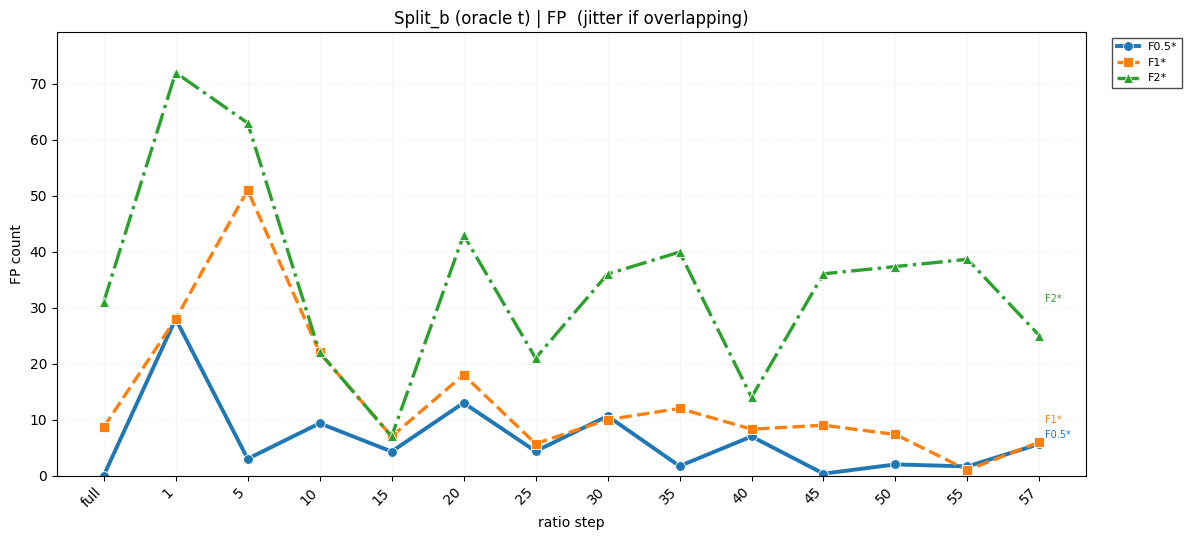

Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_oracle_fn.png


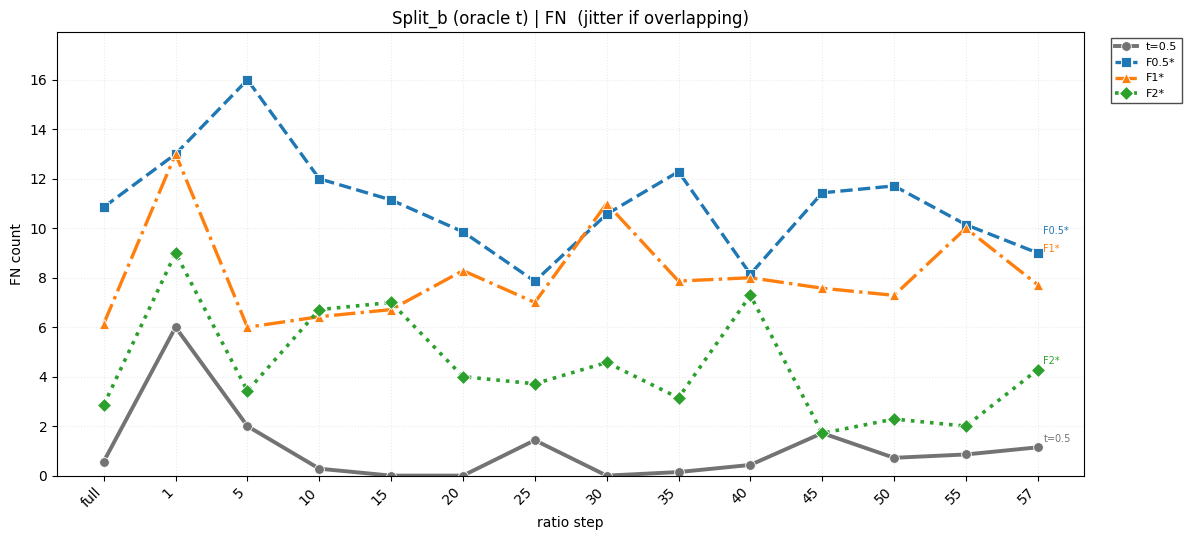

Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_oracle_auc.png


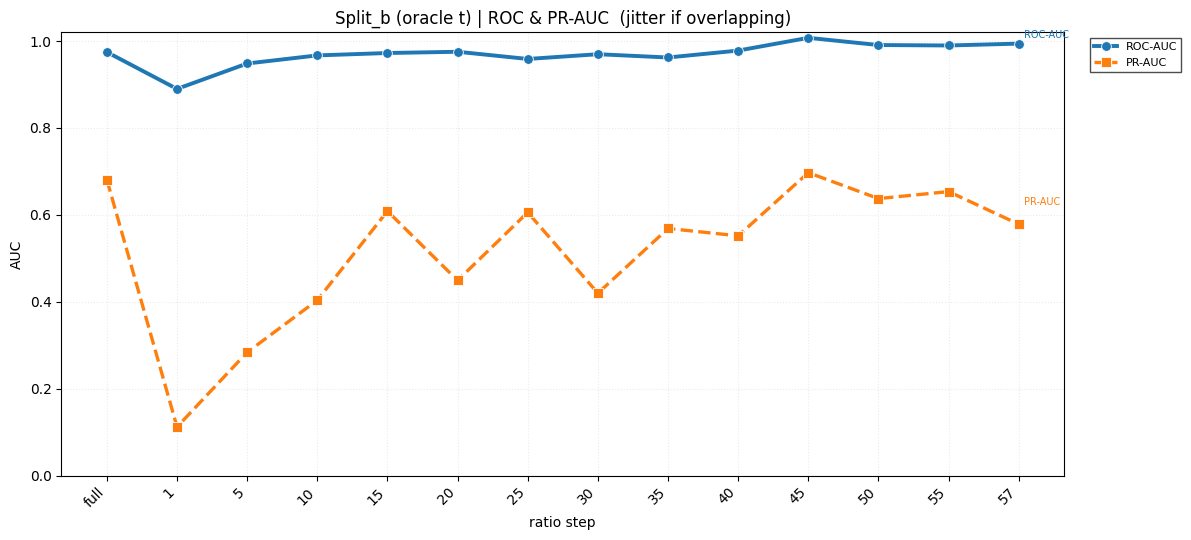

--- Split_b val-tuned tradeoff (extended policies) ---
Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_valt_tradeoff_fp_fn.png


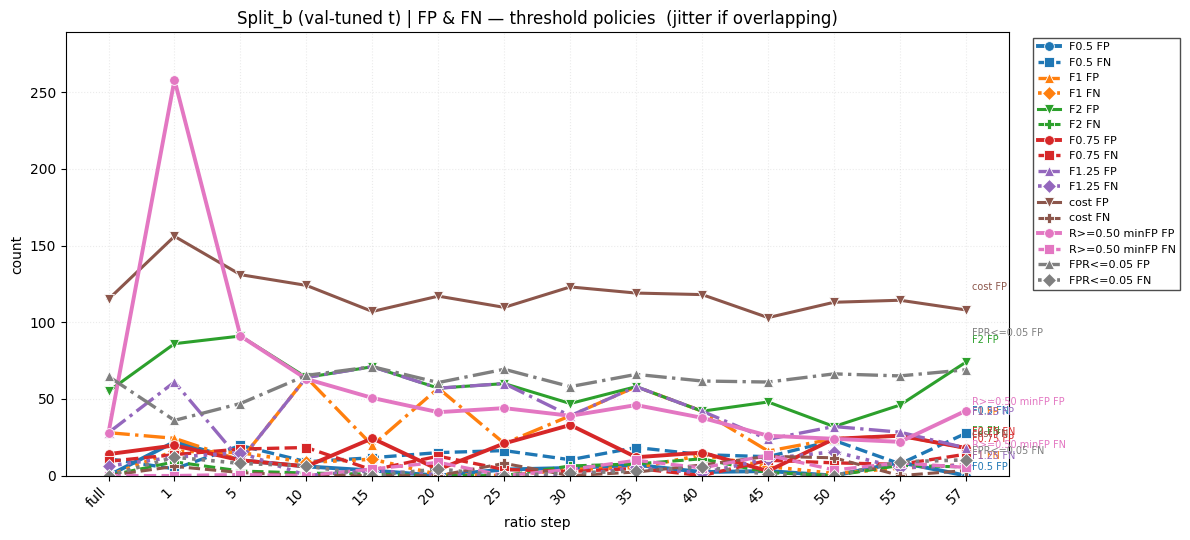

Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_valt_tradeoff_fpr.png


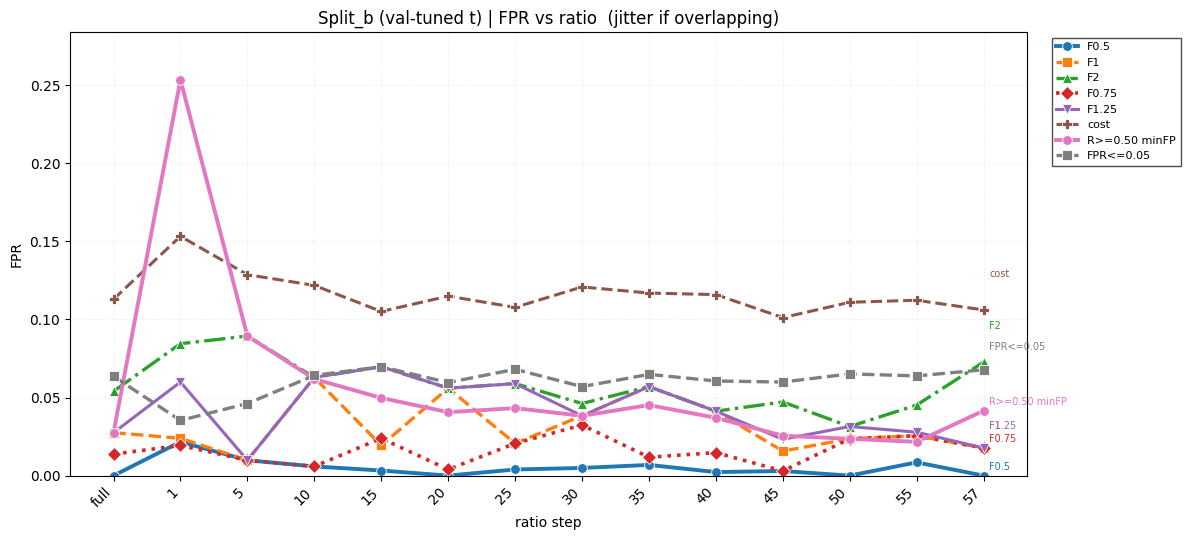

Saved: /kaggle/working/vlst_fp_followup_output/report_split_b_valt_tradeoff_frontier.png


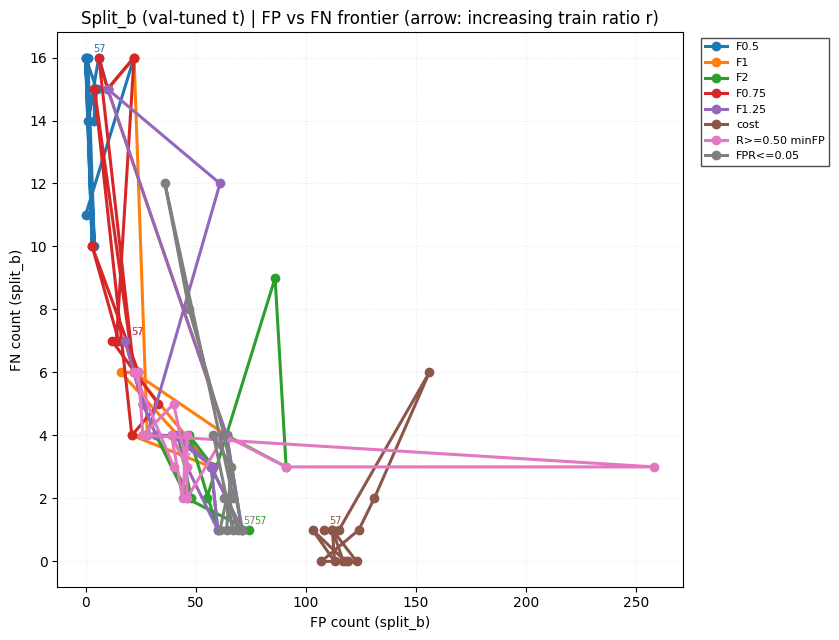

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    _ = len(sweep_df)
except NameError:
    sweep_df = pd.read_csv(os.path.join(OUTPUT_DIR, "fp_followup_ratio_sweep.csv"))

_curve_df = sweep_df.sort_values("ratio_requested").reset_index(drop=True)
_x = np.arange(len(_curve_df))
_xlabels = [
    "full" if k == "full_pool" else str(int(r))
    for k, r in zip(_curve_df["step_kind"], _curve_df["ratio_requested"])
]

# Marker / linestyle cycle — every line fully opaque (no alpha fade).
_LINE_STYLES = [
    {"marker": "o", "linestyle": "-", "linewidth": 2.8},
    {"marker": "s", "linestyle": "--", "linewidth": 2.4},
    {"marker": "^", "linestyle": "-.", "linewidth": 2.4},
    {"marker": "D", "linestyle": ":", "linewidth": 2.6},
    {"marker": "v", "linestyle": "-", "linewidth": 2.2},
    {"marker": "P", "linestyle": "--", "linewidth": 2.2},
]

_JITTER_FRAC = 0.018  # fraction of y-axis span for overlap separation


def _save_show(fig, save_name):
    out = os.path.join(OUTPUT_DIR, save_name)
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print("Saved:", out)
    plt.show()


def _style_ratio_axis(ax, ylabel, title):
    ax.set_xticks(_x)
    ax.set_xticklabels(_xlabels, rotation=45, ha="right")
    ax.set_xlabel("ratio step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25, linestyle=":")
    return ax


def _finalize_legend(ax):
    """Rebuild legend from every line on the axis (no missing series)."""
    handles, labels = ax.get_legend_handles_labels()
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    if not handles:
        return ax
    leg = ax.legend(
        handles,
        labels,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        fontsize=8,
        ncol=1,
        framealpha=1.0,
        edgecolor="0.3",
        fancybox=False,
    )
    for lh in leg.get_lines():
        lh.set_alpha(1.0)
    return ax


def _jitter_y(y_vals, span):
    """Spread nearly-identical y values so overlapping lines remain visible."""
    y = np.asarray(y_vals, dtype=float)
    out = y.copy()
    n = len(y)
    if n <= 1 or span <= 0:
        return out
    tol = max(1e-9, 0.002 * span)
    groups = []
    used = np.zeros(n, dtype=bool)
    order = np.argsort(y)
    for i in order:
        if used[i]:
            continue
        g = [i]
        used[i] = True
        for j in order:
            if used[j]:
                continue
            if abs(y[j] - y[i]) <= tol:
                g.append(j)
                used[j] = True
        groups.append(g)
    step = span * _JITTER_FRAC
    for g in groups:
        if len(g) <= 1:
            continue
        mid = (len(g) - 1) / 2.0
        for k, idx in enumerate(g):
            out[idx] = y[idx] + (k - mid) * step
    return out


def _draw_series(ax, series, span, annotate=True, style_offset=0, ymin_zero=False):
    for i, (label, col, color) in enumerate(series):
        if col not in _curve_df.columns:
            raise KeyError(f"Missing {col!r} — re-run §3 before §5")
        sty = _LINE_STYLES[(i + style_offset) % len(_LINE_STYLES)]
        y_raw = _curve_df[col].astype(float).to_numpy()
        y_plot = _jitter_y(y_raw, span)
        if ymin_zero:
            y_plot = np.maximum(y_plot, 0.0)
        ax.plot(
            _x,
            y_plot,
            color=color,
            alpha=1.0,
            markersize=7,
            markerfacecolor=color,
            markeredgecolor="white",
            markeredgewidth=0.6,
            label=label,
            **sty,
        )
        if annotate and len(_x) > 0:
            xi, yi = int(_x[-1]), float(y_plot[-1])
            ax.annotate(
                label,
                (xi, yi),
                textcoords="offset points",
                xytext=(4, 4 + (i % 3) * 10),
                fontsize=7,
                color=color,
                alpha=1.0,
                clip_on=False,
            )


def _plot_lines(ax, series, ylabel, title, ylim=None, annotate=True, ylim_tight=False, ymin_zero=False):
    """series: list of (label, col, color) — plot one column with jitter if needed."""
    ys_all = []
    for _lbl, col, _c in series:
        if col not in _curve_df.columns:
            raise KeyError(f"Missing {col!r} — re-run §3 before §5")
        ys_all.extend(_curve_df[col].astype(float).tolist())
    if not ys_all:
        return ax
    y_min, y_max = float(np.nanmin(ys_all)), float(np.nanmax(ys_all))
    if ymin_zero:
        y_min = max(0.0, y_min)
    span = max(y_max - y_min, 0.05)
    _draw_series(ax, series, span, annotate=annotate, style_offset=0, ymin_zero=ymin_zero)
    if ylim is not None:
        ax.set_ylim(*ylim)
    elif ylim_tight:
        pad = max(1.0, 0.1 * max(1.0, y_max - y_min))
        ax.set_ylim(max(0.0, y_min - pad), y_max + pad)
    else:
        pad = span * 0.12
        y_lo = max(0.0, y_min - pad) if ymin_zero else y_min - pad
        ax.set_ylim(y_lo, y_max + pad)
    _style_ratio_axis(ax, ylabel, title)
    _finalize_legend(ax)
    return ax


def _plot_f_curves(series, title, save_name):
    """Each entry: (name, col_best, col_05, color). Two passes: best-t and @0.5."""
    fig, ax = plt.subplots(figsize=(12, 5.5))
    flat_best = [(f"{name} best-t", col_best, color) for name, col_best, col_05, color in series]
    flat_05 = [(f"{name} @0.5", col_05, color) for name, col_best, col_05, color in series]
    span = 1.02
    _draw_series(ax, flat_best, span, annotate=True, style_offset=0)
    _draw_series(ax, flat_05, span, annotate=False, style_offset=3)
    ax.set_ylim(0, 1.02)
    _style_ratio_axis(ax, "score", title + "  (jitter if overlapping)")
    _finalize_legend(ax)
    fig.tight_layout()
    _save_show(fig, save_name)


def _plot_fp_fn(series, title, save_name):
    fig, ax = plt.subplots(figsize=(12, 5.5))
    flat = []
    for label, col_fp, col_fn, color in series:
        flat.append((f"{label} FP", col_fp, color))
        flat.append((f"{label} FN", col_fn, color))
    _plot_lines(ax, flat, "count", title + "  (jitter if overlapping)", ymin_zero=True)
    fig.tight_layout()
    _save_show(fig, save_name)


def _plot_auc(roc_col, pr_col, title, save_name):
    if roc_col not in _curve_df.columns:
        raise KeyError(f"Missing {roc_col!r} — re-run §3 before §5")
    fig, ax = plt.subplots(figsize=(12, 5.5))
    _plot_lines(
        ax,
        [("ROC-AUC", roc_col, "C0"), ("PR-AUC", pr_col, "C1")],
        "AUC",
        title + "  (jitter if overlapping)",
        ylim=(0, 1.02),
    )
    fig.tight_layout()
    _save_show(fig, save_name)



# --- Per-set reports: each eval set gets F-scores, FP&FN, FP-only, FN-only, ROC/PR-AUC ---
EVAL_SET_REPORTS = [
    {
        "slug": "validation",
        "title": "Validation",
        "f_scores": [
            ("F0.5", "val_f05_at_t_val", "val_f05_at_t05", "C0"),
            ("F1", "val_f1_at_t_val_f1", "val_f1_at_t05", "C1"),
            ("F2", "val_f2_at_t_val_f2", "val_f2_at_t05", "C2"),
        ],
        "fp_fn": [
            ("t=0.5", "val_t05_fp", "val_t05_fn", "0.45"),
            ("F0.5-t", "val_tval_fp", "val_tval_fn", "C0"),
            ("F1-t", "val_tval_f1_fp", "val_tval_f1_fn", "C1"),
            ("F0.75-t", "val_tval_f075_fp", "val_tval_f075_fn", "C3"),
            ("F1.25-t", "val_tval_f125_fp", "val_tval_f125_fn", "C4"),
            ("F2-t", "val_tval_f2_fp", "val_tval_f2_fn", "C2"),
        ],
        "fp_only": [
            ("t=0.5", "val_t05_fp", "0.45"),
            ("F0.5-t", "val_tval_fp", "C0"),
            ("F1-t", "val_tval_f1_fp", "C1"),
            ("F0.75-t", "val_tval_f075_fp", "C3"),
            ("F1.25-t", "val_tval_f125_fp", "C4"),
            ("F2-t", "val_tval_f2_fp", "C2"),
        ],
        "fn_only": [
            ("t=0.5", "val_t05_fn", "0.45"),
            ("F0.5-t", "val_tval_fn", "C0"),
            ("F1-t", "val_tval_f1_fn", "C1"),
            ("F0.75-t", "val_tval_f075_fn", "C3"),
            ("F1.25-t", "val_tval_f125_fn", "C4"),
            ("F2-t", "val_tval_f2_fn", "C2"),
        ],
        "auc": ("val_roc_auc", "val_pr_auc"),
        "fp_tight": False,
    },
    {
        "slug": "split_a_valt",
        "title": "Split_a (val-tuned t)",
        "f_scores": [
            ("F0.5", "a_tval_f05", "a_t05_f05", "C0"),
            ("F1", "a_tval_f1_f1", "a_t05_f1", "C1"),
            ("F2", "a_tval_f2_f2", "a_t05_f2", "C2"),
        ],
        "fp_fn": [
            ("t=0.5", "a_t05_cm01", "a_t05_cm10", "0.45"),
            ("F0.5", "a_tval_cm01", "a_tval_cm10", "C0"),
            ("F1", "a_tval_f1_cm01", "a_tval_f1_cm10", "C1"),
            ("F0.75", "a_tval_f075_cm01", "a_tval_f075_cm10", "C3"),
            ("F1.25", "a_tval_f125_cm01", "a_tval_f125_cm10", "C4"),
            ("F2", "a_tval_f2_cm01", "a_tval_f2_cm10", "C2"),
        ],
        "fp_only": [
            ("t=0.5", "a_t05_cm01", "0.45"),
            ("F0.5", "a_tval_cm01", "C0"),
            ("F1", "a_tval_f1_cm01", "C1"),
            ("F0.75", "a_tval_f075_cm01", "C3"),
            ("F1.25", "a_tval_f125_cm01", "C4"),
            ("F2", "a_tval_f2_cm01", "C2"),
        ],
        "fn_only": [
            ("t=0.5", "a_t05_cm10", "0.45"),
            ("F0.5", "a_tval_cm10", "C0"),
            ("F1", "a_tval_f1_cm10", "C1"),
            ("F0.75", "a_tval_f075_cm10", "C3"),
            ("F1.25", "a_tval_f125_cm10", "C4"),
            ("F2", "a_tval_f2_cm10", "C2"),
        ],
        "auc": ("hold_a_roc_auc", "hold_a_pr_auc"),
        "fp_tight": False,
    },
    {
        "slug": "split_b_valt",
        "title": "Split_b (val-tuned t)",
        "f_scores": [
            ("F0.5", "b_tval_f05", "b_t05_f05", "C0"),
            ("F1", "b_tval_f1_f1", "b_t05_f1", "C1"),
            ("F2", "b_tval_f2_f2", "b_t05_f2", "C2"),
        ],
        "fp_fn": [
            ("t=0.5", "b_t05_cm01", "b_t05_cm10", "0.45"),
            ("F0.5", "b_tval_cm01", "b_tval_cm10", "C0"),
            ("F1", "b_tval_f1_cm01", "b_tval_f1_cm10", "C1"),
            ("F0.75", "b_tval_f075_cm01", "b_tval_f075_cm10", "C3"),
            ("F1.25", "b_tval_f125_cm01", "b_tval_f125_cm10", "C4"),
            ("F2", "b_tval_f2_cm01", "b_tval_f2_cm10", "C2"),
        ],
        "fp_only": [
            ("t=0.5", "b_t05_cm01", "0.45"),
            ("F0.5", "b_tval_cm01", "C0"),
            ("F1", "b_tval_f1_cm01", "C1"),
            ("F0.75", "b_tval_f075_cm01", "C3"),
            ("F1.25", "b_tval_f125_cm01", "C4"),
            ("F2", "b_tval_f2_cm01", "C2"),
        ],
        "fn_only": [
            ("t=0.5", "b_t05_cm10", "0.45"),
            ("F0.5", "b_tval_cm10", "C0"),
            ("F1", "b_tval_f1_cm10", "C1"),
            ("F0.75", "b_tval_f075_cm10", "C3"),
            ("F1.25", "b_tval_f125_cm10", "C4"),
            ("F2", "b_tval_f2_cm10", "C2"),
        ],
        "auc": ("split_b_roc_auc", "split_b_pr_auc"),
        "fp_tight": False,
    },
    {
        "slug": "split_b_oracle",
        "title": "Split_b (oracle t)",
        "f_scores": [
            ("F0.5*", "b_thold_b_f05", "b_hold_f05_at_t05", "C0"),
            ("F1*", "b_thold_b_f1_f1", "b_hold_f1_at_t05", "C1"),
            ("F2*", "b_thold_b_f2_f2", "b_hold_f2_at_t05", "C2"),
        ],
        "fp_fn": [
            ("t=0.5", "b_t05_cm01", "b_t05_cm10", "0.45"),
            ("F0.5*", "b_thold_b_cm01", "b_thold_b_cm10", "C0"),
            ("F1*", "b_thold_b_f1_cm01", "b_thold_b_f1_cm10", "C1"),
            ("F2*", "b_thold_b_f2_cm01", "b_thold_b_f2_cm10", "C2"),
        ],
        "fp_only": [
            ("F0.5*", "b_thold_b_cm01", "C0"),
            ("F1*", "b_thold_b_f1_cm01", "C1"),
            ("F2*", "b_thold_b_f2_cm01", "C2"),
        ],
        "fn_only": [
            ("t=0.5", "b_t05_cm10", "0.45"),
            ("F0.5*", "b_thold_b_cm10", "C0"),
            ("F1*", "b_thold_b_f1_cm10", "C1"),
            ("F2*", "b_thold_b_f2_cm10", "C2"),
        ],
        "auc": ("split_b_roc_auc", "split_b_pr_auc"),
        "fp_tight": True,
    },
]




def _plot_metric_only(series, ylabel, title, save_name, ylim_tight=False, ymin_zero=True):
    fig, ax = plt.subplots(figsize=(12, 5.5))
    _plot_lines(
        ax,
        series,
        ylabel,
        title + "  (jitter if overlapping)",
        ylim_tight=ylim_tight,
        ymin_zero=ymin_zero,
    )
    fig.tight_layout()
    _save_show(fig, save_name)



def run_eval_plots_for_sweep(
    sweep_df_in,
    output_dir,
    plot_prefix: str = "",
    title_prefix: str = "",
):
    """§5 report block (5 plots × eval sets + split_b tradeoff) for any sweep dataframe."""
    global _curve_df, _x, _xlabels, OUTPUT_DIR, _save_show
    _out_saved = OUTPUT_DIR
    _save_saved = _save_show
    OUTPUT_DIR = str(output_dir)
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    def _save_local(fig, save_name):
        out = os.path.join(OUTPUT_DIR, plot_prefix + save_name)
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print("Saved:", out)
        plt.show()

    _save_show = _save_local
    _curve_df = sweep_df_in.sort_values("ratio_requested").reset_index(drop=True)
    _x = np.arange(len(_curve_df))
    _xlabels = [
        "full" if k == "full_pool" else str(int(r))
        for k, r in zip(_curve_df["step_kind"], _curve_df["ratio_requested"])
    ]
    print(f"--- {title_prefix}per-set reports (5 plots each) ---")
    for _rep in EVAL_SET_REPORTS:
        _rep_m = dict(_rep)
        if title_prefix:
            _rep_m["title"] = title_prefix + _rep["title"]
        _report_one_eval_set(_rep_m)
    print(f"--- {title_prefix}split_b val-tuned tradeoff ---")
    _plot_split_b_valt_tradeoff()
    OUTPUT_DIR = _out_saved
    _save_show = _save_saved

def _report_one_eval_set(rep: dict):
    slug = rep["slug"]
    title = rep["title"]
    fp_tight = bool(rep.get("fp_tight", False))
    print(f"\n=== Report: {title} ===")
    _plot_f_curves(rep["f_scores"], f"{title} | F-scores", f"report_{slug}_fscores.png")
    _plot_fp_fn(rep["fp_fn"], f"{title} | FP & FN", f"report_{slug}_fp_fn.png")
    _plot_metric_only(
        rep["fp_only"],
        "FP count",
        f"{title} | FP",
        f"report_{slug}_fp.png",
        ylim_tight=fp_tight,
    )
    _plot_metric_only(rep["fn_only"], "FN count", f"{title} | FN", f"report_{slug}_fn.png")
    roc_col, pr_col = rep["auc"]
    _plot_auc(roc_col, pr_col, f"{title} | ROC & PR-AUC", f"report_{slug}_auc.png")


print("--- Per-set reports (5 plots each: F-scores, FP&FN, FP, FN, AUC) ---")
for _rep in EVAL_SET_REPORTS:
    _report_one_eval_set(_rep)

# --- Split_b val-tuned: FP/FN and FPR vs train ratio (extended threshold policies) ---
_recall_min = float(os.environ.get("VLST_FP_FOLLOWUP_RECALL_MIN", "0.5"))
_fpr_max = float(os.environ.get("VLST_FP_FOLLOWUP_FPR_MAX", "0.05"))

SPLIT_B_VALT_TRADEOFF_POLICIES = [
    ("F0.5", "b_tval_cm01", "b_tval_cm10", "b_tval_fpr", "C0"),
    ("F1", "b_tval_f1_cm01", "b_tval_f1_cm10", "b_tval_f1_fpr", "C1"),
    ("F2", "b_tval_f2_cm01", "b_tval_f2_cm10", "b_tval_f2_fpr", "C2"),
    ("F0.75", "b_tval_f075_cm01", "b_tval_f075_cm10", "b_tval_f075_fpr", "C3"),
    ("F1.25", "b_tval_f125_cm01", "b_tval_f125_cm10", "b_tval_f125_fpr", "C4"),
    ("cost", "b_tval_cost_cm01", "b_tval_cost_cm10", "b_tval_cost_fpr", "C5"),
    (f"R>={_recall_min:.2f} minFP", "b_tval_rminfp_cm01", "b_tval_rminfp_cm10", "b_tval_rminfp_fpr", "C6"),
    (f"FPR<={_fpr_max:.2f}", "b_tval_fprcap_cm01", "b_tval_fprcap_cm10", "b_tval_fprcap_fpr", "C7"),
]


def _plot_split_b_valt_tradeoff():
    """FP & FN vs ratio, FPR vs ratio, and FP–FN frontier for split_b @ val-tuned t."""
    title_base = "Split_b (val-tuned t)"
    fp_fn_series = [
        (name, col_fp, col_fn, color)
        for name, col_fp, col_fn, _col_fpr, color in SPLIT_B_VALT_TRADEOFF_POLICIES
    ]
    _plot_fp_fn(
        fp_fn_series,
        f"{title_base} | FP & FN — threshold policies",
        "report_split_b_valt_tradeoff_fp_fn.png",
    )
    fpr_series = [
        (name, col_fpr, color)
        for name, _col_fp, _col_fn, col_fpr, color in SPLIT_B_VALT_TRADEOFF_POLICIES
    ]
    _plot_metric_only(
        fpr_series,
        "FPR",
        f"{title_base} | FPR vs ratio",
        "report_split_b_valt_tradeoff_fpr.png",
    )
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    for name, col_fp, col_fn, _col_fpr, color in SPLIT_B_VALT_TRADEOFF_POLICIES:
        if col_fp not in _curve_df.columns or col_fn not in _curve_df.columns:
            raise KeyError(f"Missing {col_fp!r}/{col_fn!r} — re-run §3 before §5")
        fp = _curve_df[col_fp].astype(float).to_numpy()
        fn = _curve_df[col_fn].astype(float).to_numpy()
        ax.plot(fp, fn, color=color, alpha=1.0, linewidth=2.2, marker="o", markersize=6, label=name)
        if len(fp) > 0:
            ax.annotate(
                str(_xlabels[-1]),
                (fp[-1], fn[-1]),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=7,
                color=color,
            )
    ax.set_xlabel("FP count (split_b)")
    ax.set_ylabel("FN count (split_b)")
    ax.set_title(f"{title_base} | FP vs FN frontier (arrow: increasing train ratio r)")
    ax.grid(True, alpha=0.25, linestyle=":")
    _finalize_legend(ax)
    fig.tight_layout()
    _save_show(fig, "report_split_b_valt_tradeoff_frontier.png")


print("--- Split_b val-tuned tradeoff (extended policies) ---")
_plot_split_b_valt_tradeoff()


### 6.1 Curves — MaxFP CSV


--- MaxFP per-set reports (5 plots each) ---

=== Report: MaxFP | Validation ===
Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_validation_fscores.png


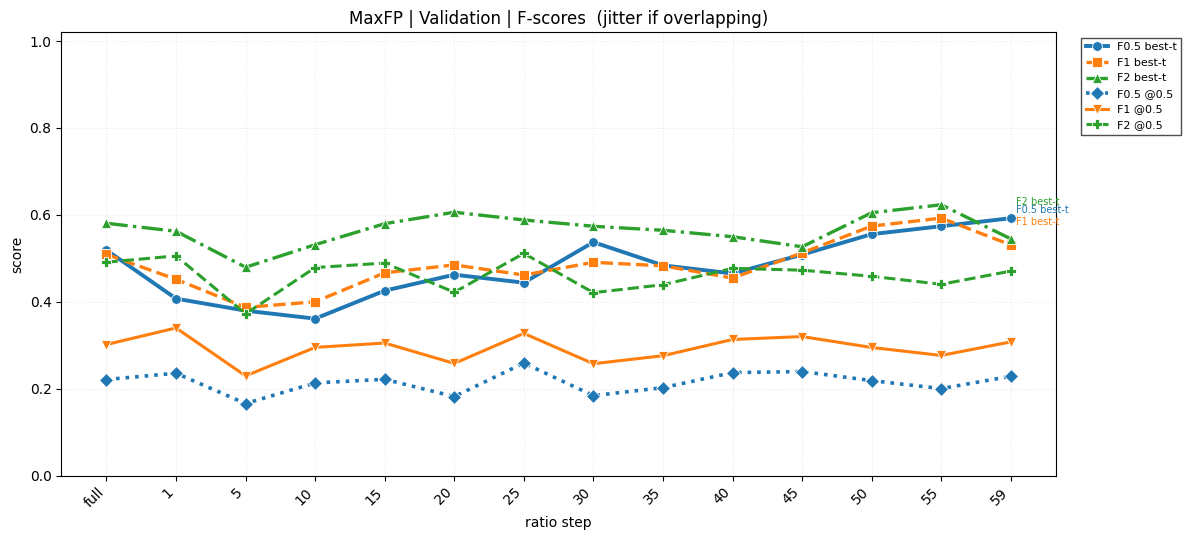

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_validation_fp_fn.png


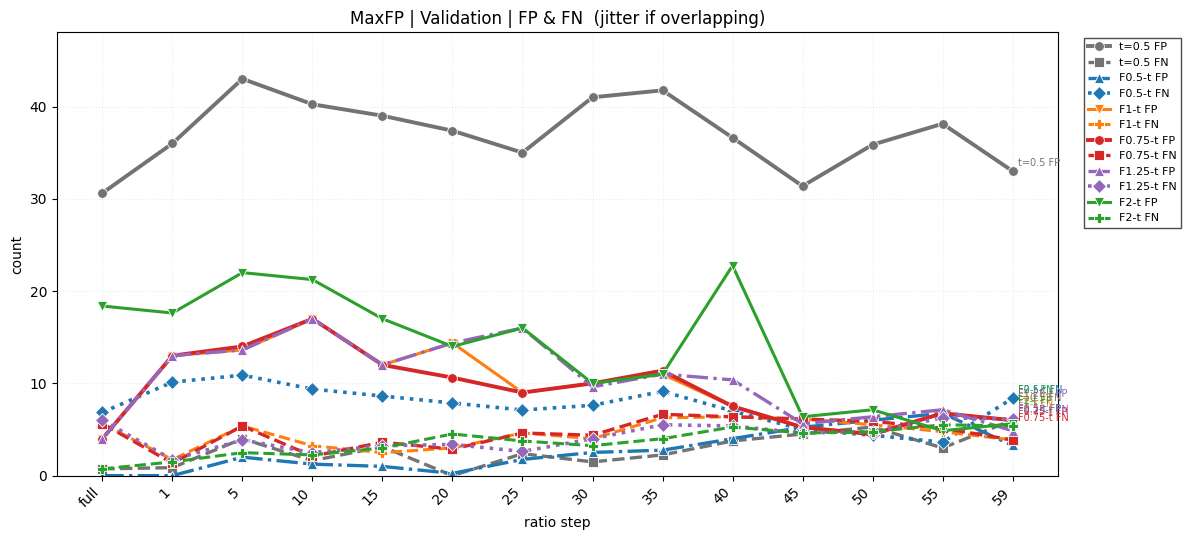

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_validation_fp.png


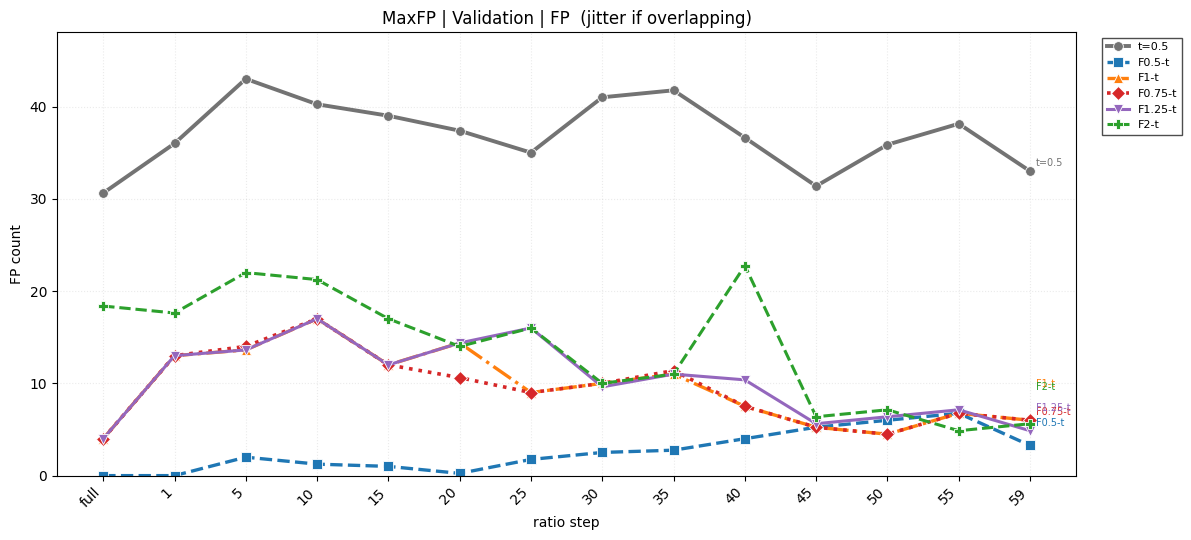

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_validation_fn.png


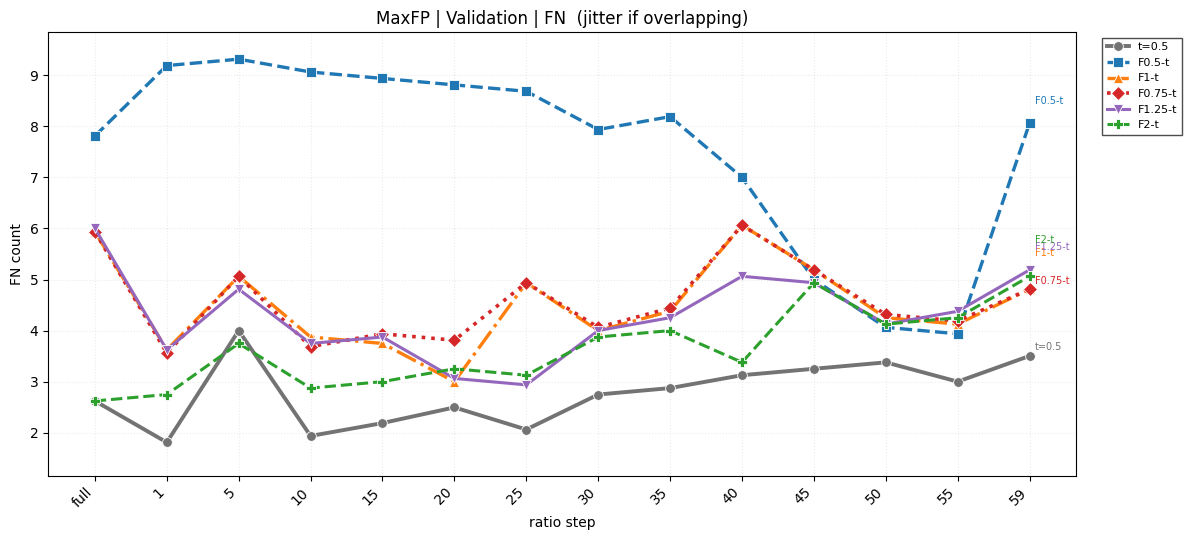

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_validation_auc.png


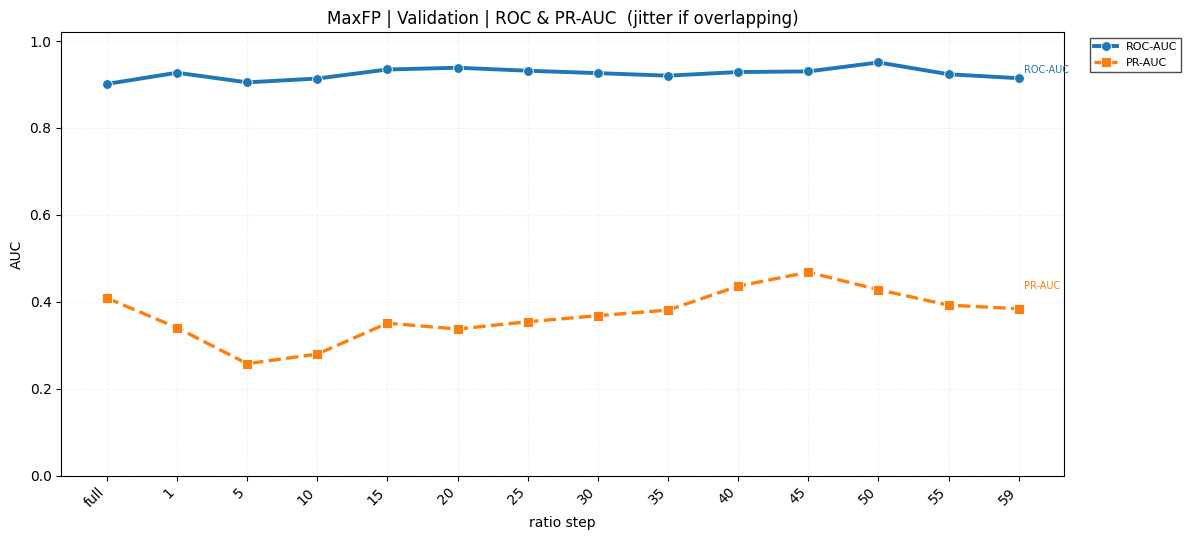


=== Report: MaxFP | Split_a (val-tuned t) ===
Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_a_valt_fscores.png


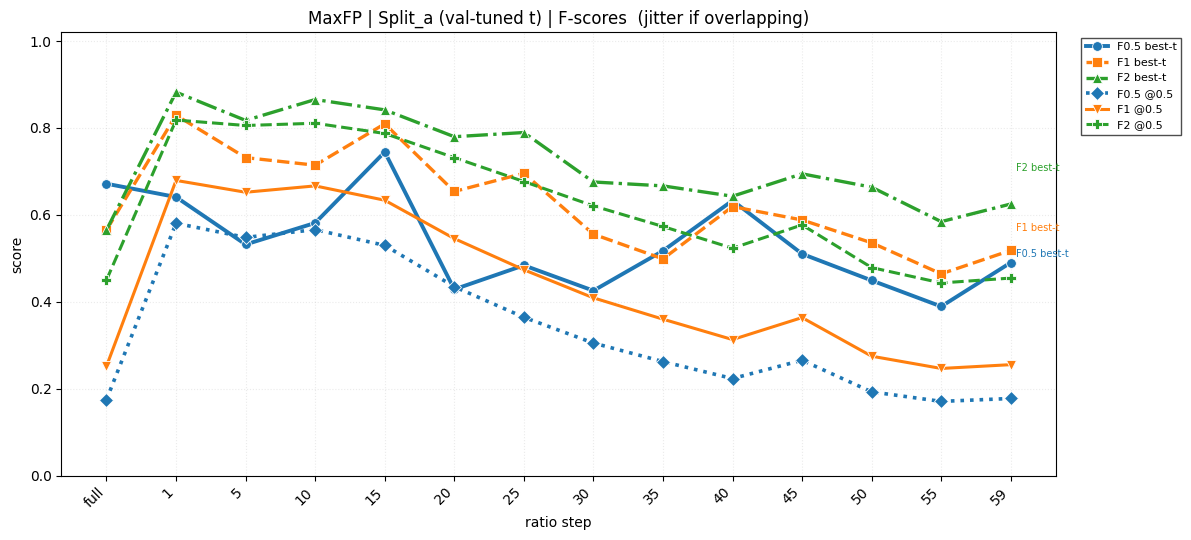

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_a_valt_fp_fn.png


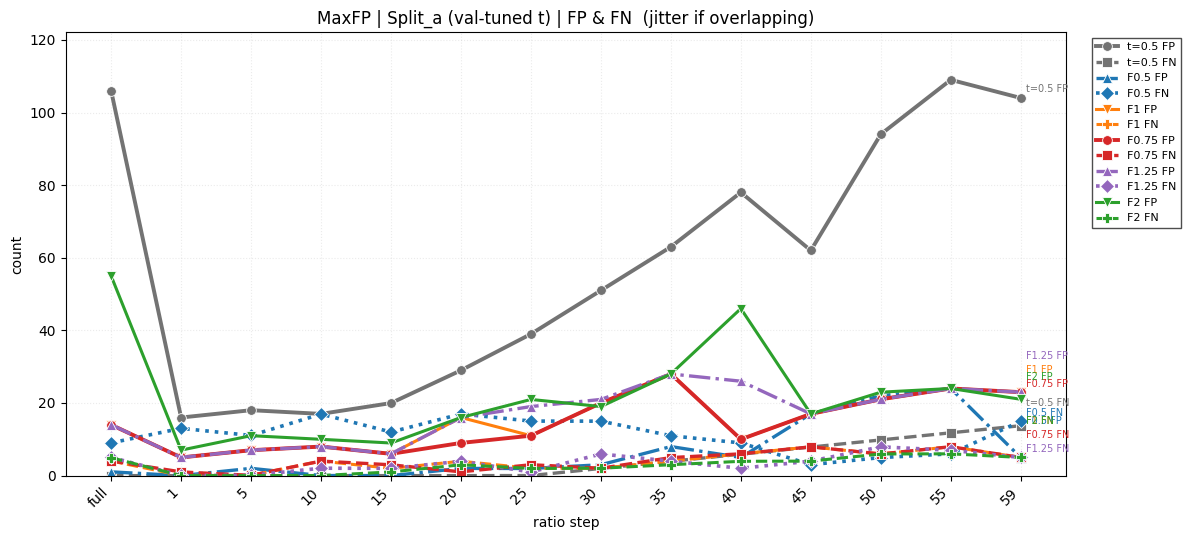

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_a_valt_fp.png


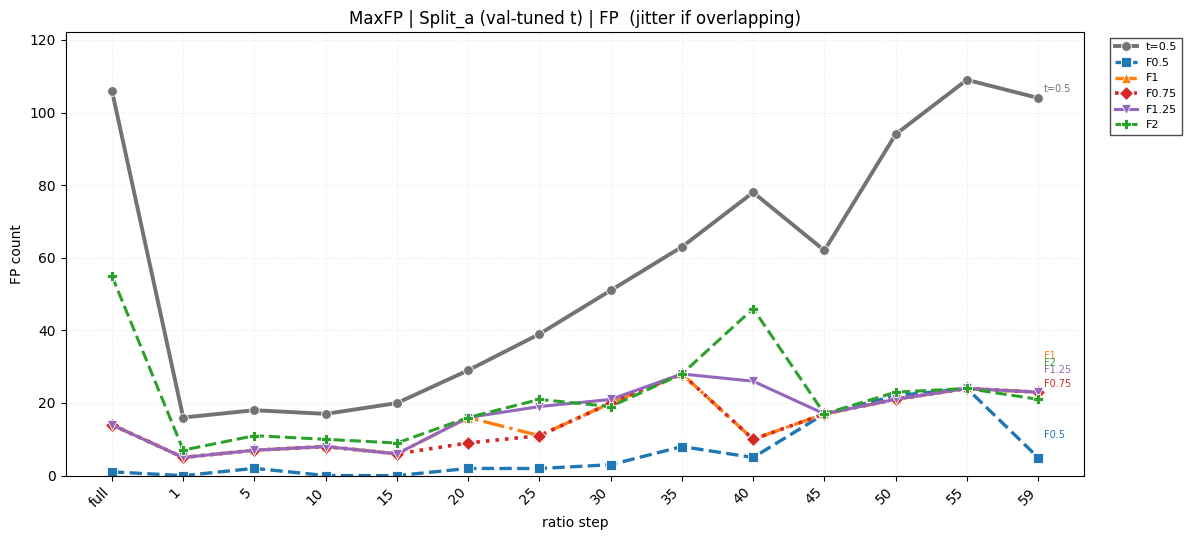

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_a_valt_fn.png


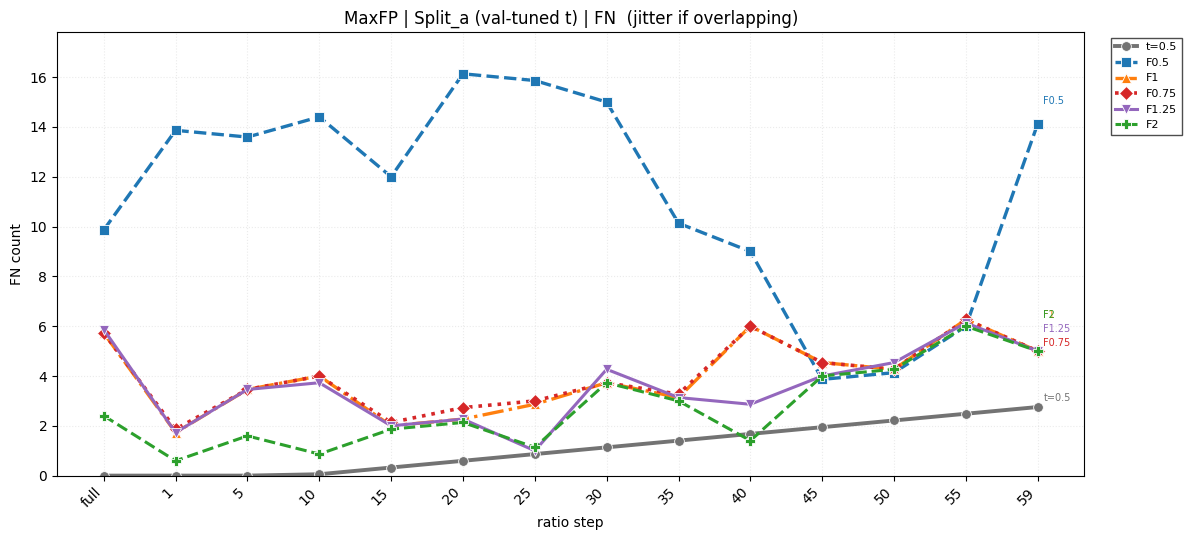

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_a_valt_auc.png


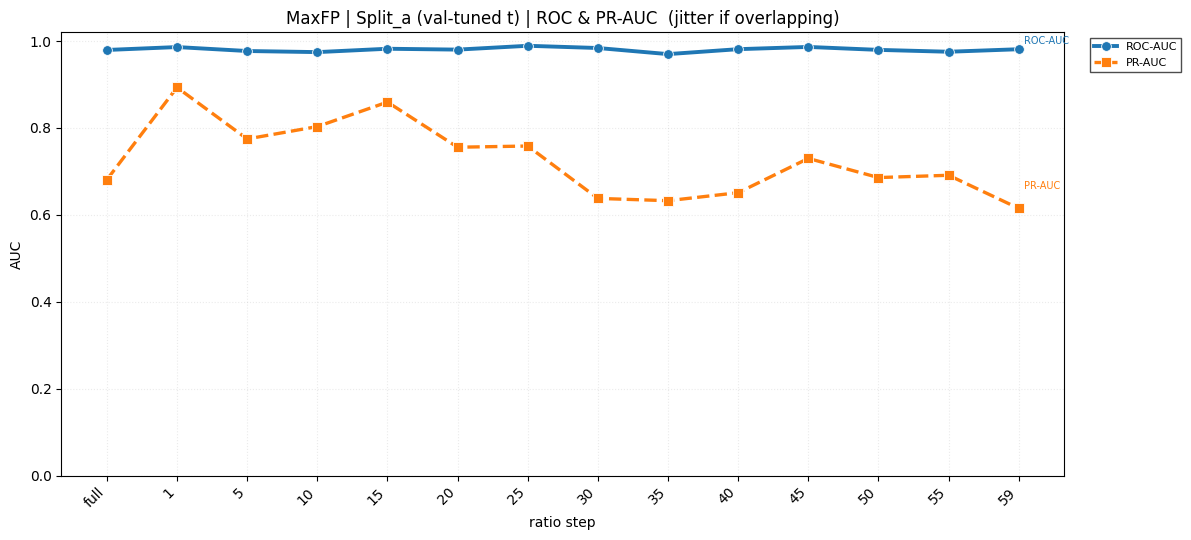


=== Report: MaxFP | Split_b (val-tuned t) ===
Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_valt_fscores.png


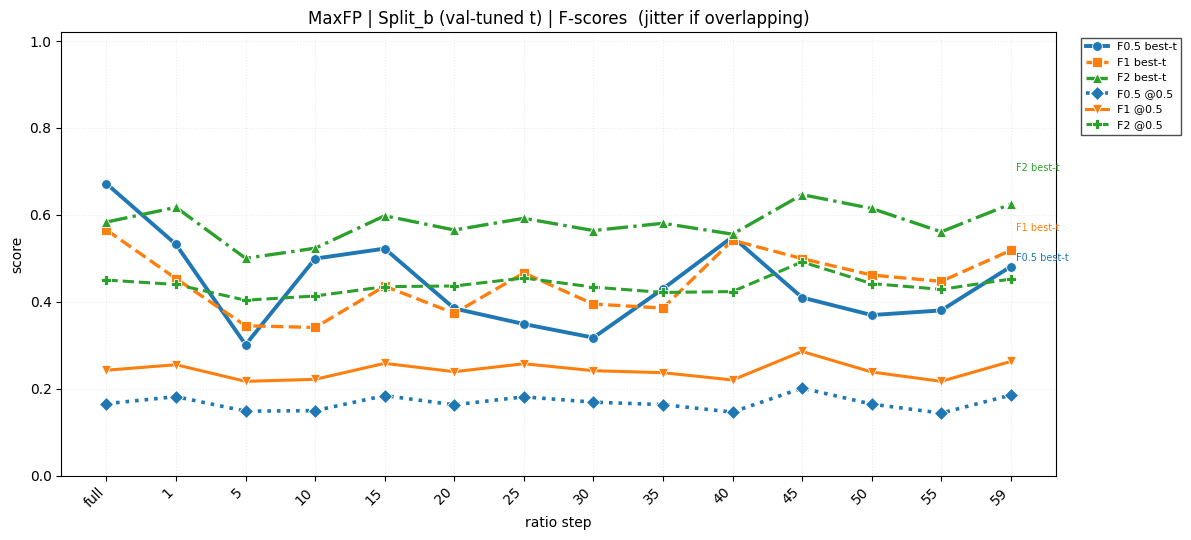

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_valt_fp_fn.png


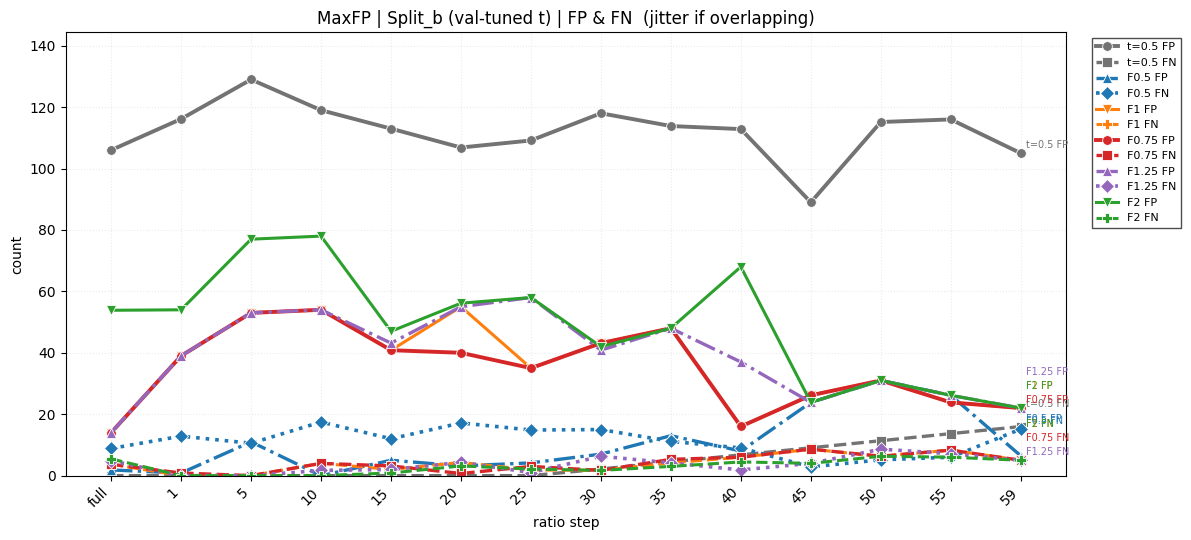

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_valt_fp.png


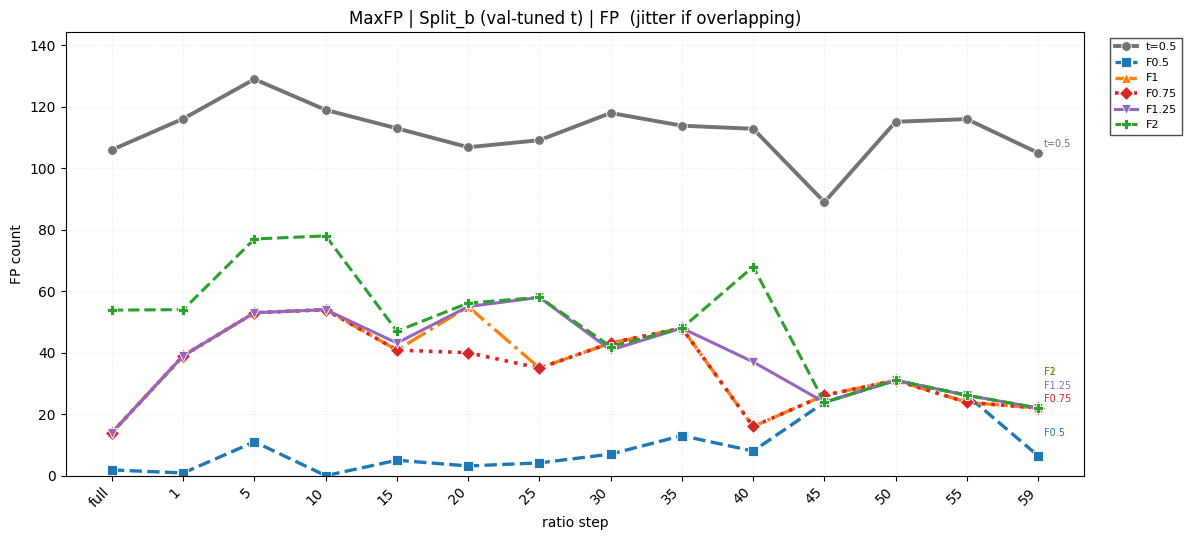

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_valt_fn.png


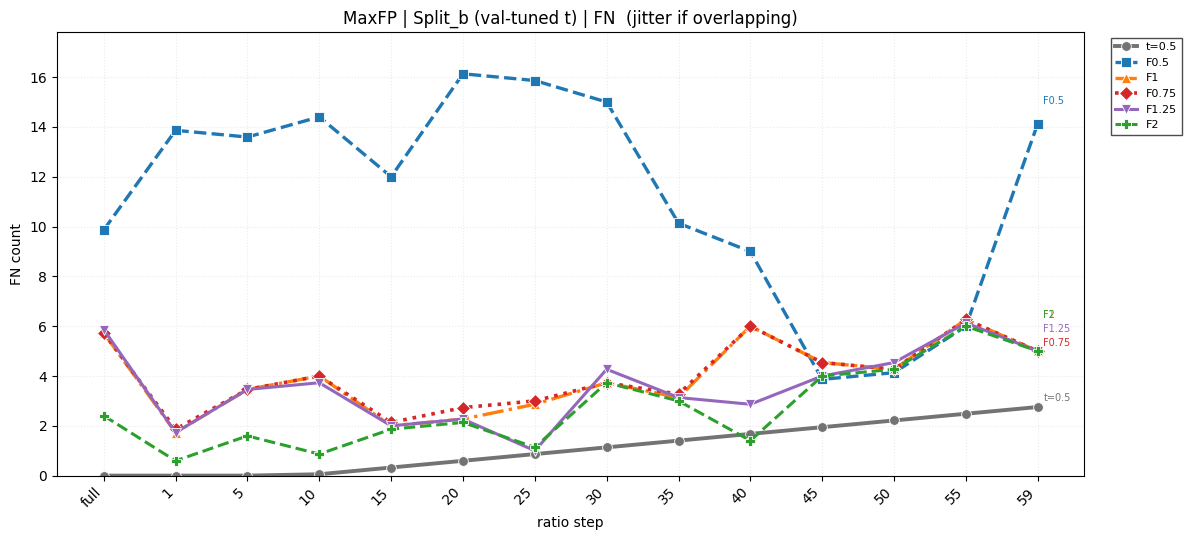

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_valt_auc.png


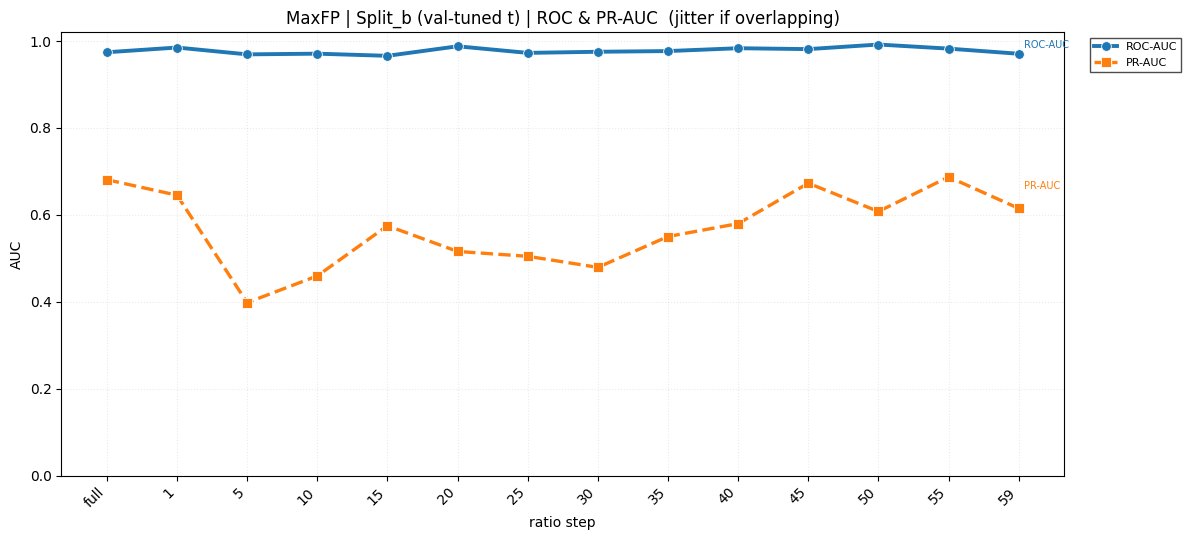


=== Report: MaxFP | Split_b (oracle t) ===
Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_oracle_fscores.png


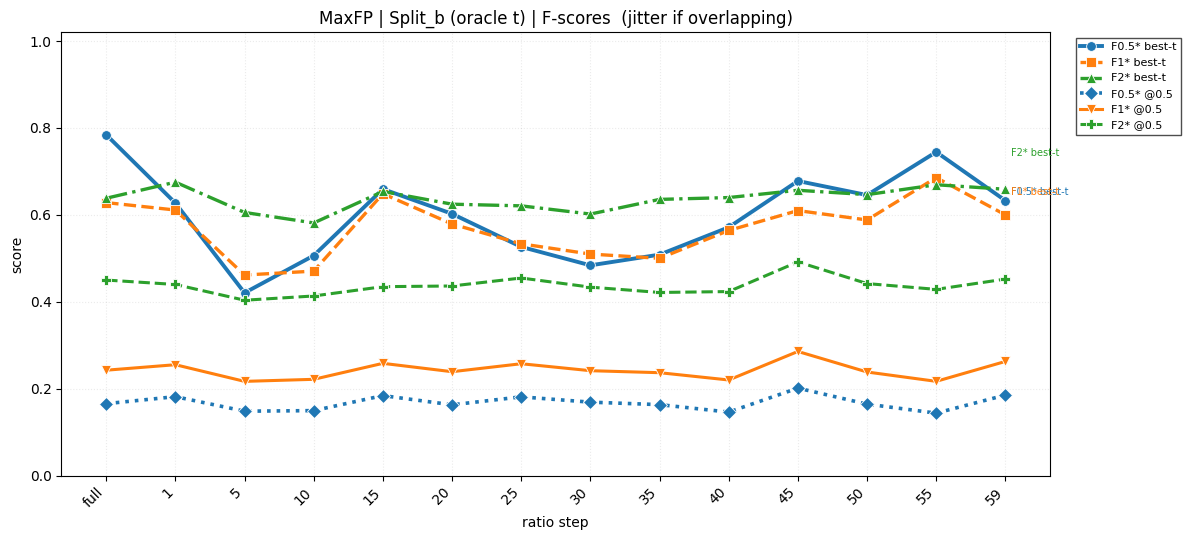

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_oracle_fp_fn.png


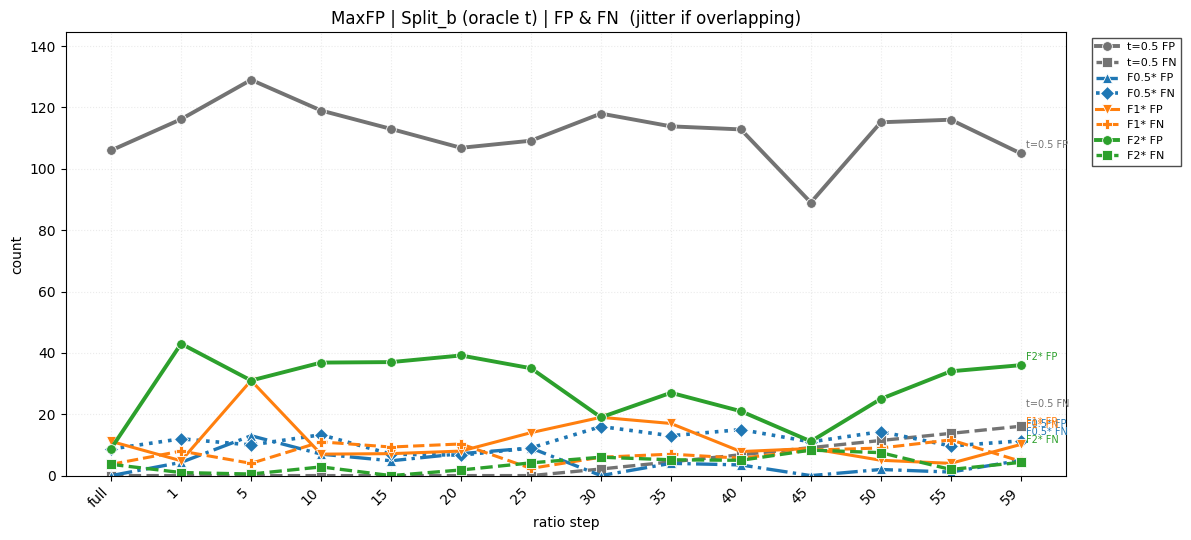

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_oracle_fp.png


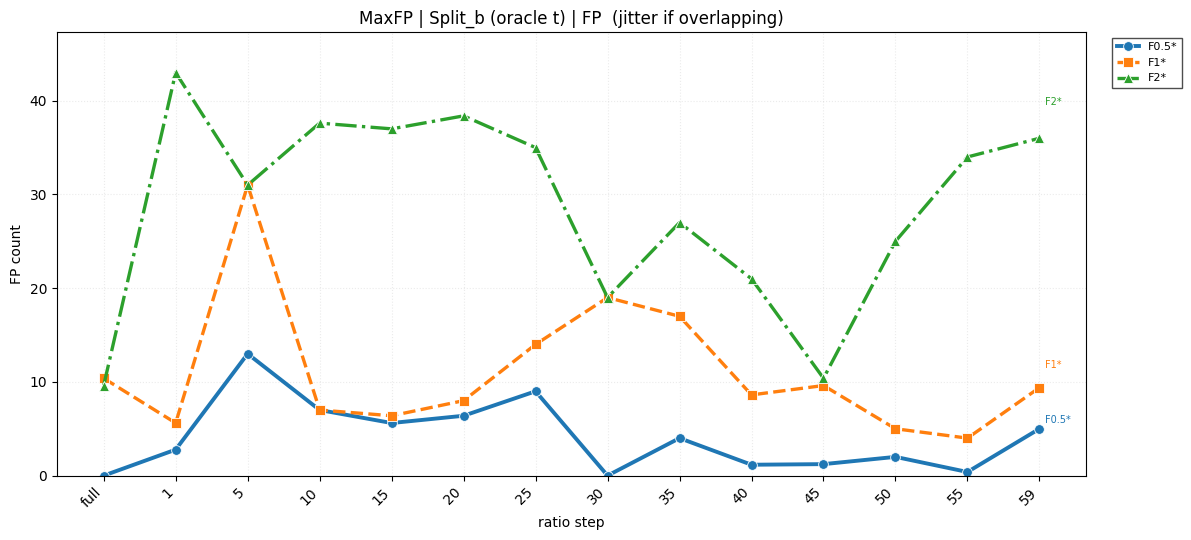

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_oracle_fn.png


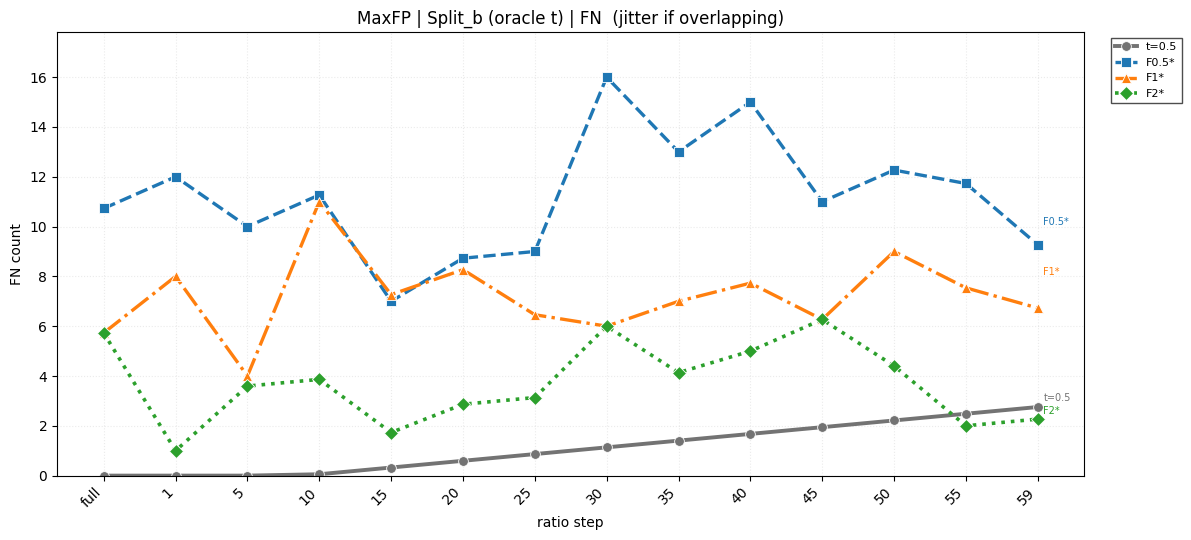

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_oracle_auc.png


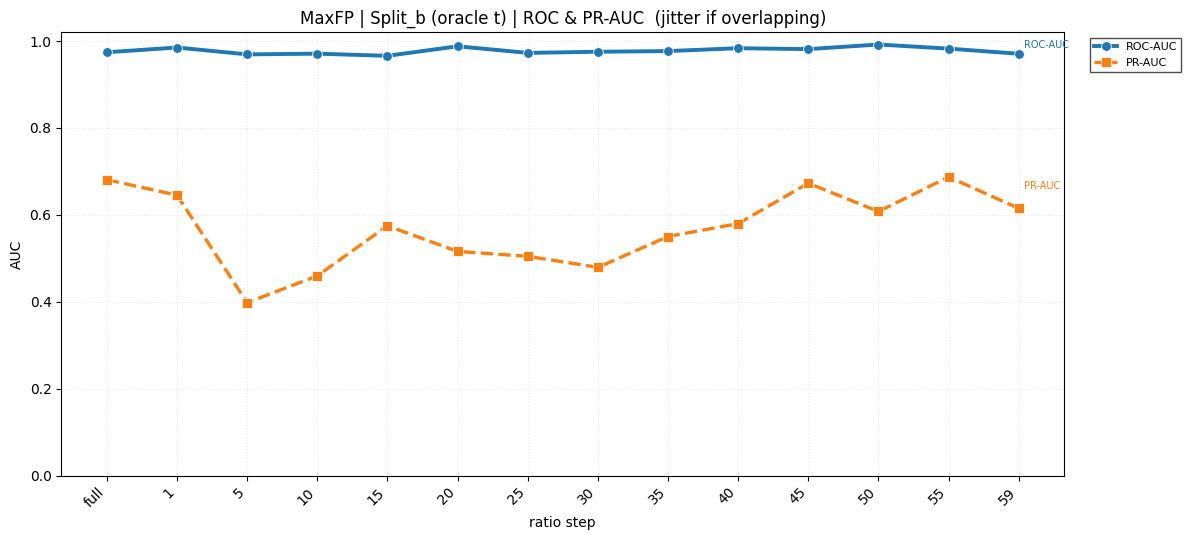

--- MaxFP split_b val-tuned tradeoff ---
Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_valt_tradeoff_fp_fn.png


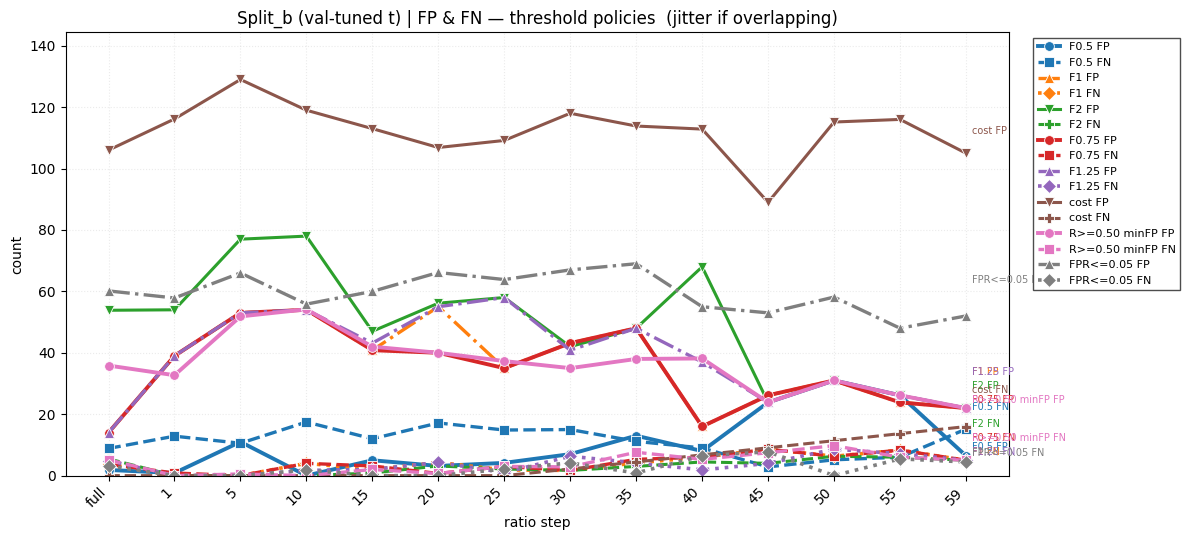

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_valt_tradeoff_fpr.png


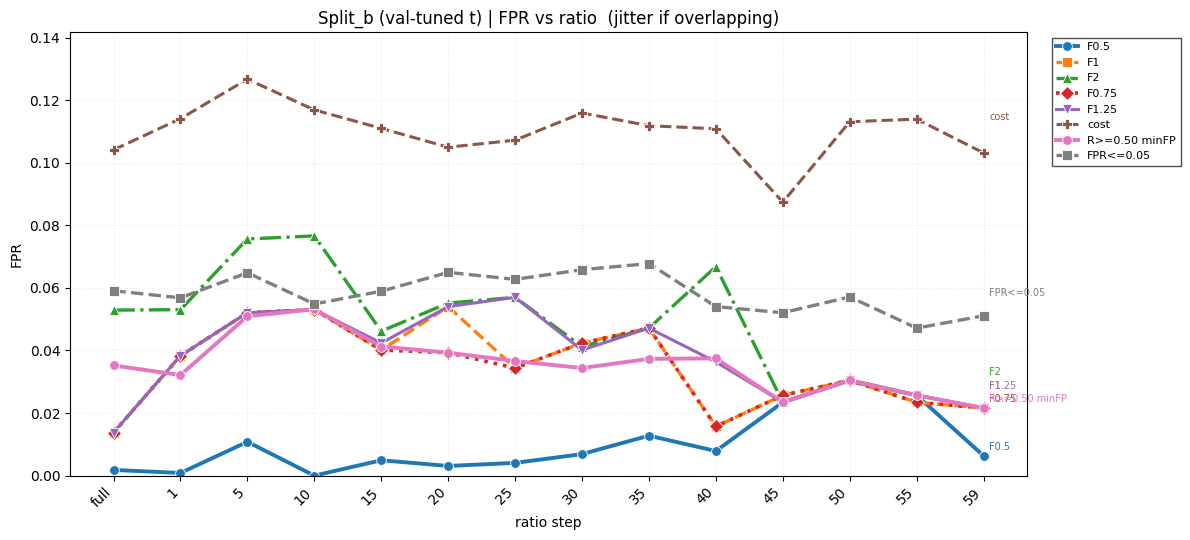

Saved: /kaggle/working/vlst_fp_followup_output/maxfp_cal_threshold/maxfp_cal_report_split_b_valt_tradeoff_frontier.png


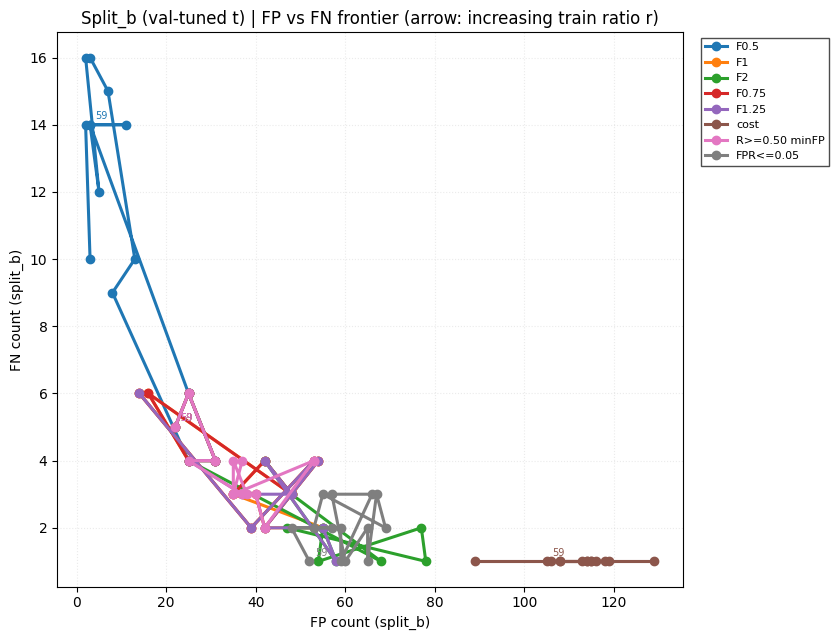

In [9]:
run_eval_plots_for_sweep(
    sweep_df_maxfp,
    OUTPUT_DIR_MAXFP,
    plot_prefix="maxfp_cal_",
    title_prefix="MaxFP | ",
)


## 5. Saved artifact paths


In [10]:
print(
    "Artifacts written to:",
    OUTPUT_DIR,
    "\n",
    " - fp_followup_ratio_sweep.csv",
    " - maxfp_cal_threshold/fp_followup_ratio_sweep_maxfp_cal_threshold.csv",
)


Artifacts written to: /kaggle/working/vlst_fp_followup_output 
  - fp_followup_ratio_sweep.csv  - maxfp_cal_threshold/fp_followup_ratio_sweep_maxfp_cal_threshold.csv
